In [198]:
import os

# Adjust the path to match your Box sync folder location
box_path = os.path.expanduser(r"C:\Users\HIALAB\Box\Human_AGV_project\ISU_Modeling\Code")

In [200]:
# base libraries
import pandas as pd
import numpy as np 
import pingouin as pg

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import matplotlib.colors as mcolors
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
from statsmodels.stats.power import TTestIndPower
from statsmodels.formula.api import ols

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.cluster import KMeans
from xgboost import XGBRegressor
from sklearn.decomposition import PCA
from IPython.display import clear_output

from sklearn import preprocessing
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import mean_absolute_percentage_error as mape
from sklearn.metrics import classification_report
from sklearn.metrics import silhouette_score
from sklearn.metrics import  r2_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import cross_val_score
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.metrics import confusion_matrix

from sklearn.preprocessing import OneHotEncoder

import math
from math import sqrt

import scipy.stats
from scipy import stats
from scipy.stats import ttest_ind

from datetime import datetime, timedelta

import researchpy as rp

import shap

import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn.utils.validation")

In [296]:
# Adjust the path to match your Box sync folder location
box_path = os.path.expanduser(r"C:\Users\HIALAB\Box\Human_AGV_project\ISU_Modeling\Code")

In [202]:
# Specify the directory and filename
save_dir = "./Images/"

In [204]:
model_data = pd.read_csv(os.path.join(box_path, 'Per_Interaction_Data_Merged.csv'))
study_data = pd.read_csv(os.path.join(box_path, 'study_data_processed.csv'))

In [205]:
model_data.head()

,PID,DRate,date,hr,min,s,AGVname,StartTime,EndTime,GazeDuration,...,AGV_Path_Complexity,Trust_before,Cross_First_Flag,User_Relative_Speed,AGV_Relative_Speed,Frechet_Distance_3,Frechet_Distance_5,Frechet_Distance_7,Frechet_Distance_10,Cross_First
0,1,High,2024-5-3,14,28,53,1,1900-01-01 15:02:48,1900-01-01 15:03:38,219,...,Straight,103,True,74.6,100,730,1.19e+03,1.53e+03,1.77e+03,N\A
1,1,High,2024-5-3,14,28,53,2,1900-01-01 15:03:47,1900-01-01 15:04:29,0,...,Complex,211,True,47.9,232,14.6,97,108,247,N\A
2,1,High,2024-5-3,14,28,53,3,1900-01-01 15:04:37,1900-01-01 15:05:34,268,...,Complex,211,True,63.1,120,282,483,821,1.07e+03,User
3,1,High,2024-5-3,14,28,53,4,1900-01-01 15:05:46,1900-01-01 15:06:37,779,...,Complex,211,True,43.6,263,421,544,578,611,User
4,1,High,2024-5-3,14,28,53,5,1900-01-01 15:06:41,1900-01-01 15:07:44,868,...,Complex,148,True,93.7,91.6,487,853,1.23e+03,1.72e+03,N\A


In [206]:
study_data.head()

,User_X,User_Y,User_Z,User_Pitch,User_Yaw,User_Roll,U_X,U_Y,U_Z,GazeOrigin_X,...,AGV_Yaw,AGV_Roll,AGV_spd,Timestamp,AGVname,PID,DRate,User_Relative_Speed,AGV_Relative_Speed,AGV_User_distance
0,5.05e+03,8.61e+03,-210,-21.4,-92.2,-0.16,60.5,-107,156,4.99e+03,...,90,0.00239,0.000238,2024-10-25 15:02:48.900,1,1,High,0,0,6.81e+03
1,5.05e+03,8.61e+03,-210,-21.2,-92.4,0.291,60.5,-108,156,4.99e+03,...,90,-0.00046,0.155,2024-10-25 15:02:49.000,1,1,High,0,84.2,6.81e+03
2,5.05e+03,8.61e+03,-210,-21.2,-92.8,0.339,60.3,-109,156,4.99e+03,...,90,-0.00178,0.526,2024-10-25 15:02:49.100,1,1,High,0,74.7,6.81e+03
3,5.05e+03,8.61e+03,-210,-21,-93.1,0.251,59.8,-110,156,4.99e+03,...,90,-0.00195,0.893,2024-10-25 15:02:49.200,1,1,High,0,35.8,6.81e+03
4,5.05e+03,8.61e+03,-210,-20.7,-91.2,0.512,59.3,-110,156,4.99e+03,...,90,-0.00146,1.26,2024-10-25 15:02:49.300,1,1,High,0,66.6,6.8e+03


In [207]:
model_data.columns

Index(['PID', 'DRate', 'date', 'hr', 'min', 's', 'AGVname', 'StartTime',
       'EndTime', 'GazeDuration', 'mean_dist', 'min_dist', 'max_dist',
       'std_dist', 'mean_agv_spd', 'min_agv_spd', 'max_agv_spd', 'std_spd',
       'task', 'Trust', 'Safe', 'Comfort', 'Expect', 'Age', 'Gender',
       'Ethnicity', 'GamingFrequency', 'VRExperience', 'VRHeadsetExperience',
       'AGVInteraction', 'PerfectAutomation', 'TrustPropensity',
       'AutomationExperience', 'Trust1', 'Trust2', 'MWL', 'Assessment',
       'Gaze_on_AGV', 'User_Trajectory', 'AGV_Approaching',
       'AGV_User_Combination', 'AGV_Path_Complexity', 'Trust_before',
       'Cross_First_Flag', 'User_Relative_Speed', 'AGV_Relative_Speed',
       'Frechet_Distance_3', 'Frechet_Distance_5', 'Frechet_Distance_7',
       'Frechet_Distance_10', 'Cross_First'],
      dtype='object')

In [208]:
study_data.columns

Index(['User_X', 'User_Y', 'User_Z', 'User_Pitch', 'User_Yaw', 'User_Roll',
       'U_X', 'U_Y', 'U_Z', 'GazeOrigin_X', 'GazeOrigin_Y', 'GazeOrigin_Z',
       'GazeDirection_X', 'GazeDirection_Y', 'GazeDirection_Z', 'Confidence',
       'Gaze_on_AGV', 'AGV_X', 'AGV_Y', 'AGV_Z', 'AGV_Pitch', 'AGV_Yaw',
       'AGV_Roll', 'AGV_spd', 'Timestamp', 'AGVname', 'PID', 'DRate',
       'User_Relative_Speed', 'AGV_Relative_Speed', 'AGV_User_distance'],
      dtype='object')

In [209]:
print(model_data.dtypes)

PID                       int64
DRate                    object
date                     object
hr                        int64
min                       int64
s                         int64
AGVname                   int64
StartTime                object
EndTime                  object
GazeDuration              int64
mean_dist               float64
min_dist                float64
max_dist                float64
std_dist                float64
mean_agv_spd            float64
min_agv_spd             float64
max_agv_spd             float64
std_spd                 float64
task                       bool
Trust                     int64
Safe                      int64
Comfort                   int64
Expect                    int64
Age                     float64
Gender                  float64
Ethnicity               float64
GamingFrequency          object
VRExperience             object
VRHeadsetExperience      object
AGVInteraction           object
PerfectAutomation       float64
TrustPro

In [210]:
print(study_data.dtypes)

User_X                 float64
User_Y                 float64
User_Z                 float64
User_Pitch             float64
User_Yaw               float64
User_Roll              float64
U_X                    float64
U_Y                    float64
U_Z                    float64
GazeOrigin_X           float64
GazeOrigin_Y           float64
GazeOrigin_Z           float64
GazeDirection_X        float64
GazeDirection_Y        float64
GazeDirection_Z        float64
Confidence             float64
Gaze_on_AGV            float64
AGV_X                  float64
AGV_Y                  float64
AGV_Z                  float64
AGV_Pitch              float64
AGV_Yaw                float64
AGV_Roll               float64
AGV_spd                float64
Timestamp               object
AGVname                  int64
PID                      int64
DRate                   object
User_Relative_Speed    float64
AGV_Relative_Speed     float64
AGV_User_distance      float64
dtype: object


### Adding Interaction No, which will come handy for "fill_between" plots

In [212]:
model_data["Interaction No"] = model_data.groupby(['PID', 'DRate']).cumcount() + 1

In [213]:
model_data['PID'] = model_data['PID'].apply(lambda x: str(x).zfill(3))

In [214]:
model_data.iloc[0:15]

,PID,DRate,date,hr,min,s,AGVname,StartTime,EndTime,GazeDuration,...,Trust_before,Cross_First_Flag,User_Relative_Speed,AGV_Relative_Speed,Frechet_Distance_3,Frechet_Distance_5,Frechet_Distance_7,Frechet_Distance_10,Cross_First,Interaction No
0,001,High,2024-5-3,14,28,53,1,1900-01-01 15:02:48,1900-01-01 15:03:38,219,...,103,True,74.6,100,730,1.19e+03,1.53e+03,1.77e+03,N\A,1
1,001,High,2024-5-3,14,28,53,2,1900-01-01 15:03:47,1900-01-01 15:04:29,0,...,211,True,47.9,232,14.6,97,108,247,N\A,2
2,001,High,2024-5-3,14,28,53,3,1900-01-01 15:04:37,1900-01-01 15:05:34,268,...,211,True,63.1,120,282,483,821,1.07e+03,User,3
3,001,High,2024-5-3,14,28,53,4,1900-01-01 15:05:46,1900-01-01 15:06:37,779,...,211,True,43.6,263,421,544,578,611,User,4
4,001,High,2024-5-3,14,28,53,5,1900-01-01 15:06:41,1900-01-01 15:07:44,868,...,148,True,93.7,91.6,487,853,1.23e+03,1.72e+03,N\A,5
5,001,High,2024-5-3,14,28,53,6,1900-01-01 15:07:56,1900-01-01 15:08:58,1195,...,106,True,60,106,560,839,1.11e+03,1.47e+03,N\A,6
6,001,High,2024-5-3,14,28,53,7,1900-01-01 15:09:07,1900-01-01 15:09:50,537,...,148,True,62.1,229,380,541,665,942,User,7
7,001,High,2024-5-3,14,28,53,8,1900-01-01 15:10:07,1900-01-01 15:11:08,650,...,169,True,59.4,161,332,693,1.04e+03,1.48e+03,User,8
8,001,High,2024-5-3,14,28,53,9,1900-01-01 15:11:12,1900-01-01 15:12:13,856,...,84.5,True,59,161,116,379,541,1.03e+03,AGV,9
9,001,High,2024-5-3,14,28,53,10,1900-01-01 15:12:20,1900-01-01 15:13:08,673,...,190,True,60,206,284,567,897,1.31e+03,AGV,10


## Data Visulaization

### Distribution Fitting

Gamma distribution parameters, [a_fit, loc_fit, scale_fit]: [278.3361333280592, -22.862821398114477, 0.11243350651746747]


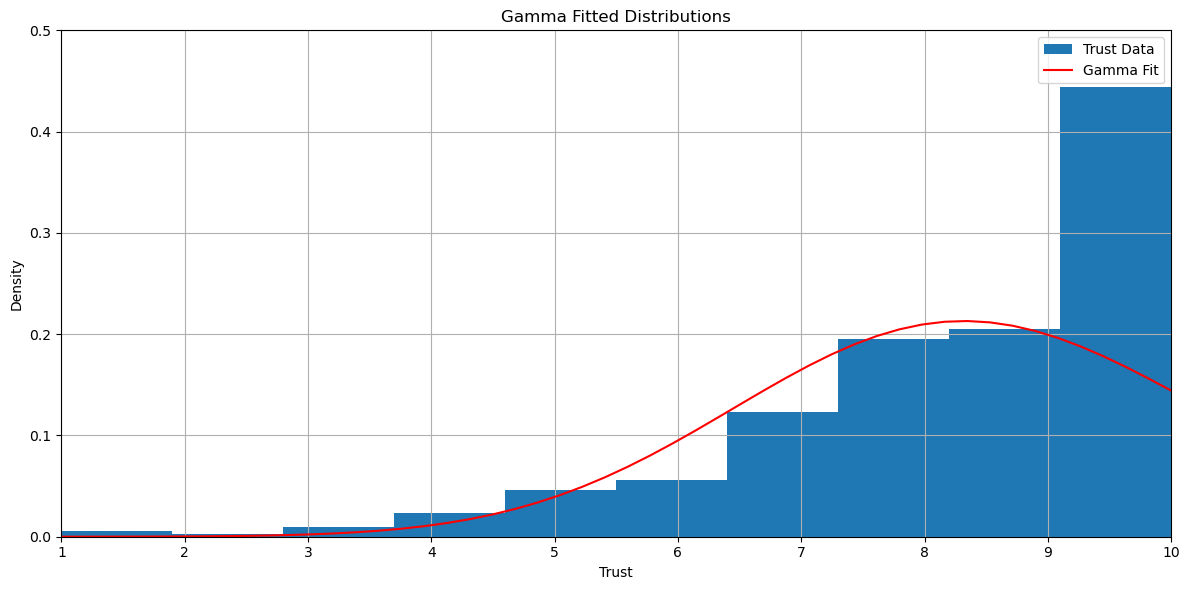

In [217]:
[a_fit, loc_fit, scale_fit] = scipy.stats.gamma.fit(model_data['Trust'])

print("Gamma distribution parameters, [a_fit, loc_fit, scale_fit]:",[a_fit, loc_fit, scale_fit])
#gamma_params = stats.gamma.fit(model_data['Trust'])

#trust_min = model_data['Trust'].min()
#trust_max = model_data['Trust'].max()
#normlized_trust_data = (model_data['Trust']-trust_min)/(trust_max - trust_min)
#beta_params = scipy.stats.beta.fit(normlized_trust_data)

# Printing the parameters of both distributions
# print("Gamma distribution parameters:", gamma_params)
# print("Beta distribution parameters:", beta_params)

# Generate some data points for each distribution
x_gamma = np.linspace(min(model_data['Trust']), max(model_data['Trust']))
#x_beta = np.linspace(0,1,100)

#Plotting Distributions
plt.figure(figsize=(12,6))

plt.hist(model_data['Trust'], density=True, label = 'Trust Data')

#Gamma distribution plot
plt.plot(x_gamma, scipy.stats.gamma.pdf(x_gamma, a_fit, loc = loc_fit, scale=scale_fit), 'r-', label = 'Gamma Fit')

#Gamma distribution plot
#plt.plot(x_beta*(trust_max - trust_min) + trust_min, stats.beta.pdf(x_beta, *beta_params), 'b-', label = 'Beta fit')
plt.xlim(1,10)
plt.ylim(0,0.5)
plt.grid(True)
plt.xlabel('Trust')
plt.ylabel('Density')
plt.legend(loc='best')
plt.title('Gamma Fitted Distributions')
plt.tight_layout()

# generate a timestamp for the uniqueness 
timestamp = datetime.now().strftime("%Y%m%d%H%M%S")

# Define the filename with timestamp
# filename = f'Gamma_Fitted_Distributions_as_a_trust_dynamic_model_{timestamp}.png'
# plt.savefig(save_dir + filename, bbox_inches = 'tight', pad_inches=0.1)
plt.show()

### With Respect to Decelaration Rate

In [219]:
# Group Data by Interaction No
# 1.1. 
grouped_for_fill_between_visualization_for_trust = model_data.groupby(['Interaction No', 'DRate']).agg(
    Trust_mean = ('Trust', 'mean'),
    Trust_std = ('Trust', 'std'),
    Trust_count = ('Trust', 'count')
    ).reset_index()

# Calculate the confidence intervals for trust
grouped_for_fill_between_visualization_for_trust['Trust_ci'] = grouped_for_fill_between_visualization_for_trust['Trust_std'] / np.sqrt(grouped_for_fill_between_visualization_for_trust['Trust_count']) * stats.t.ppf((1 + 0.95)/2.0, grouped_for_fill_between_visualization_for_trust['Trust_count']-1)
grouped_for_fill_between_visualization_for_trust['Trust_ci_lower'] = grouped_for_fill_between_visualization_for_trust['Trust_mean'] - grouped_for_fill_between_visualization_for_trust['Trust_ci']
grouped_for_fill_between_visualization_for_trust['Trust_ci_upper'] = grouped_for_fill_between_visualization_for_trust['Trust_mean'] + grouped_for_fill_between_visualization_for_trust['Trust_ci']

# Calculate the confidence intervals for safety
# 1.2. 
grouped_for_fill_between_visualization_for_safe = model_data.groupby(['Interaction No', 'DRate']).agg(
    Safe_mean = ('Safe', 'mean'),
    Safe_std = ('Safe', 'std'),
    Safe_count = ('Safe', 'count')
    ).reset_index()

grouped_for_fill_between_visualization_for_safe['Safe_ci'] = grouped_for_fill_between_visualization_for_safe['Safe_std'] / np.sqrt(grouped_for_fill_between_visualization_for_safe['Safe_count']) * stats.t.ppf((1 + 0.95)/2.0, grouped_for_fill_between_visualization_for_safe['Safe_count']-1)
grouped_for_fill_between_visualization_for_safe['Safe_ci_lower'] = grouped_for_fill_between_visualization_for_safe['Safe_mean'] - grouped_for_fill_between_visualization_for_safe['Safe_ci']
grouped_for_fill_between_visualization_for_safe['Safe_ci_upper'] = grouped_for_fill_between_visualization_for_safe['Safe_mean'] + grouped_for_fill_between_visualization_for_safe['Safe_ci']

# Calculate the confidence intervals for comfort

grouped_for_fill_between_visualization_for_comfort = model_data.groupby(['Interaction No', 'DRate']).agg(
    Comfort_mean = ('Comfort', 'mean'),
    Comfort_std = ('Comfort', 'std'),
    Comfort_count = ('Comfort', 'count')
    ).reset_index()


grouped_for_fill_between_visualization_for_comfort['Comfort_ci'] = grouped_for_fill_between_visualization_for_comfort['Comfort_std'] / np.sqrt(grouped_for_fill_between_visualization_for_comfort['Comfort_count']) * stats.t.ppf((1 + 0.95)/2.0, grouped_for_fill_between_visualization_for_comfort['Comfort_count']-1)
grouped_for_fill_between_visualization_for_comfort['Comfort_ci_lower'] = grouped_for_fill_between_visualization_for_comfort['Comfort_mean'] - grouped_for_fill_between_visualization_for_comfort['Comfort_ci']
grouped_for_fill_between_visualization_for_comfort['Comfort_ci_upper'] = grouped_for_fill_between_visualization_for_comfort['Comfort_mean'] + grouped_for_fill_between_visualization_for_comfort['Comfort_ci']

grouped_for_fill_between_visualization_for_expect = model_data.groupby(['Interaction No', 'DRate']).agg(
    Expect_mean = ('Expect', 'mean'),
    Expect_std = ('Expect', 'std'),
    Expect_count = ('Expect', 'count')
    ).reset_index()

# Calculate the confidence intervals for expectancy
grouped_for_fill_between_visualization_for_expect['Expect_ci'] = grouped_for_fill_between_visualization_for_expect['Expect_std'] / np.sqrt(grouped_for_fill_between_visualization_for_expect['Expect_count']) * stats.t.ppf((1 + 0.95)/2.0, grouped_for_fill_between_visualization_for_expect['Expect_count']-1)
grouped_for_fill_between_visualization_for_expect['Expect_ci_lower'] = grouped_for_fill_between_visualization_for_expect['Expect_mean'] - grouped_for_fill_between_visualization_for_expect['Expect_ci']
grouped_for_fill_between_visualization_for_expect['Expect_ci_upper'] = grouped_for_fill_between_visualization_for_expect['Expect_mean'] + grouped_for_fill_between_visualization_for_expect['Expect_ci']

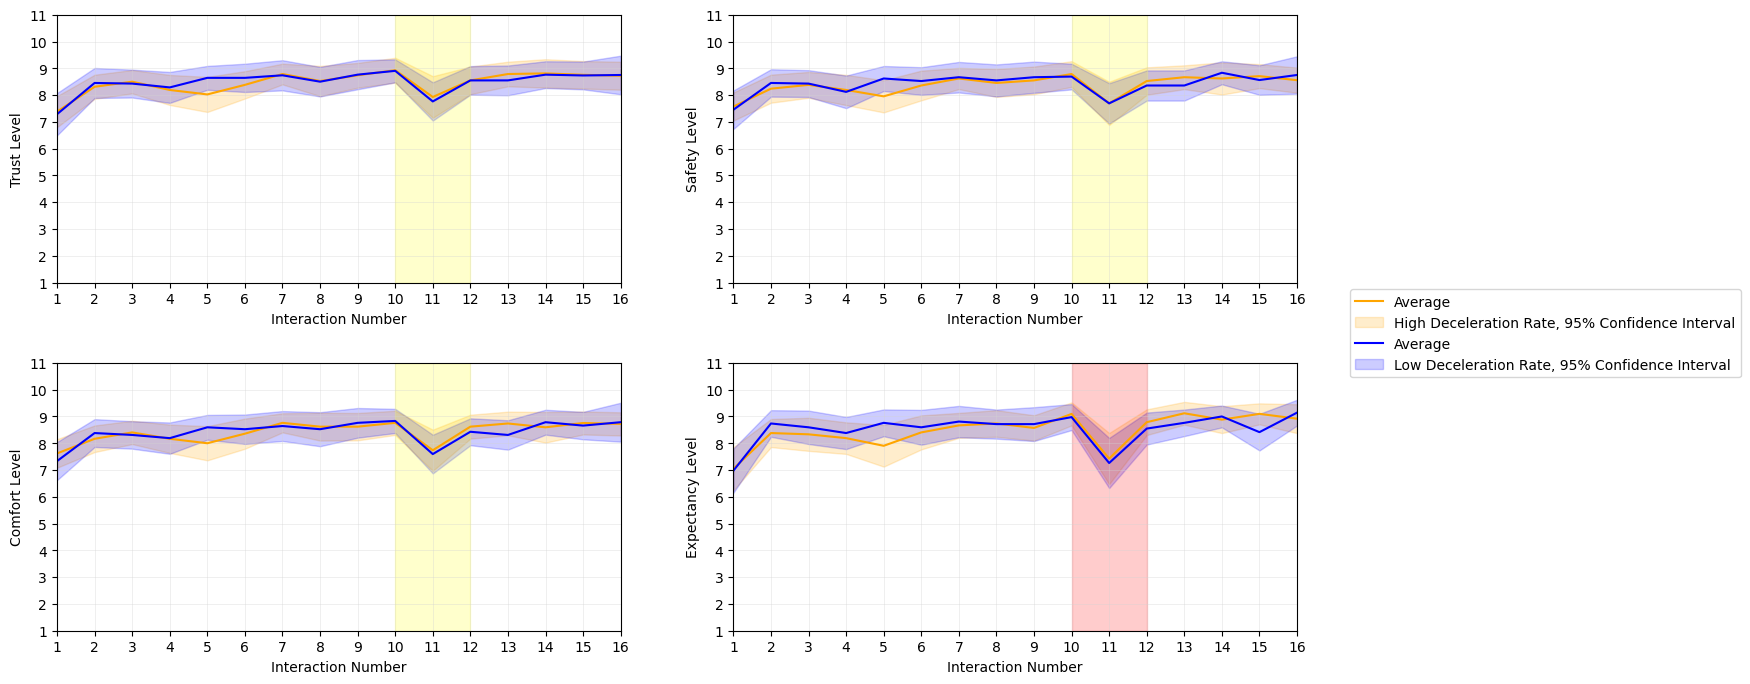

In [220]:
model_data_high_trust = grouped_for_fill_between_visualization_for_trust[grouped_for_fill_between_visualization_for_trust['DRate'] == 'High']
model_data_low_trust = grouped_for_fill_between_visualization_for_trust[grouped_for_fill_between_visualization_for_trust['DRate'] == 'Low']

model_data_high_Safe = grouped_for_fill_between_visualization_for_safe[grouped_for_fill_between_visualization_for_safe['DRate'] == 'High']
model_data_low_Safe = grouped_for_fill_between_visualization_for_safe[grouped_for_fill_between_visualization_for_safe['DRate'] == 'Low']

model_data_high_Comfort = grouped_for_fill_between_visualization_for_comfort[grouped_for_fill_between_visualization_for_comfort['DRate'] == 'High']
model_data_low_Comfort = grouped_for_fill_between_visualization_for_comfort[grouped_for_fill_between_visualization_for_comfort['DRate'] == 'Low']

model_data_high_Expect = grouped_for_fill_between_visualization_for_expect[grouped_for_fill_between_visualization_for_expect['DRate'] == 'High']
model_data_low_Expect = grouped_for_fill_between_visualization_for_expect[grouped_for_fill_between_visualization_for_expect['DRate'] == 'Low']

fig, axs = plt.subplots(2, 2, figsize=(16, 8), sharex = False)

# Plot the mean line and confidence intervals for linearly interpolated trust
axs[0,0].plot(model_data_high_trust['Interaction No'], model_data_high_trust['Trust_mean'], label = 'Average', color = 'orange')
axs[0,0].fill_between(model_data_high_trust['Interaction No'], model_data_high_trust['Trust_ci_lower'], model_data_high_trust['Trust_ci_upper'], color='orange', alpha = 0.20, label = 'High Deceleration Rate, 95% Confidence Interval')
axs[0,0].plot(model_data_high_trust['Interaction No'], model_data_low_trust['Trust_mean'], label = 'Average', color = 'blue')
axs[0,0].fill_between(model_data_low_trust['Interaction No'], model_data_low_trust['Trust_ci_lower'], model_data_low_trust['Trust_ci_upper'], color='blue', alpha = 0.20, label = 'Low Deceleration Rate, 95% Confidence Interval')
axs[0,0].set_ylabel('Trust Level')
axs[0,0].set_xlabel('Interaction Number')
#axs[0,0].set_title('Linearly Interpolated Trust by Point_ID')
#axs[0,0].legend()
axs[0,0].grid(color='lightgray', linestyle='-', linewidth=0.5, alpha=0.5)
axs[0,0].set_ylim(1, 10)
axs[0,0].set_yticks(range(1, 12))
axs[0,0].set_xlim(1, 16)
axs[0,0].set_xticks(np.arange(1, 17, 1))
axs[0,0].axvspan(10, 12, color = 'yellow', alpha = 0.2)

axs[0,1].plot(model_data_high_Safe['Interaction No'], model_data_high_Safe['Safe_mean'], label = 'Average', color = 'orange')
axs[0,1].fill_between(model_data_high_Safe['Interaction No'], model_data_high_Safe['Safe_ci_lower'], model_data_high_Safe['Safe_ci_upper'], color='orange', alpha = 0.20, label = 'High Deceleration Rate, 95% Confidence Interval')
axs[0,1].plot(model_data_low_Safe['Interaction No'], model_data_low_Safe['Safe_mean'], label = 'Average', color = 'blue')
axs[0,1].fill_between(model_data_low_Safe['Interaction No'], model_data_low_Safe['Safe_ci_lower'], model_data_low_Safe['Safe_ci_upper'], color='blue', alpha = 0.20, label = 'Low Deceleration Rate, 95% Confidence Interval')
axs[0,1].set_ylabel('Safety Level')
axs[0,1].set_xlabel('Interaction Number')
#axs[0,1].set_title('Linearly Interpolated Trust by Point_ID')
#axs[0,1].legend()
axs[0,1].grid(color='lightgray', linestyle='-', linewidth=0.5, alpha=0.5)
axs[0,1].set_ylim(1, 10)
axs[0,1].set_yticks(range(1, 12))
axs[0,1].set_xlim(1, 16)
axs[0,1].set_xticks(range(1, 17))
axs[0,1].axvspan(10, 12, color = 'yellow', alpha = 0.2)

axs[1,0].plot(model_data_high_Comfort['Interaction No'], model_data_high_Comfort['Comfort_mean'], label = 'Average', color = 'orange')
axs[1,0].fill_between(model_data_high_Comfort['Interaction No'], model_data_high_Comfort['Comfort_ci_lower'], model_data_high_Comfort['Comfort_ci_upper'], color='orange', alpha = 0.20, label = 'High Deceleration Rate, 95% Confidence Interval')
axs[1,0].plot(model_data_low_Comfort['Interaction No'], model_data_low_Comfort['Comfort_mean'], label = 'Average', color = 'blue')
axs[1,0].fill_between(model_data_low_Comfort['Interaction No'], model_data_low_Comfort['Comfort_ci_lower'], model_data_low_Comfort['Comfort_ci_upper'], color='blue', alpha = 0.20, label = 'Low Deceleration Rate, 95% Confidence Interval')
axs[1,0].set_ylabel('Comfort Level')
axs[1,0].set_xlabel('Interaction Number')
#axs[1,0].set_title('Linearly Interpolated Trust by Point_ID')
#axs[1,0].legend()
axs[1,0].grid(color='lightgray', linestyle='-', linewidth=0.5, alpha=0.5)
axs[1,0].set_ylim(1, 10)
axs[1,0].set_yticks(range(1, 12))
axs[1,0].set_xlim(1, 16)
axs[1,0].set_xticks(range(1, 17))
axs[1,0].axvspan(10, 12, color = 'yellow', alpha = 0.2)

axs[1,1].plot(model_data_high_Expect['Interaction No'], model_data_high_Expect['Expect_mean'], label = 'Average', color = 'orange')
axs[1,1].fill_between(model_data_high_Expect['Interaction No'], model_data_high_Expect['Expect_ci_lower'], model_data_high_Expect['Expect_ci_upper'], color='orange', alpha = 0.20, label = 'High Deceleration Rate, 95% Confidence Interval')
axs[1,1].plot(model_data_low_Expect['Interaction No'], model_data_low_Expect['Expect_mean'], label = 'Average', color = 'blue')
axs[1,1].fill_between(model_data_low_Expect['Interaction No'], model_data_low_Expect['Expect_ci_lower'], model_data_low_Expect['Expect_ci_upper'], color='blue', alpha = 0.20, label = 'Low Deceleration Rate, 95% Confidence Interval')
axs[1,1].set_ylabel('Expectancy Level')
axs[1,1].set_xlabel('Interaction Number')
#axs[1,1].set_title('Linearly Interpolated Trust by Point_ID')
#axs[1,1].legend()
axs[1,1].grid(color='lightgray', linestyle='-', linewidth=0.5, alpha=0.5)
axs[1,1].set_ylim(1, 10)
axs[1,1].set_yticks(range(1, 12))
axs[1,1].set_xlim(1, 16)
axs[1,1].set_xticks(range(1, 17))
# Define Inset Axes
#axin = inset_axes(axs[1,1], width = '17.5%', height = '50%', loc = 'lower right')
#axin.plot(model_data_high_Expect['Interaction No'], model_data_high_Expect['Expect_mean'], label = 'Average', color = 'orange')
#axin.fill_between(model_data_high_Expect['Interaction No'], model_data_high_Expect['Expect_ci_lower'], model_data_high_Expect['Expect_ci_upper'], color='orange', alpha = 0.20, label = 'High Decelaration Rate, 95% Confidence Interval')
#axin.plot(model_data_low_Expect['Interaction No'], model_data_low_Expect['Expect_mean'], label = 'Average', color = 'blue')
#axin.fill_between(model_data_low_Expect['Interaction No'], model_data_low_Expect['Expect_ci_lower'], model_data_low_Expect['Expect_ci_upper'], color='blue', alpha = 0.20, label = 'Low Decelaration Rate, 95% Confidence Interval')
#axin.set_xlim(10, 12)
#axin.set_ylim(6,10)
#axs[1,1].indicate_inset_zoom(axin)
axs[1,1].axvspan(10, 12, color = 'red', alpha = 0.2)


plt.subplots_adjust(wspace=0.2, hspace=0.3)
#plt.xlabel('Decelaration Rate')
plt.legend(bbox_to_anchor=(1.8, 1.3))
# Adjust layout
#plt.tight_layout()

# generate a timestamp for the uniqueness 
timestamp = datetime.now().strftime("%Y%m%d%H%M%S")

# Define the filename with timestamp
# filename = f'Fill_Between_Plot_of_Dependent_Variables_History_46_Participants_with_axvspan_{timestamp}.png'
#plt.savefig(save_dir + filename, bbox_inches = 'tight', pad_inches=0.1)

plt.show()

In [221]:
high_first_low_last = ['002', '004', '006', '008', '010', '012', '014', '016', '020', 
                       '022', '027', '029', '031', '033', '035', '037', '039', '041', 
                       '043', '045']

low_first_high_last = ['001', '003', '007', '009', '011', '013', '015', '017', '019', 
                       '021', '024', '026', '028', '030', '032', '034', '036', '038', 
                       '040', '042', '044', '046']

model_data_hfll = model_data[model_data.PID.isin(high_first_low_last)]


model_data_lfhl = model_data[model_data.PID.isin(low_first_high_last)]

In [222]:
# Calculate the confidence intervals for trust
# 1.1. high-first-low-last
grouped_for_fill_between_visualization_hfll_for_trust = model_data_hfll.groupby(['Interaction No', 'DRate']).agg(
    Trust_mean = ('Trust', 'mean'),
    Trust_std = ('Trust', 'std'),
    Trust_count = ('Trust', 'count')
    ).reset_index()

grouped_for_fill_between_visualization_hfll_for_trust['Trust_ci'] = grouped_for_fill_between_visualization_hfll_for_trust['Trust_std'] / np.sqrt(grouped_for_fill_between_visualization_hfll_for_trust['Trust_count']) * stats.t.ppf((1 + 0.95)/2.0, grouped_for_fill_between_visualization_hfll_for_trust['Trust_count']-1)
grouped_for_fill_between_visualization_hfll_for_trust['Trust_ci_lower'] = grouped_for_fill_between_visualization_hfll_for_trust['Trust_mean'] - grouped_for_fill_between_visualization_hfll_for_trust['Trust_ci']
grouped_for_fill_between_visualization_hfll_for_trust['Trust_ci_upper'] = grouped_for_fill_between_visualization_hfll_for_trust['Trust_mean'] + grouped_for_fill_between_visualization_hfll_for_trust['Trust_ci']

# 1.2. low-first-high-last
grouped_for_fill_between_visualization_lfhl_for_trust = model_data_lfhl.groupby(['Interaction No', 'DRate']).agg(
    Trust_mean = ('Trust', 'mean'),
    Trust_std = ('Trust', 'std'),
    Trust_count = ('Trust', 'count')
    ).reset_index()

grouped_for_fill_between_visualization_lfhl_for_trust['Trust_ci'] = grouped_for_fill_between_visualization_lfhl_for_trust['Trust_std'] / np.sqrt(grouped_for_fill_between_visualization_lfhl_for_trust['Trust_count']) * stats.t.ppf((1 + 0.95)/2.0, grouped_for_fill_between_visualization_lfhl_for_trust['Trust_count']-1)
grouped_for_fill_between_visualization_lfhl_for_trust['Trust_ci_lower'] = grouped_for_fill_between_visualization_lfhl_for_trust['Trust_mean'] - grouped_for_fill_between_visualization_lfhl_for_trust['Trust_ci']
grouped_for_fill_between_visualization_lfhl_for_trust['Trust_ci_upper'] = grouped_for_fill_between_visualization_lfhl_for_trust['Trust_mean'] + grouped_for_fill_between_visualization_lfhl_for_trust['Trust_ci']

# Calculate the confidence intervals for safety
# 2.1. high-first-low-last
grouped_for_fill_between_visualization_hfll_for_Safe = model_data_hfll.groupby(['Interaction No', 'DRate']).agg(
    Safe_mean = ('Safe', 'mean'),
    Safe_std = ('Safe', 'std'),
    Safe_count = ('Safe', 'count')
    ).reset_index()

grouped_for_fill_between_visualization_hfll_for_Safe['Safe_ci'] = grouped_for_fill_between_visualization_hfll_for_Safe['Safe_std'] / np.sqrt(grouped_for_fill_between_visualization_hfll_for_Safe['Safe_count']) * stats.t.ppf((1 + 0.95)/2.0, grouped_for_fill_between_visualization_hfll_for_Safe['Safe_count']-1)
grouped_for_fill_between_visualization_hfll_for_Safe['Safe_ci_lower'] = grouped_for_fill_between_visualization_hfll_for_Safe['Safe_mean'] - grouped_for_fill_between_visualization_hfll_for_Safe['Safe_ci']
grouped_for_fill_between_visualization_hfll_for_Safe['Safe_ci_upper'] = grouped_for_fill_between_visualization_hfll_for_Safe['Safe_mean'] + grouped_for_fill_between_visualization_hfll_for_Safe['Safe_ci']

# 2.2. low-first-high-last
grouped_for_fill_between_visualization_lfhl_for_Safe = model_data_lfhl.groupby(['Interaction No', 'DRate']).agg(
    Safe_mean = ('Safe', 'mean'),
    Safe_std = ('Safe', 'std'),
    Safe_count = ('Safe', 'count')
    ).reset_index()

grouped_for_fill_between_visualization_lfhl_for_Safe['Safe_ci'] = grouped_for_fill_between_visualization_lfhl_for_Safe['Safe_std'] / np.sqrt(grouped_for_fill_between_visualization_lfhl_for_Safe['Safe_count']) * stats.t.ppf((1 + 0.95)/2.0, grouped_for_fill_between_visualization_lfhl_for_Safe['Safe_count']-1)
grouped_for_fill_between_visualization_lfhl_for_Safe['Safe_ci_lower'] = grouped_for_fill_between_visualization_lfhl_for_Safe['Safe_mean'] - grouped_for_fill_between_visualization_lfhl_for_Safe['Safe_ci']
grouped_for_fill_between_visualization_lfhl_for_Safe['Safe_ci_upper'] = grouped_for_fill_between_visualization_lfhl_for_Safe['Safe_mean'] + grouped_for_fill_between_visualization_lfhl_for_Safe['Safe_ci']

# Calculate the confidence intervals for comfort
# 3.1. high-first-low-last
grouped_for_fill_between_visualization_hfll_for_Comfort = model_data_hfll.groupby(['Interaction No', 'DRate']).agg(
    Comfort_mean = ('Comfort', 'mean'),
    Comfort_std = ('Comfort', 'std'),
    Comfort_count = ('Comfort', 'count')
    ).reset_index()

grouped_for_fill_between_visualization_hfll_for_Comfort['Comfort_ci'] = grouped_for_fill_between_visualization_hfll_for_Comfort['Comfort_std'] / np.sqrt(grouped_for_fill_between_visualization_hfll_for_Comfort['Comfort_count']) * stats.t.ppf((1 + 0.95)/2.0, grouped_for_fill_between_visualization_hfll_for_Comfort['Comfort_count']-1)
grouped_for_fill_between_visualization_hfll_for_Comfort['Comfort_ci_lower'] = grouped_for_fill_between_visualization_hfll_for_Comfort['Comfort_mean'] - grouped_for_fill_between_visualization_hfll_for_Comfort['Comfort_ci']
grouped_for_fill_between_visualization_hfll_for_Comfort['Comfort_ci_upper'] = grouped_for_fill_between_visualization_hfll_for_Comfort['Comfort_mean'] + grouped_for_fill_between_visualization_hfll_for_Comfort['Comfort_ci']

# 3.2. low-first-high-last
grouped_for_fill_between_visualization_lfhl_for_Comfort = model_data_lfhl.groupby(['Interaction No', 'DRate']).agg(
    Comfort_mean = ('Comfort', 'mean'),
    Comfort_std = ('Comfort', 'std'),
    Comfort_count = ('Comfort', 'count')
    ).reset_index()

grouped_for_fill_between_visualization_lfhl_for_Comfort['Comfort_ci'] = grouped_for_fill_between_visualization_lfhl_for_Comfort['Comfort_std'] / np.sqrt(grouped_for_fill_between_visualization_lfhl_for_Comfort['Comfort_count']) * stats.t.ppf((1 + 0.95)/2.0, grouped_for_fill_between_visualization_lfhl_for_Comfort['Comfort_count']-1)
grouped_for_fill_between_visualization_lfhl_for_Comfort['Comfort_ci_lower'] = grouped_for_fill_between_visualization_lfhl_for_Comfort['Comfort_mean'] - grouped_for_fill_between_visualization_lfhl_for_Comfort['Comfort_ci']
grouped_for_fill_between_visualization_lfhl_for_Comfort['Comfort_ci_upper'] = grouped_for_fill_between_visualization_lfhl_for_Comfort['Comfort_mean'] + grouped_for_fill_between_visualization_lfhl_for_Comfort['Comfort_ci']

# Calculate the confidence intervals for comfort
# 4.1. high-first-low-last
grouped_for_fill_between_visualization_hfll_for_Expect = model_data_hfll.groupby(['Interaction No', 'DRate']).agg(
    Expect_mean = ('Expect', 'mean'),
    Expect_std = ('Expect', 'std'),
    Expect_count = ('Expect', 'count')
    ).reset_index()

# Calculate the confidence intervals for expectancy
grouped_for_fill_between_visualization_hfll_for_Expect['Expect_ci'] = grouped_for_fill_between_visualization_hfll_for_Expect['Expect_std'] / np.sqrt(grouped_for_fill_between_visualization_hfll_for_Expect['Expect_count']) * stats.t.ppf((1 + 0.95)/2.0, grouped_for_fill_between_visualization_hfll_for_Expect['Expect_count']-1)
grouped_for_fill_between_visualization_hfll_for_Expect['Expect_ci_lower'] = grouped_for_fill_between_visualization_hfll_for_Expect['Expect_mean'] - grouped_for_fill_between_visualization_hfll_for_Expect['Expect_ci']
grouped_for_fill_between_visualization_hfll_for_Expect['Expect_ci_upper'] = grouped_for_fill_between_visualization_hfll_for_Expect['Expect_mean'] + grouped_for_fill_between_visualization_hfll_for_Expect['Expect_ci']

# 4.2. low-first-high-last
grouped_for_fill_between_visualization_lfhl_for_Expect = model_data_lfhl.groupby(['Interaction No', 'DRate']).agg(
    Expect_mean = ('Expect', 'mean'),
    Expect_std = ('Expect', 'std'),
    Expect_count = ('Expect', 'count')
    ).reset_index()

# Calculate the confidence intervals for expectancy
grouped_for_fill_between_visualization_lfhl_for_Expect['Expect_ci'] = grouped_for_fill_between_visualization_lfhl_for_Expect['Expect_std'] / np.sqrt(grouped_for_fill_between_visualization_lfhl_for_Expect['Expect_count']) * stats.t.ppf((1 + 0.95)/2.0, grouped_for_fill_between_visualization_lfhl_for_Expect['Expect_count']-1)
grouped_for_fill_between_visualization_lfhl_for_Expect['Expect_ci_lower'] = grouped_for_fill_between_visualization_lfhl_for_Expect['Expect_mean'] - grouped_for_fill_between_visualization_lfhl_for_Expect['Expect_ci']
grouped_for_fill_between_visualization_lfhl_for_Expect['Expect_ci_upper'] = grouped_for_fill_between_visualization_lfhl_for_Expect['Expect_mean'] + grouped_for_fill_between_visualization_lfhl_for_Expect['Expect_ci']

In [223]:
# 1.1. high-first-low-last
model_data_hfll_high_trust = grouped_for_fill_between_visualization_hfll_for_trust[grouped_for_fill_between_visualization_hfll_for_trust['DRate'] == 'High']
model_data_hfll_low_trust = grouped_for_fill_between_visualization_hfll_for_trust[grouped_for_fill_between_visualization_hfll_for_trust['DRate'] == 'Low']

# 1.2. low-first-high-last
model_data_lfhl_high_trust = grouped_for_fill_between_visualization_lfhl_for_trust[grouped_for_fill_between_visualization_lfhl_for_trust['DRate'] == 'High']
model_data_lfhl_low_trust = grouped_for_fill_between_visualization_lfhl_for_trust[grouped_for_fill_between_visualization_lfhl_for_trust['DRate'] == 'Low']


# 2.1. high-first-low-last
model_data_hfll_high_Safe = grouped_for_fill_between_visualization_hfll_for_Safe[grouped_for_fill_between_visualization_hfll_for_Safe['DRate'] == 'High']
model_data_hfll_low_Safe = grouped_for_fill_between_visualization_hfll_for_Safe[grouped_for_fill_between_visualization_hfll_for_Safe['DRate'] == 'Low']

# 2.2. low-first-high-last
model_data_lfhl_high_Safe = grouped_for_fill_between_visualization_lfhl_for_Safe[grouped_for_fill_between_visualization_lfhl_for_Safe['DRate'] == 'High']
model_data_lfhl_low_Safe = grouped_for_fill_between_visualization_lfhl_for_Safe[grouped_for_fill_between_visualization_lfhl_for_Safe['DRate'] == 'Low']


# 3.1. high-first-low-last
model_data_hfll_high_Comfort = grouped_for_fill_between_visualization_hfll_for_Comfort[grouped_for_fill_between_visualization_hfll_for_Comfort['DRate'] == 'High']
model_data_hfll_low_Comfort = grouped_for_fill_between_visualization_hfll_for_Comfort[grouped_for_fill_between_visualization_hfll_for_Comfort['DRate'] == 'Low']

# 3.2. low-first-high-last
model_data_lfhl_high_Comfort = grouped_for_fill_between_visualization_lfhl_for_Comfort[grouped_for_fill_between_visualization_lfhl_for_Comfort['DRate'] == 'High']
model_data_lfhl_low_Comfort = grouped_for_fill_between_visualization_lfhl_for_Comfort[grouped_for_fill_between_visualization_lfhl_for_Comfort['DRate'] == 'Low']


# 4.1. high-first-low-last
model_data_hfll_high_Expect = grouped_for_fill_between_visualization_hfll_for_Expect[grouped_for_fill_between_visualization_hfll_for_Expect['DRate'] == 'High']
model_data_hfll_low_Expect = grouped_for_fill_between_visualization_hfll_for_Expect[grouped_for_fill_between_visualization_hfll_for_Expect['DRate'] == 'Low']

# 4.2. low-first-high-last
model_data_lfhl_high_Expect = grouped_for_fill_between_visualization_lfhl_for_Expect[grouped_for_fill_between_visualization_lfhl_for_Expect['DRate'] == 'High']
model_data_lfhl_low_Expect = grouped_for_fill_between_visualization_lfhl_for_Expect[grouped_for_fill_between_visualization_lfhl_for_Expect['DRate'] == 'Low']

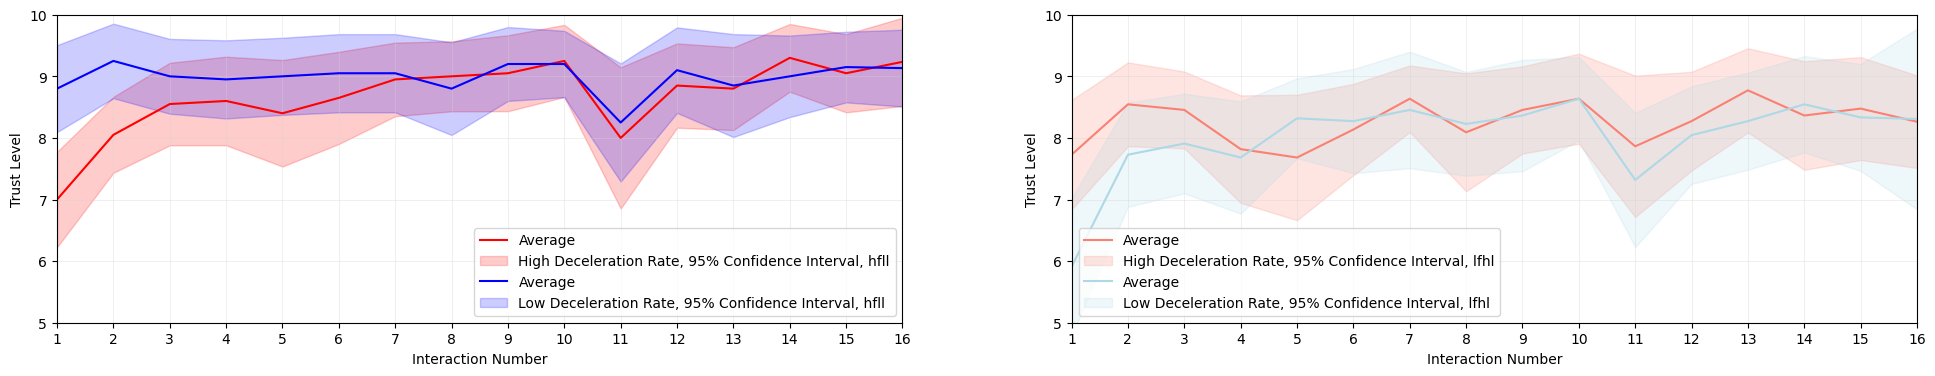

In [224]:
fig, axs = plt.subplots(1, 2, figsize=(24, 4), sharex = False)

# 1.1. high-first-low-last
axs[0].plot(model_data_hfll_high_trust['Interaction No'], model_data_hfll_high_trust['Trust_mean'], label = 'Average', color = 'red')
axs[0].fill_between(model_data_hfll_high_trust['Interaction No'], model_data_hfll_high_trust['Trust_ci_lower'], model_data_hfll_high_trust['Trust_ci_upper'], color='red', alpha = 0.20, label = 'High Deceleration Rate, 95% Confidence Interval, hfll')

axs[0].plot(model_data_hfll_low_trust['Interaction No'], model_data_hfll_low_trust['Trust_mean'], label = 'Average', color = 'blue')
axs[0].fill_between(model_data_hfll_low_trust['Interaction No'], model_data_hfll_low_trust['Trust_ci_lower'], model_data_hfll_low_trust['Trust_ci_upper'], color='blue', alpha = 0.20, label = 'Low Deceleration Rate, 95% Confidence Interval, hfll')

axs[0].set_ylabel('Trust Level')
axs[0].set_xlabel('Interaction Number')
#axs[0,0].set_title('Linearly Interpolated Trust by Point_ID')
axs[0].legend()
axs[0].grid(color='lightgray', linestyle='-', linewidth=0.5, alpha=0.5)
axs[0].set_ylim(5, 10)
axs[0].set_yticks(range(5, 11))
axs[0].set_xlim(1, 16)
axs[0].set_xticks(np.arange(1, 17, 1))
#axs[0].axvspan(10, 12, color = 'yellow', alpha = 0.2)

# 1.2. low-first-high-last
axs[1].plot(model_data_lfhl_high_trust['Interaction No'], model_data_lfhl_high_trust['Trust_mean'], label = 'Average', color = 'salmon')
axs[1].fill_between(model_data_lfhl_high_trust['Interaction No'], model_data_lfhl_high_trust['Trust_ci_lower'], model_data_lfhl_high_trust['Trust_ci_upper'], color='salmon', alpha = 0.20, label = 'High Deceleration Rate, 95% Confidence Interval, lfhl')

axs[1].plot(model_data_lfhl_low_trust['Interaction No'], model_data_lfhl_low_trust['Trust_mean'], label = 'Average', color = 'lightblue')
axs[1].fill_between(model_data_lfhl_low_trust['Interaction No'], model_data_lfhl_low_trust['Trust_ci_lower'], model_data_lfhl_low_trust['Trust_ci_upper'], color='lightblue', alpha = 0.20, label = 'Low Deceleration Rate, 95% Confidence Interval, lfhl')

axs[1].set_ylabel('Trust Level')
axs[1].set_xlabel('Interaction Number')
#axs[0,1].set_title('Linearly Interpolated Trust by Point_ID')
axs[1].legend()
axs[1].grid(color='lightgray', linestyle='-', linewidth=0.5, alpha=0.5)
axs[1].set_ylim(5, 10)
axs[1].set_yticks(range(5, 11))
axs[1].set_xlim(1, 16)
axs[1].set_xticks(range(1, 17))
#axs[1].axvspan(10, 12, color = 'yellow', alpha = 0.2)

plt.subplots_adjust(wspace=0.2, hspace=0.3)
#plt.xlabel('Decelaration Rate')
#plt.legend(bbox_to_anchor=(1.8, 1.3))
# Adjust layout
#plt.tight_layout()

# generate a timestamp for the uniqueness 
timestamp = datetime.now().strftime("%Y%m%d%H%M%S")

# Define the filename with timestamp
# filename = f'Fill_Between_Plot_of_Trust_Variables_History_46_Participants_with_axvspan_{timestamp}.png'
#plt.savefig(save_dir + filename, bbox_inches = 'tight', pad_inches=0.1)

plt.show()

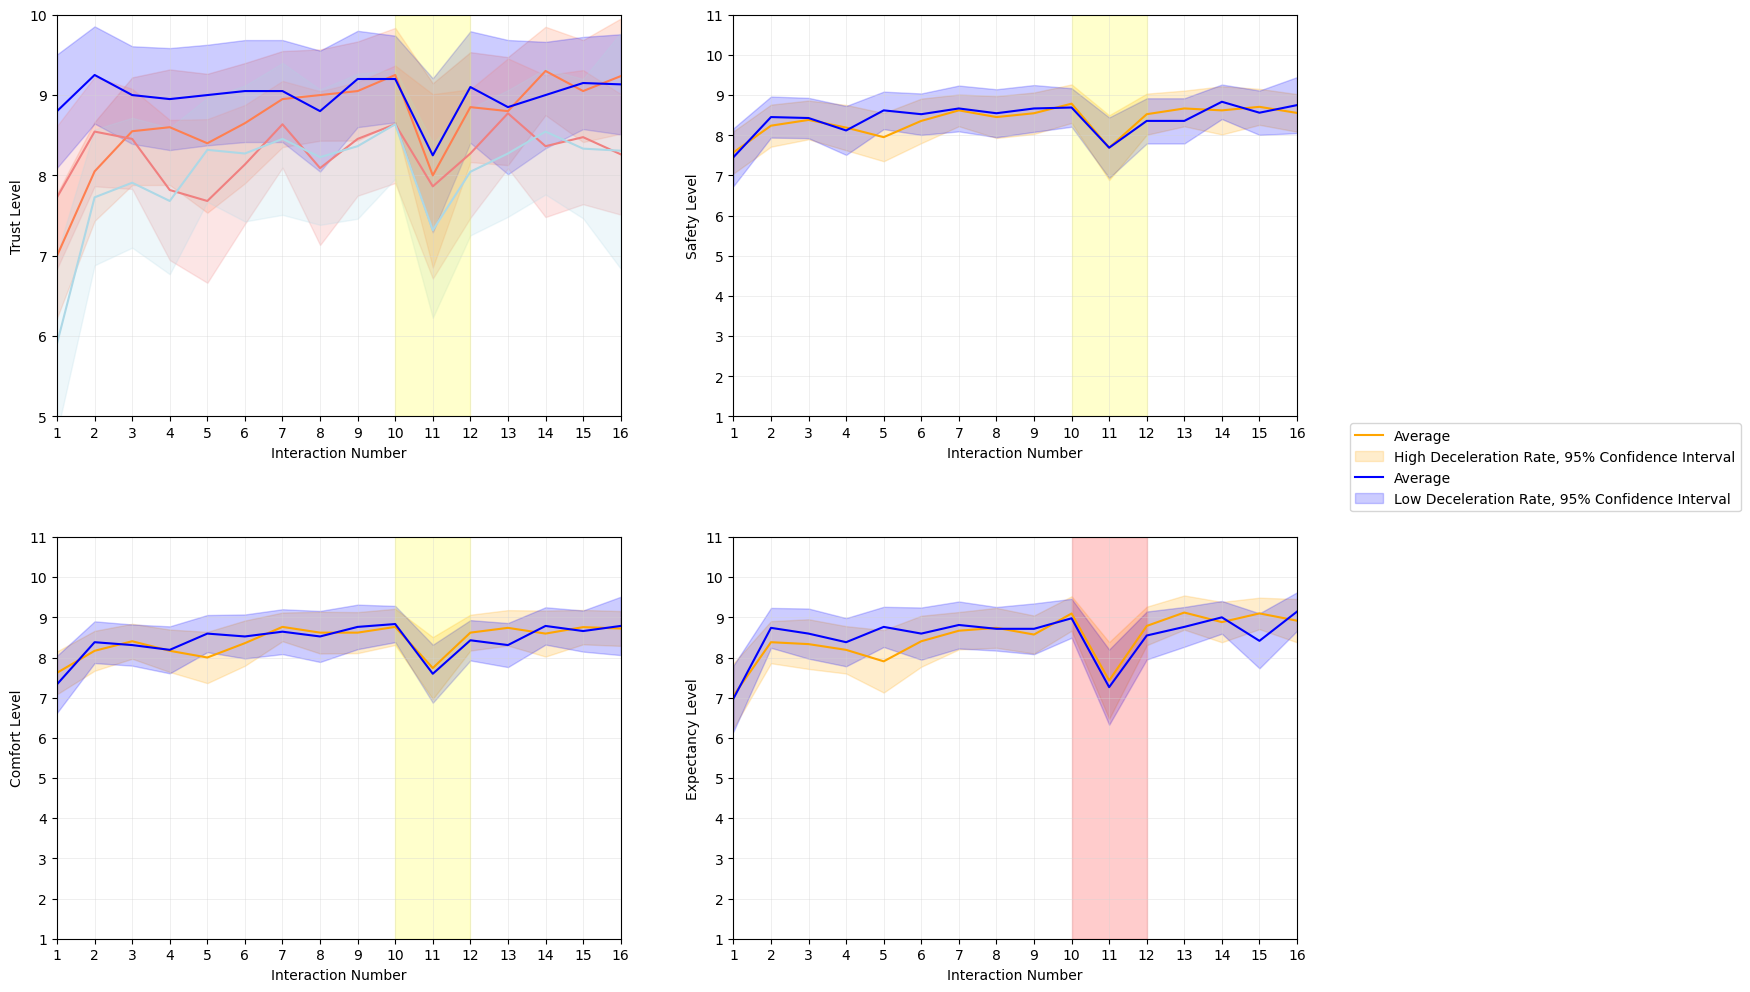

In [225]:
fig, axs = plt.subplots(2, 2, figsize=(16, 12), sharex = False)

# 1.1. high-first-low-last
axs[0,0].plot(model_data_hfll_high_trust['Interaction No'], model_data_hfll_high_trust['Trust_mean'], label = 'Average', color = 'coral')
axs[0,0].fill_between(model_data_hfll_high_trust['Interaction No'], model_data_hfll_high_trust['Trust_ci_lower'], model_data_hfll_high_trust['Trust_ci_upper'], color='coral', alpha = 0.20, label = 'High Deceleration Rate, 95% Confidence Interval')

axs[0,0].plot(model_data_hfll_low_trust['Interaction No'], model_data_hfll_low_trust['Trust_mean'], label = 'Average', color = 'blue')
axs[0,0].fill_between(model_data_hfll_low_trust['Interaction No'], model_data_hfll_low_trust['Trust_ci_lower'], model_data_hfll_low_trust['Trust_ci_upper'], color='blue', alpha = 0.20, label = 'Low Deceleration Rate, 95% Confidence Interval')

# 1.2. low-first-high-last
axs[0,0].plot(model_data_lfhl_high_trust['Interaction No'], model_data_lfhl_high_trust['Trust_mean'], label = 'Average', color = 'lightcoral')
axs[0,0].fill_between(model_data_lfhl_high_trust['Interaction No'], model_data_lfhl_high_trust['Trust_ci_lower'], model_data_lfhl_high_trust['Trust_ci_upper'], color='lightcoral', alpha = 0.20, label = 'High Deceleration Rate, 95% Confidence Interval')

axs[0,0].plot(model_data_lfhl_low_trust['Interaction No'], model_data_lfhl_low_trust['Trust_mean'], label = 'Average', color = 'lightblue')
axs[0,0].fill_between(model_data_lfhl_low_trust['Interaction No'], model_data_lfhl_low_trust['Trust_ci_lower'], model_data_lfhl_low_trust['Trust_ci_upper'], color='lightblue', alpha = 0.20, label = 'Low Deceleration Rate, 95% Confidence Interval')

axs[0,0].set_ylabel('Trust Level')
axs[0,0].set_xlabel('Interaction Number')
#axs[0,0].set_title('Linearly Interpolated Trust by Point_ID')
#axs[0,0].legend()
axs[0,0].grid(color='lightgray', linestyle='-', linewidth=0.5, alpha=0.5)
axs[0,0].set_ylim(5, 10)
axs[0,0].set_yticks(range(5, 11))
axs[0,0].set_xlim(1, 16)
axs[0,0].set_xticks(np.arange(1, 17, 1))
axs[0,0].axvspan(10, 12, color = 'yellow', alpha = 0.2)

axs[0,1].plot(model_data_high_Safe['Interaction No'], model_data_high_Safe['Safe_mean'], label = 'Average', color = 'orange')
axs[0,1].fill_between(model_data_high_Safe['Interaction No'], model_data_high_Safe['Safe_ci_lower'], model_data_high_Safe['Safe_ci_upper'], color='orange', alpha = 0.20, label = 'High Deceleration Rate, 95% Confidence Interval')
axs[0,1].plot(model_data_low_Safe['Interaction No'], model_data_low_Safe['Safe_mean'], label = 'Average', color = 'blue')
axs[0,1].fill_between(model_data_low_Safe['Interaction No'], model_data_low_Safe['Safe_ci_lower'], model_data_low_Safe['Safe_ci_upper'], color='blue', alpha = 0.20, label = 'Low Deceleration Rate, 95% Confidence Interval')
axs[0,1].set_ylabel('Safety Level')
axs[0,1].set_xlabel('Interaction Number')
#axs[0,1].set_title('Linearly Interpolated Trust by Point_ID')
#axs[0,1].legend()
axs[0,1].grid(color='lightgray', linestyle='-', linewidth=0.5, alpha=0.5)
axs[0,1].set_ylim(1, 10)
axs[0,1].set_yticks(range(1, 12))
axs[0,1].set_xlim(1, 16)
axs[0,1].set_xticks(range(1, 17))
axs[0,1].axvspan(10, 12, color = 'yellow', alpha = 0.2)

axs[1,0].plot(model_data_high_Comfort['Interaction No'], model_data_high_Comfort['Comfort_mean'], label = 'Average', color = 'orange')
axs[1,0].fill_between(model_data_high_Comfort['Interaction No'], model_data_high_Comfort['Comfort_ci_lower'], model_data_high_Comfort['Comfort_ci_upper'], color='orange', alpha = 0.20, label = 'High Deceleration Rate, 95% Confidence Interval')
axs[1,0].plot(model_data_low_Comfort['Interaction No'], model_data_low_Comfort['Comfort_mean'], label = 'Average', color = 'blue')
axs[1,0].fill_between(model_data_low_Comfort['Interaction No'], model_data_low_Comfort['Comfort_ci_lower'], model_data_low_Comfort['Comfort_ci_upper'], color='blue', alpha = 0.20, label = 'Low Deceleration Rate, 95% Confidence Interval')
axs[1,0].set_ylabel('Comfort Level')
axs[1,0].set_xlabel('Interaction Number')
#axs[1,0].set_title('Linearly Interpolated Trust by Point_ID')
#axs[1,0].legend()
axs[1,0].grid(color='lightgray', linestyle='-', linewidth=0.5, alpha=0.5)
axs[1,0].set_ylim(1, 10)
axs[1,0].set_yticks(range(1, 12))
axs[1,0].set_xlim(1, 16)
axs[1,0].set_xticks(range(1, 17))
axs[1,0].axvspan(10, 12, color = 'yellow', alpha = 0.2)

axs[1,1].plot(model_data_high_Expect['Interaction No'], model_data_high_Expect['Expect_mean'], label = 'Average', color = 'orange')
axs[1,1].fill_between(model_data_high_Expect['Interaction No'], model_data_high_Expect['Expect_ci_lower'], model_data_high_Expect['Expect_ci_upper'], color='orange', alpha = 0.20, label = 'High Deceleration Rate, 95% Confidence Interval')
axs[1,1].plot(model_data_low_Expect['Interaction No'], model_data_low_Expect['Expect_mean'], label = 'Average', color = 'blue')
axs[1,1].fill_between(model_data_low_Expect['Interaction No'], model_data_low_Expect['Expect_ci_lower'], model_data_low_Expect['Expect_ci_upper'], color='blue', alpha = 0.20, label = 'Low Deceleration Rate, 95% Confidence Interval')
axs[1,1].set_ylabel('Expectancy Level')
axs[1,1].set_xlabel('Interaction Number')
#axs[1,1].set_title('Linearly Interpolated Trust by Point_ID')
#axs[1,1].legend()
axs[1,1].grid(color='lightgray', linestyle='-', linewidth=0.5, alpha=0.5)
axs[1,1].set_ylim(1, 10)
axs[1,1].set_yticks(range(1, 12))
axs[1,1].set_xlim(1, 16)
axs[1,1].set_xticks(range(1, 17))
# Define Inset Axes
#axin = inset_axes(axs[1,1], width = '17.5%', height = '50%', loc = 'lower right')
#axin.plot(model_data_high_Expect['Interaction No'], model_data_high_Expect['Expect_mean'], label = 'Average', color = 'orange')
#axin.fill_between(model_data_high_Expect['Interaction No'], model_data_high_Expect['Expect_ci_lower'], model_data_high_Expect['Expect_ci_upper'], color='orange', alpha = 0.20, label = 'High Decelaration Rate, 95% Confidence Interval')
#axin.plot(model_data_low_Expect['Interaction No'], model_data_low_Expect['Expect_mean'], label = 'Average', color = 'blue')
#axin.fill_between(model_data_low_Expect['Interaction No'], model_data_low_Expect['Expect_ci_lower'], model_data_low_Expect['Expect_ci_upper'], color='blue', alpha = 0.20, label = 'Low Decelaration Rate, 95% Confidence Interval')
#axin.set_xlim(10, 12)
#axin.set_ylim(6,10)
#axs[1,1].indicate_inset_zoom(axin)
axs[1,1].axvspan(10, 12, color = 'red', alpha = 0.2)


plt.subplots_adjust(wspace=0.2, hspace=0.3)
#plt.xlabel('Decelaration Rate')
plt.legend(bbox_to_anchor=(1.8, 1.3))
# Adjust layout
#plt.tight_layout()

# generate a timestamp for the uniqueness 
timestamp = datetime.now().strftime("%Y%m%d%H%M%S")

# Define the filename with timestamp
# filename = f'Fill_Between_Plot_of_Dependent_Variables_History_46_Participants_with_axvspan_{timestamp}.png'
#plt.savefig(save_dir + filename, bbox_inches = 'tight', pad_inches=0.1)

plt.show()

C:\Users\HIALAB\AppData\Local\Temp\ipykernel_79320\3193599124.py:4: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(df[x_col], df[y_col], cmap=colormap, alpha=0.9,  edgecolor='black')


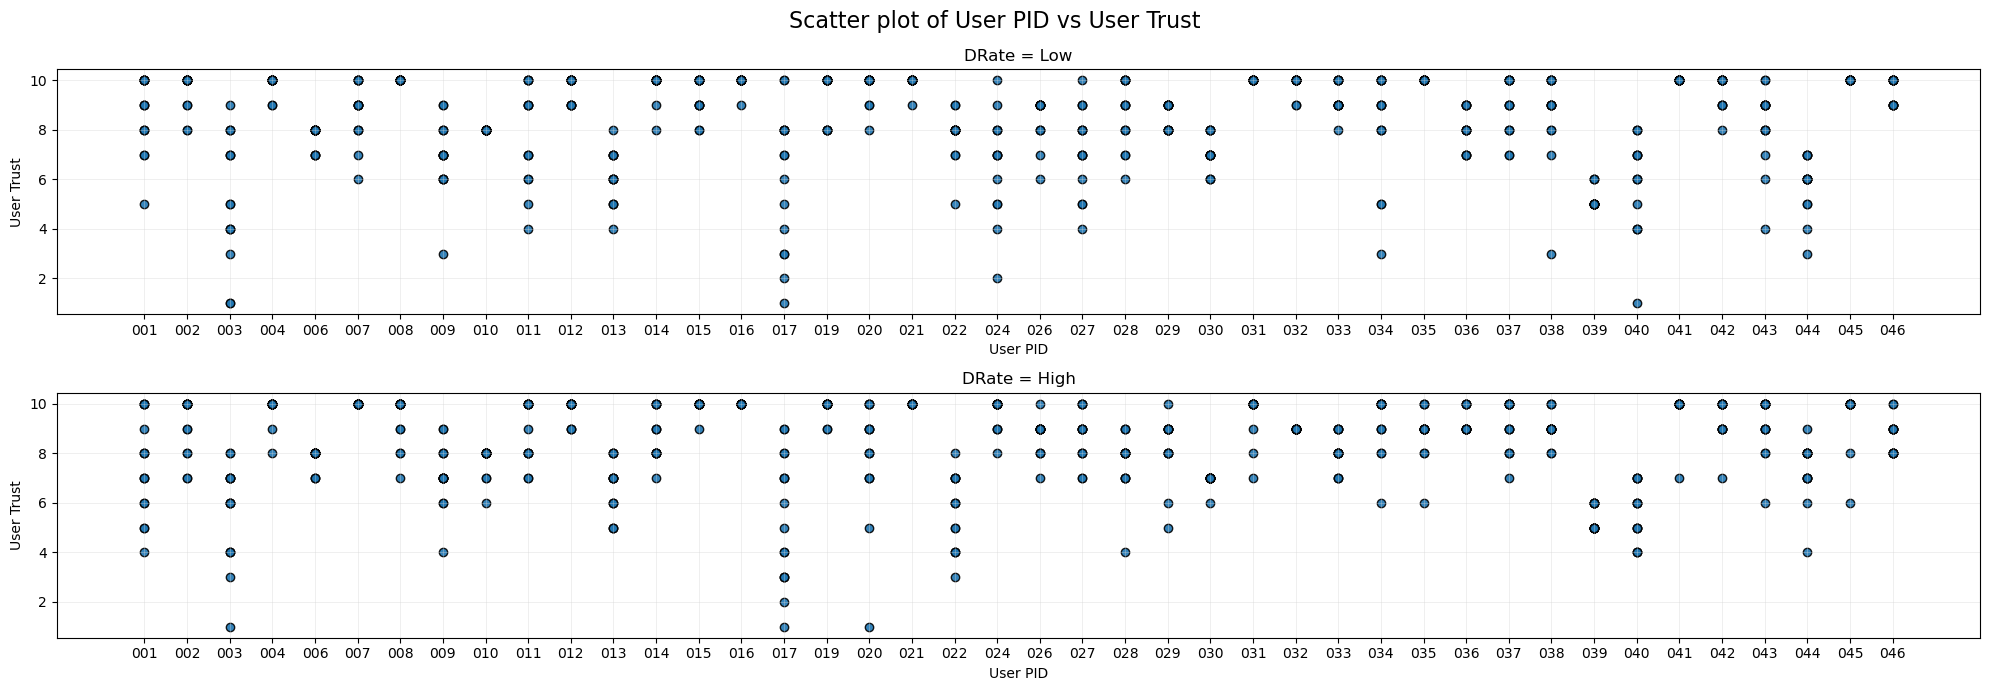

In [226]:
# Fixing random state for reproducibility
def create_scatter_plot(ax, df, x_col, y_col, colormap='viridis', title=None):

    scatter = ax.scatter(df[x_col], df[y_col], cmap=colormap, alpha=0.9,  edgecolor='black')
    
    # Adding lables and titles
    ax.set_xlabel('User PID')
    ax.set_ylabel('User Trust')
    if title:
        ax.set_title(title)
    else:
        ax.set_title('Scatter plot of User PID vs User trust')
    
    ax.grid(color='lightgray', linestyle='-', linewidth=0.5, alpha=0.5)

model_data_low = model_data[model_data['DRate'] == 'Low']
model_data_high = model_data[model_data['DRate'] == 'High']

# Create subplots side by side
fig, axes = plt.subplots(2, 1, figsize=(20, 7))

create_scatter_plot(axes[0], model_data_low, 'PID', 'Trust', title = 'DRate = Low')
create_scatter_plot(axes[1], model_data_high, 'PID', 'Trust', title = 'DRate = High')

# Set an overall title
fig.suptitle('Scatter plot of User PID vs User Trust', fontsize=16)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

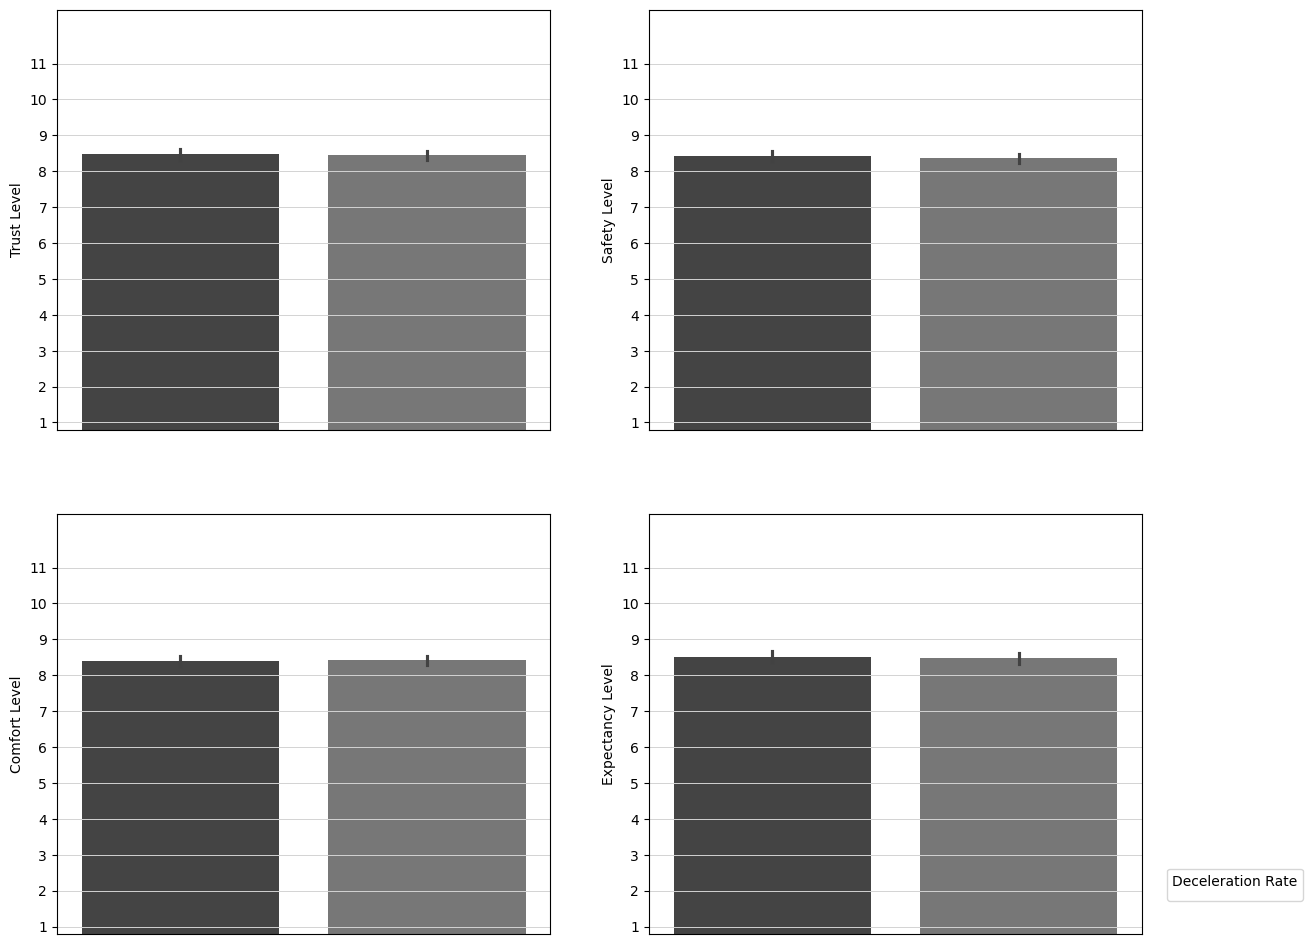

In [227]:
palette = sns.color_palette(['#777777', '#444444'], n_colors=model_data['DRate'].nunique())

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Specify the order of the x values
custom_order = ['Low', 'High']

# Bar plot for Trust Level
sns.barplot(ax=axes[0, 0],
    x='DRate', y='Trust', 
    data=model_data, hue='DRate', palette=palette, order=custom_order, dodge=False
)
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Trust Level")
axes[0, 0].set_ylim(0.8, 12.5)
axes[0, 0].set_yticks(range(1, 12))
axes[0, 0].set_xticks([])
axes[0, 0].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

# Bar plot for Safety Level
sns.barplot(ax=axes[0, 1],
    x='DRate', y='Safe', 
    data=model_data, hue='DRate', palette=palette, order=custom_order
)
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Safety Level")
axes[0, 1].set_ylim(0.8, 12.5)
axes[0, 1].set_yticks(range(1, 12))
axes[0, 1].set_xticks([])
axes[0, 1].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

# Bar plot for Comfort Level
sns.barplot(ax=axes[1, 0],
    x='DRate', y='Comfort', 
    data=model_data, hue='DRate', palette=palette, order=custom_order
)
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Comfort Level")
axes[1, 0].set_ylim(0.8, 12.5)
axes[1, 0].set_yticks(range(1, 12))
axes[1, 0].set_xticks([])
axes[1, 0].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

# Bar plot for Expectancy Level
sns.barplot(ax=axes[1, 1],
    x='DRate', y='Expect', 
    data=model_data, hue='DRate', palette=palette, order=custom_order
)
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Expectancy Level")
axes[1, 1].set_ylim(0.8, 12.5)
axes[1, 1].set_yticks(range(1, 12))
axes[1, 1].set_xticks([])
axes[1, 1].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

# Creating a single legend for the whole plot
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', title='Deceleration Rate', bbox_to_anchor=(1.02, 0.17))

# Removing the legends from individual plots, since a single legend is used for the entire figure
for ax in axes.flat:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

plt.subplots_adjust(wspace=0.2, hspace=0.2)

plt.show()

In [228]:
# You need to show the intensity of each trust value chosen by the user. For instance, PID = 4 has less than ten unique trust values, so some of them has been picked up multiple times, thus the scatters need to be correlated by the frequency.
# Also, consider comparing the average, std, and mode among different users.

### With Respect to AGV Approaching Direction

In [230]:
# Checking out unique values of AGVs approaching direction
model_data['AGV_Approaching'].unique()

array(['South', 'North', 'Northeast', 'Northwest', 'East', 'Southwest',
       'West', 'Southeast'], dtype=object)

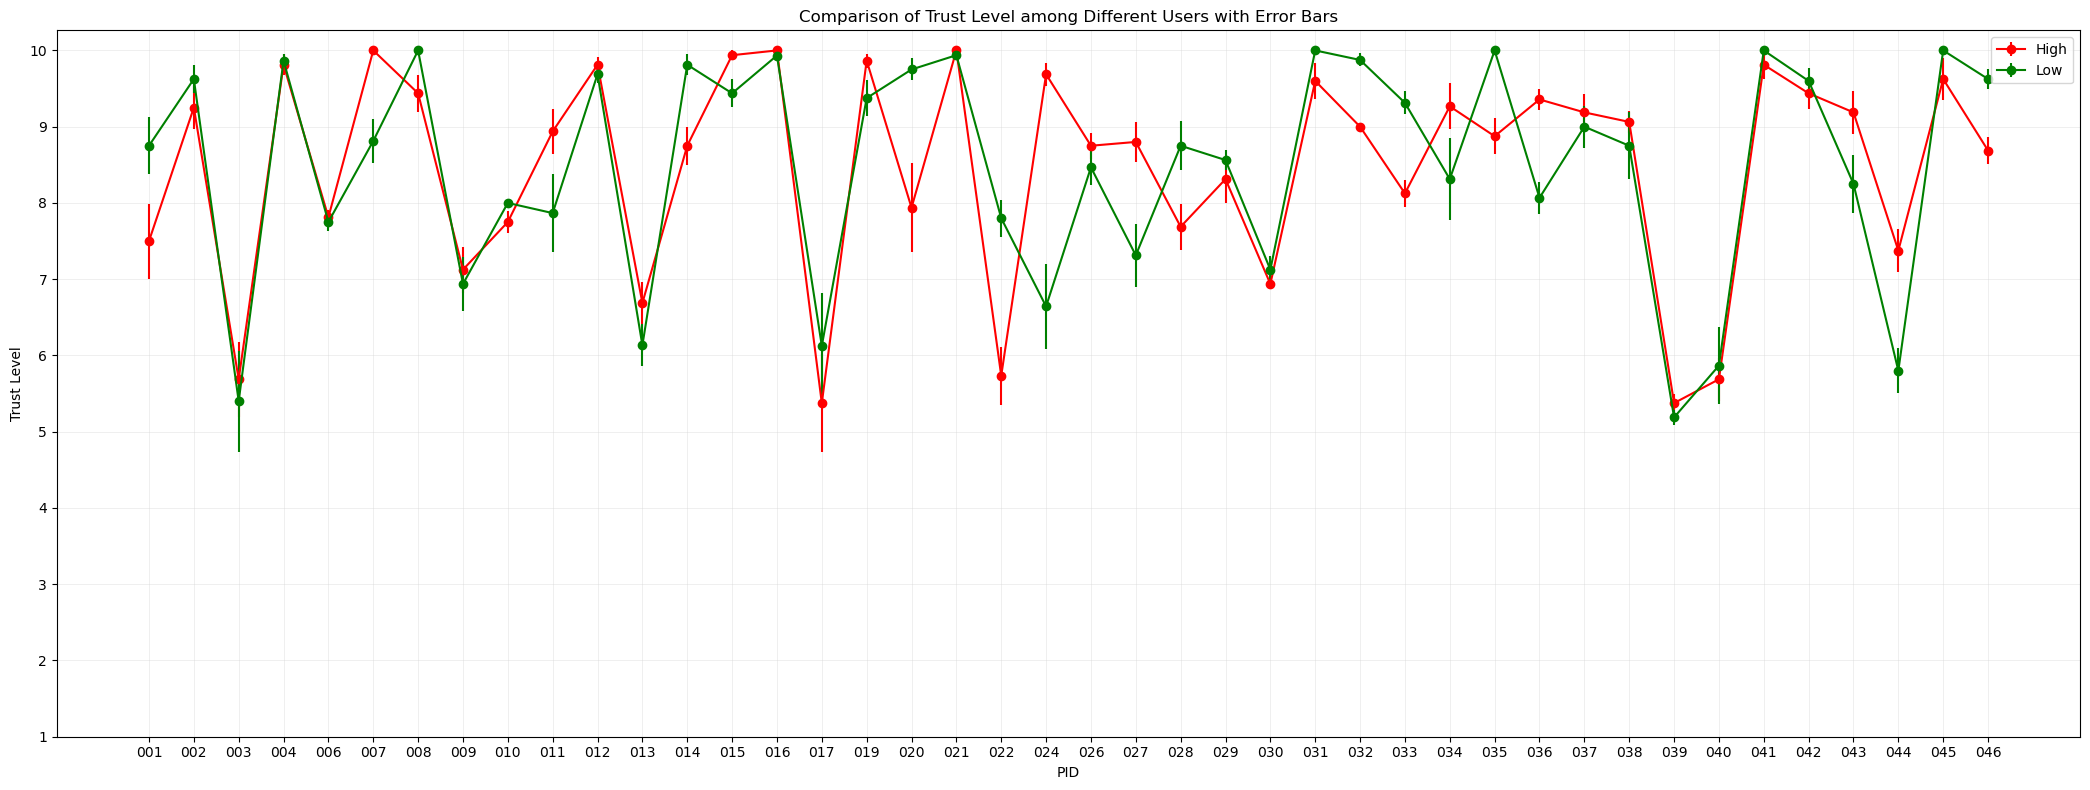

In [231]:
# Renaming the columns for this visualization
model_data_w_error_bars = model_data.rename(columns={'PID':'x', 'Trust':'y', 'DRate': 'group'})

# Custom function to calculate standard error
def standard_error(x):
    return x.std()/np.sqrt(len(x))

# Calculate the mean and standard deviation for each y column grouped by x and group
# By specifying the aggeregation function, it tells pandas to calculate bothe the mean and the standard deviation
grouped_w_error_bars = model_data_w_error_bars.groupby(['x', 'group']).agg({
    'y': ['mean',standard_error]
}).reset_index()

# Flatten the columns MultiIndex
grouped_w_error_bars.columns = ['x', 'group', 'y_mean', 'y_std']

grouped_w_error_bars_high = grouped_w_error_bars[grouped_w_error_bars['group'] == 'High']
grouped_w_error_bars_low = grouped_w_error_bars[grouped_w_error_bars['group'] == 'Low']

# Creat a figure 
fig, ax = plt.subplots(figsize = (21, 8))

# Plotting with error bars
ax.errorbar(grouped_w_error_bars_high['x'], grouped_w_error_bars_high['y_mean'], grouped_w_error_bars_high['y_std'], fmt='-o', label = 'High', color='red')
ax.errorbar(grouped_w_error_bars_low['x'], grouped_w_error_bars_low['y_mean'], grouped_w_error_bars_low['y_std'], fmt='-o', label = 'Low', color='green')

y_min = model_data['Trust'].min()
y_max = model_data['Trust'].max()
ax.set_yticks(np.arange(y_min, y_max + 1, 1))

# Add a light gray grid
ax.grid(color='lightgray', linestyle='-', linewidth=0.5, alpha=0.5)

# Adding titles and labels 
ax.set_title('Comparison of Trust Level among Different Users with Error Bars')
ax.set_xlabel('PID')
ax.set_ylabel('Trust Level')
ax.legend()


# generate a timestamp for the uniqueness 
timestamp = datetime.now().strftime("%Y%m%d%H%M%S")

# Define the filename with timestamp
filename = f'Comparison of Trust Level among Different Users with Error Bars_{timestamp}.png'
#plt.savefig(save_dir + filename, bbox_inches = 'tight', pad_inches=0.1)

# Show the plot
plt.tight_layout()
plt.show()

In [232]:
# Find a way that would show the min and max value of trust.

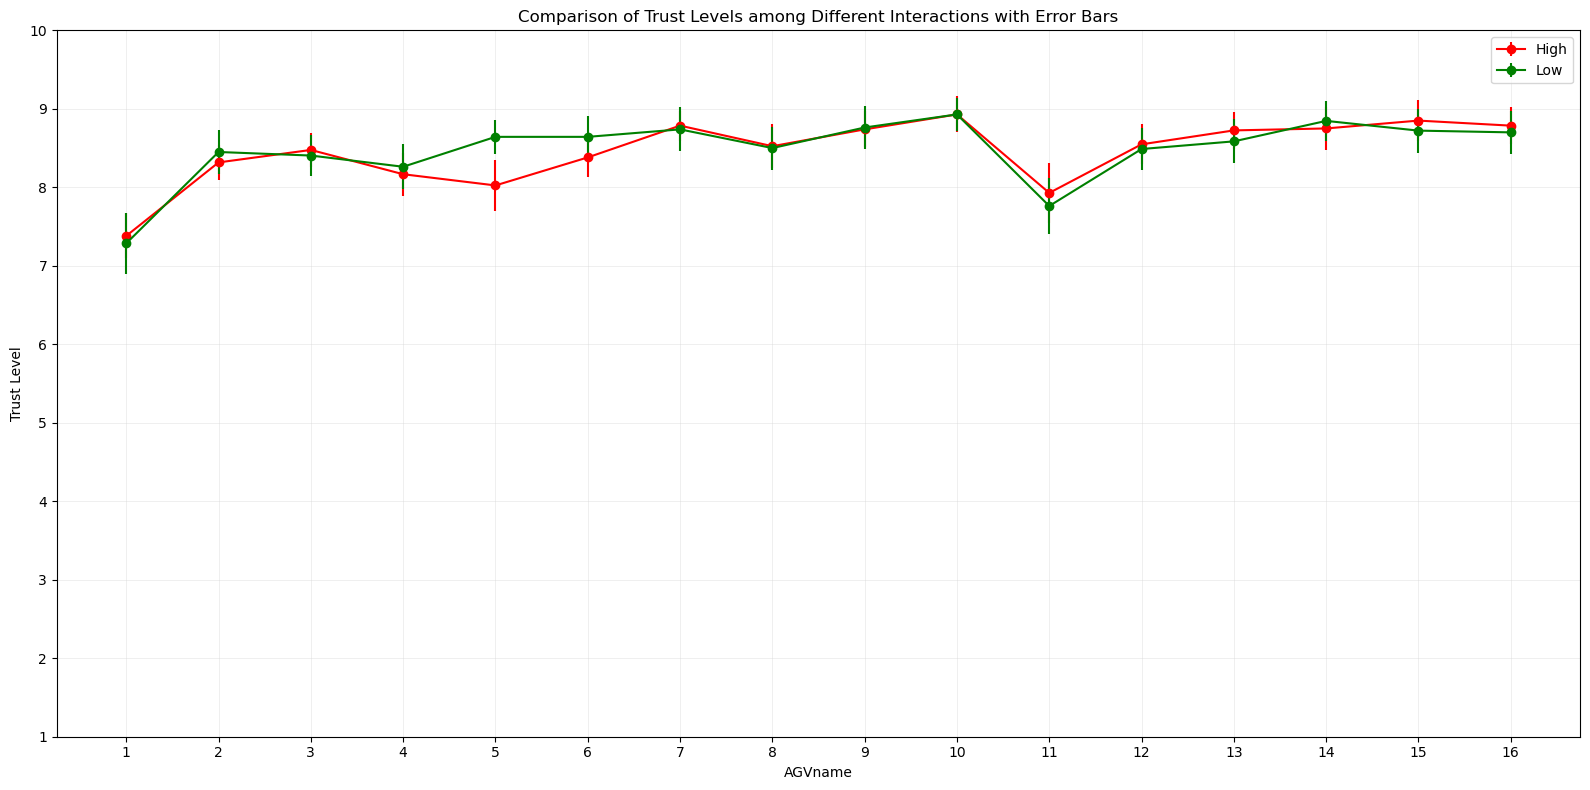

In [233]:
# Renaming the columns for this visualization
model_data_w_error_bars = model_data.rename(columns={'AGVname':'x', 'Trust':'y', 'DRate': 'group'})

# Custom function to calculate standard error
def standard_error(x):
    return x.std()/np.sqrt(len(x))

# Calculate the mean and standard deviation for each y column grouped by x and group
# By specifying the aggeregation function, it tells pandas to calculate bothe the mean and the standard deviation
grouped_w_error_bars = model_data_w_error_bars.groupby(['x', 'group']).agg({
    'y': ['mean',standard_error]
}).reset_index()

# Flatten the columns MultiIndex
grouped_w_error_bars.columns = ['x', 'group', 'y_mean', 'y_std']

grouped_w_error_bars_high = grouped_w_error_bars[grouped_w_error_bars['group'] == 'High']
grouped_w_error_bars_low = grouped_w_error_bars[grouped_w_error_bars['group'] == 'Low']

# Creat a figure 
fig, ax = plt.subplots(figsize = (16, 8))

# Plotting with error bars
ax.errorbar(grouped_w_error_bars_high['x'], grouped_w_error_bars_high['y_mean'], grouped_w_error_bars_high['y_std'], fmt='-o', label = 'High', color='red')
ax.errorbar(grouped_w_error_bars_low['x'], grouped_w_error_bars_low['y_mean'], grouped_w_error_bars_low['y_std'], fmt='-o', label = 'Low', color='green')

# Set x-axis and y-axis to increament by one unit
x_min = model_data['AGVname'].min()
x_max = model_data['AGVname'].max()
ax.set_xticks(np.arange(x_min, x_max + 1, 1))

y_min = model_data['Trust'].min()
y_max = model_data['Trust'].max()
ax.set_yticks(np.arange(y_min, y_max + 1, 1))

# Add a light gray grid
ax.grid(color='lightgray', linestyle='-', linewidth=0.5, alpha=0.5)

# Adding titles and labels 
ax.set_title('Comparison of Trust Levels among Different Interactions with Error Bars')
ax.set_xlabel('AGVname')
ax.set_ylabel('Trust Level')
ax.legend()

# generate a timestamp for the uniqueness 
timestamp = datetime.now().strftime("%Y%m%d%H%M%S")

# Define the filename with timestamp
filename = f'Comparison of Trust Levels among Different Interactions with Error Bars_{timestamp}.png'
#plt.savefig(save_dir + filename, bbox_inches = 'tight', pad_inches=0.1)

# Show the plot
plt.tight_layout()
plt.show()

In [234]:
# You should highlight those pairs of AGVs that are having the same approaching direction.

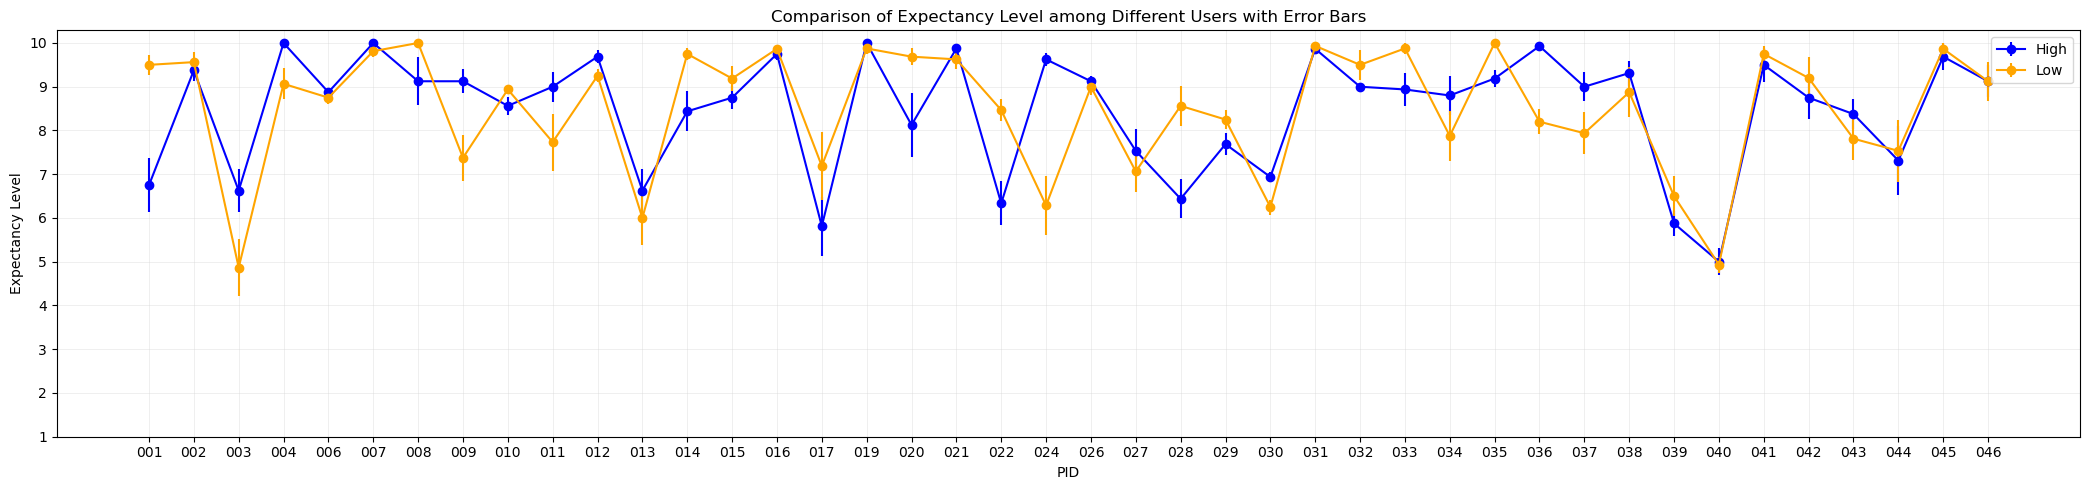

In [235]:
# Renaming the columns for this visualization
model_data_w_error_bars = model_data.rename(columns={'PID':'x', 'Expect':'y', 'DRate': 'group'})

# Custom function to calculate standard error
def standard_error(x):
    return x.std()/np.sqrt(len(x))

# Calculate the mean and standard deviation for each y column grouped by x and group
# By specifying the aggeregation function, it tells pandas to calculate bothe the mean and the standard deviation
grouped_w_error_bars = model_data_w_error_bars.groupby(['x', 'group']).agg({
    'y': ['mean',standard_error]
}).reset_index()

# Flatten the columns MultiIndex
grouped_w_error_bars.columns = ['x', 'group', 'y_mean', 'y_std']

grouped_w_error_bars_high = grouped_w_error_bars[grouped_w_error_bars['group'] == 'High']
grouped_w_error_bars_low = grouped_w_error_bars[grouped_w_error_bars['group'] == 'Low']

# Creat a figure 
fig, ax = plt.subplots(figsize = (21, 5))

# Plotting with error bars
ax.errorbar(grouped_w_error_bars_high['x'], grouped_w_error_bars_high['y_mean'], grouped_w_error_bars_high['y_std'], fmt='-o', label = 'High', color='blue')
ax.errorbar(grouped_w_error_bars_low['x'], grouped_w_error_bars_low['y_mean'], grouped_w_error_bars_low['y_std'], fmt='-o', label = 'Low', color='orange')

y_min = model_data['Trust'].min()
y_max = model_data['Trust'].max()
ax.set_yticks(np.arange(y_min, y_max + 1, 1))

# Add a light gray grid
ax.grid(color='lightgray', linestyle='-', linewidth=0.5, alpha=0.5)

# Adding titles and labels 
ax.set_title('Comparison of Expectancy Level among Different Users with Error Bars')
ax.set_xlabel('PID')
ax.set_ylabel('Expectancy Level')
ax.legend()

# Define the filename with timestamp
filename = 'Comparison of Expectancy Level among Different Users with Error Bars'
# plt.savefig(save_dir + filename, bbox_inches = 'tight', pad_inches=0.1)

# Show the plot
plt.tight_layout()
plt.show()

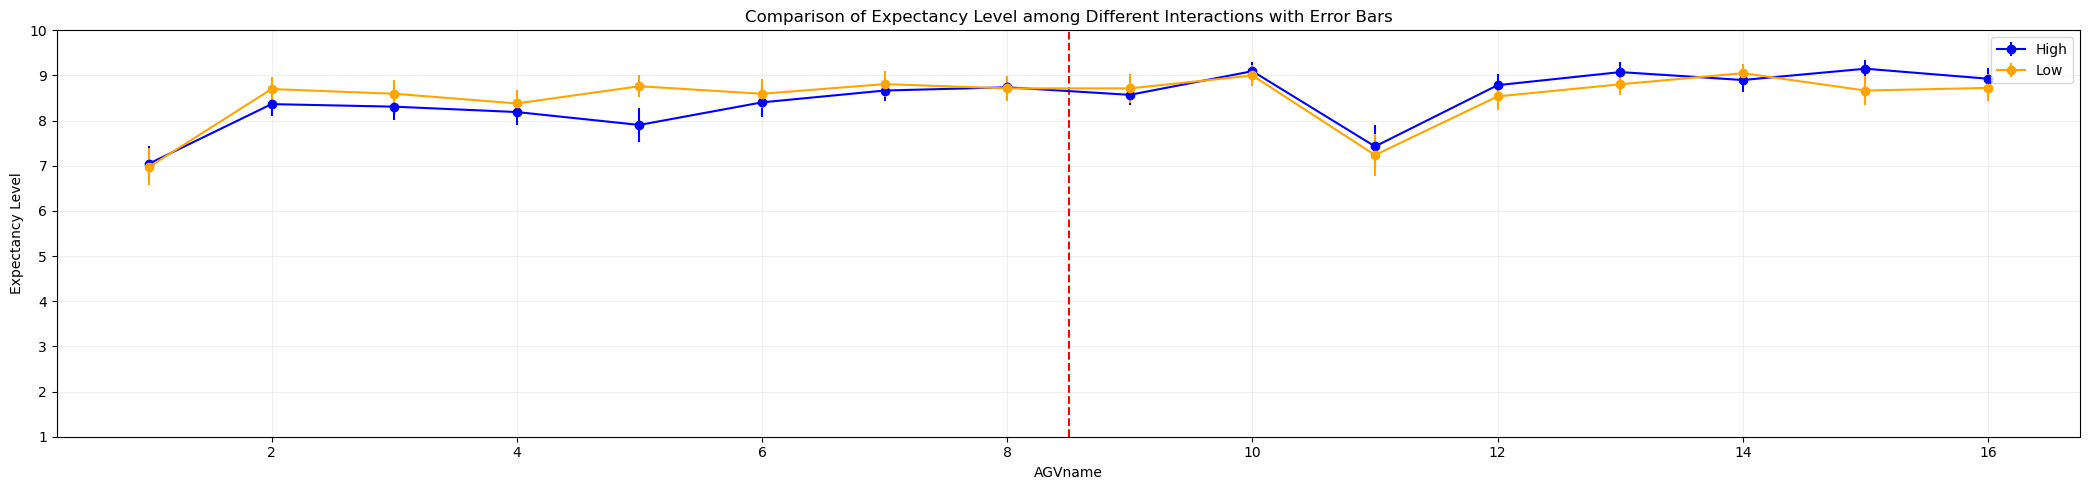

In [236]:
# Renaming the columns for this visualization
model_data_w_error_bars = model_data.rename(columns={'AGVname':'x', 'Expect':'y', 'DRate': 'group'})

# Custom function to calculate standard error
def standard_error(x):
    return x.std()/np.sqrt(len(x))

# Calculate the mean and standard deviation for each y column grouped by x and group
# By specifying the aggeregation function, it tells pandas to calculate bothe the mean and the standard deviation
grouped_w_error_bars = model_data_w_error_bars.groupby(['x', 'group']).agg({
    'y': ['mean',standard_error]
}).reset_index()

# Flatten the columns MultiIndex
grouped_w_error_bars.columns = ['x', 'group', 'y_mean', 'y_std']

grouped_w_error_bars_high = grouped_w_error_bars[grouped_w_error_bars['group'] == 'High']
grouped_w_error_bars_low = grouped_w_error_bars[grouped_w_error_bars['group'] == 'Low']

# Creat a figure 
fig, ax = plt.subplots(figsize = (21, 5))

# Plotting with error bars
ax.errorbar(grouped_w_error_bars_high['x'], grouped_w_error_bars_high['y_mean'], grouped_w_error_bars_high['y_std'], fmt='-o', label = 'High', color='blue')
ax.errorbar(grouped_w_error_bars_low['x'], grouped_w_error_bars_low['y_mean'], grouped_w_error_bars_low['y_std'], fmt='-o', label = 'Low', color='orange')

y_min = model_data['Trust'].min()
y_max = model_data['Trust'].max()
ax.set_yticks(np.arange(y_min, y_max + 1, 1))

# Add a light gray grid
ax.grid(color='lightgray', linestyle='-', linewidth=0.5, alpha=0.5)

# Adding titles and labels 
ax.set_title('Comparison of Expectancy Level among Different Interactions with Error Bars')
ax.set_xlabel('AGVname')
ax.set_ylabel('Expectancy Level')
ax.legend()

plt.axvline(x=8.5, color='r', linestyle='--')

# Define the filename with timestamp
filename = 'Comparison of Expectancy Level among Different Interactions with Error Bars'
# plt.savefig(save_dir + filename, bbox_inches = 'tight', pad_inches=0.1)

# Show the plot
plt.tight_layout()
plt.show()

TypeError: can only concatenate str (not "int") to str

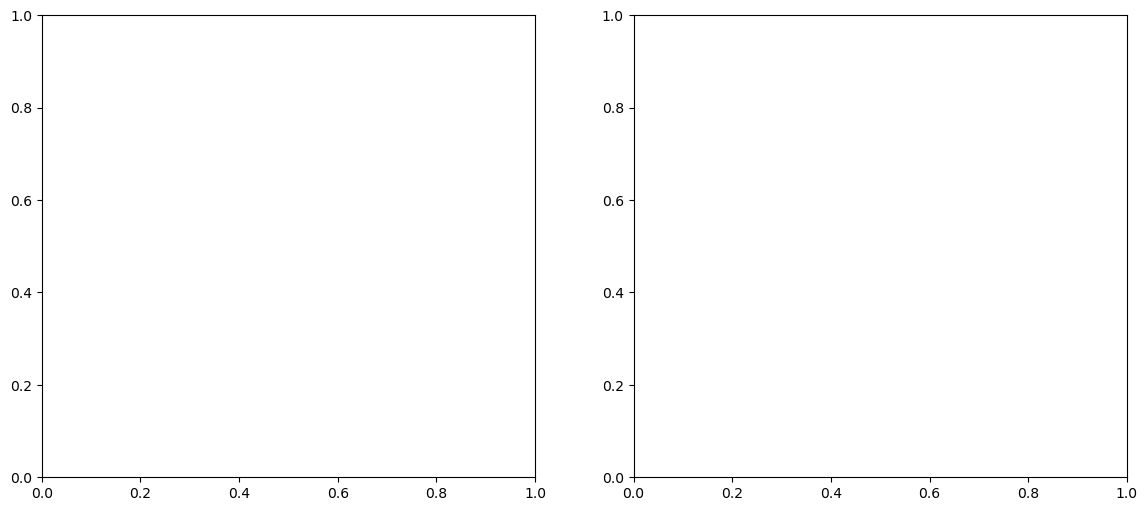

In [237]:
# Filter data by DRate: We've already done that in the pervious kernels though:
model_data_high = model_data[model_data['DRate'] == 'High']
model_data_low = model_data[model_data['DRate'] == 'Low']


# Create pivot tables
pivot_high = model_data_high.pivot_table(index = 'PID', columns = 'AGVname', values='Trust', aggfunc = 'mean', fill_value=0)
pivot_low = model_data_low.pivot_table(index = 'PID', columns = 'AGVname', values='Trust', aggfunc = 'mean', fill_value=0)

# Extract relevant columns
# x_high = model_data_low['Trust']
# y_high = model_data_low['PID']
# x_low = model_data_high['Trust']
# y_low = model_data_high['PID']

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 6))

y_min = model_data['PID'].min()
y_max = model_data['PID'].max()
ax1.set_yticks(np.arange(y_min, y_max + 1, 1))
ax2.set_yticks(np.arange(y_min, y_max + 1, 1))

# Plot heatmap for the high category
sns.heatmap(pivot_high, ax = ax1, cmap='RdYlGn', square = True, cbar=False)
# Adding titles and labels 
ax1.set_title('High Deceleration Rate')
ax1.set_xlabel('AGVname')
ax1.set_ylabel('User ID')

# Plot heatmap for the low category
sns.heatmap(pivot_low, ax = ax2, cmap='RdYlGn', square = True, cbar=False)
# Adding titles and labels 
ax2.set_title('Low Deceleration Rate')
ax2.set_xlabel('AGVname')
ax2.set_ylabel('User ID')

# Add a single color bar for both heatmaps
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
sns.heatmap(pivot_high, ax=ax1, cmap='RdYlGn', cbar_ax=cbar_ax, cbar_kws={'label': 'Trust Level'})

# Set the overall title
fig.suptitle('Heatmap of Trust for High vs. Low Deceleration Rate', fontsize = 14)

# Define the filename 
filename = 'Heatmap of Trust for Low vs High Deceleration Rate'
# plt.savefig(save_dir + filename, bbox_inches = 'tight', pad_inches=0.1)

# plt.tight_layout()
plt.show()

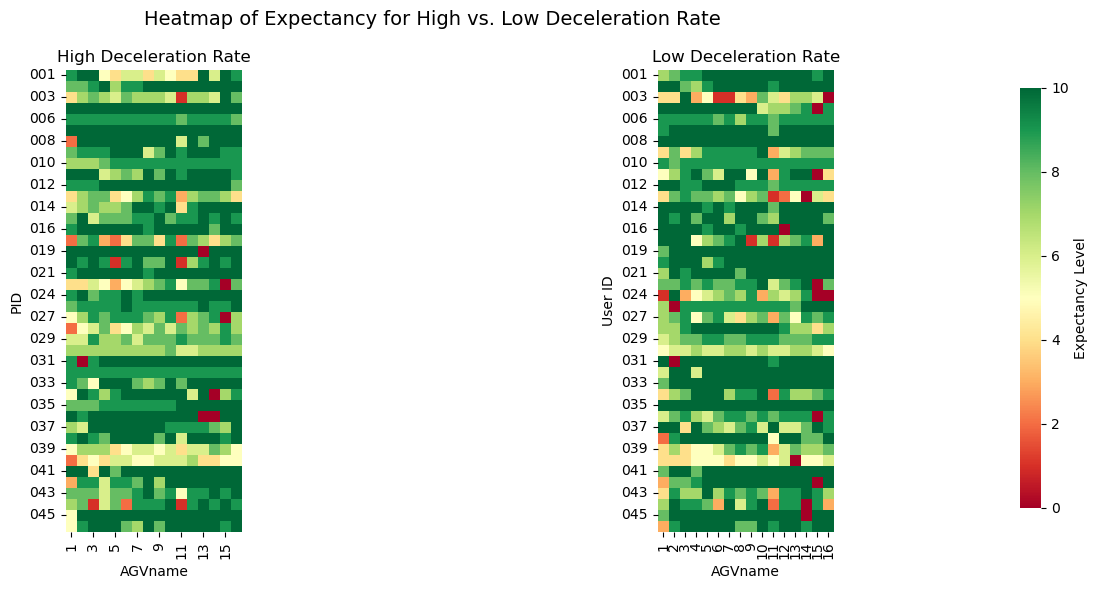

In [257]:
# Filter data by DRate: We've already done that in the pervious kernels though:
model_data_high = model_data[model_data['DRate'] == 'High']
model_data_low = model_data[model_data['DRate'] == 'Low']

# Create pivot tables
pivot_low = model_data_low.pivot_table(index = 'PID', columns = 'AGVname', values='Expect', aggfunc = 'mean', fill_value=0)
pivot_high = model_data_high.pivot_table(index = 'PID', columns = 'AGVname', values='Expect', aggfunc = 'mean', fill_value=0)

# Extract relevant columns
# x_high = model_data_low['Trust']
# y_high = model_data_low['PID']
# x_low = model_data_high['Trust']
# y_low = model_data_high['PID']

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 6))

y_min = model_data['PID'].min()
y_max = model_data['PID'].max()
#ax1.set_yticks(np.arange(y_min, y_max + 1, 1))
#ax2.set_yticks(np.arange(y_min, y_max + 1, 1))

# Plot heatmap for the high category
sns.heatmap(pivot_high, ax = ax1, cmap='RdYlGn', square = True, cbar=False)
# Adding titles and labels 
ax1.set_title('High Deceleration Rate')
ax1.set_xlabel('AGVname')
ax1.set_ylabel('User ID')

# Plot heatmap for the low category
sns.heatmap(pivot_low, ax = ax2, cmap='RdYlGn', square = True, cbar=False)
# Adding titles and labels 
ax2.set_title('Low Deceleration Rate')
ax2.set_xlabel('AGVname')
ax2.set_ylabel('User ID')
#ax2.grid(color='#222', linestyle='-', linewidth=0.01)

# Add a single color bar for both heatmaps
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
sns.heatmap(pivot_high, ax=ax1, cmap='RdYlGn', cbar_ax=cbar_ax, cbar_kws={'label': 'Expectancy Level'})
# Set the overall title
fig.suptitle(r'Heatmap of Expectancy for High vs. Low Deceleration Rate', fontsize = 14)

# Define the filename 
filename = 'Heatmap of Expectancy for Low vs High Deceleration Rate'
# plt.savefig(save_dir + filename, bbox_inches = 'tight', pad_inches=0.1)

# plt.tight_layout()
plt.show()

In [259]:
# If you're trying to compare, you can make one heatmap, where each square in representing high and low ratings with a diagonal seperating them. 
# Or, you can have a transparency, where the high rating is towards red, and low ratings towards blue colormap, and if they overlay on each other they give you spectrum of purple.
# High - Low heatmap (absolute or +/-) to see the general trend in rates changing. Look to a way that is more intuitive.

In [261]:
model_data.AGV_Approaching.unique()

array(['South', 'North', 'Northeast', 'Northwest', 'East', 'Southwest',
       'West', 'Southeast'], dtype=object)

C:\Users\HIALAB\AppData\Local\Temp\ipykernel_79320\3047312051.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(ax=axes[0, 0],
C:\Users\HIALAB\AppData\Local\Temp\ipykernel_79320\3047312051.py:20: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(ax=axes[0, 1],
C:\Users\HIALAB\AppData\Local\Temp\ipykernel_79320\3047312051.py:32: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(ax=axes[1, 0],
C:\Users\HIALAB\AppData\Local\Temp\ipykernel_79320\3047312051.py:44: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(ax=axes[1, 1],


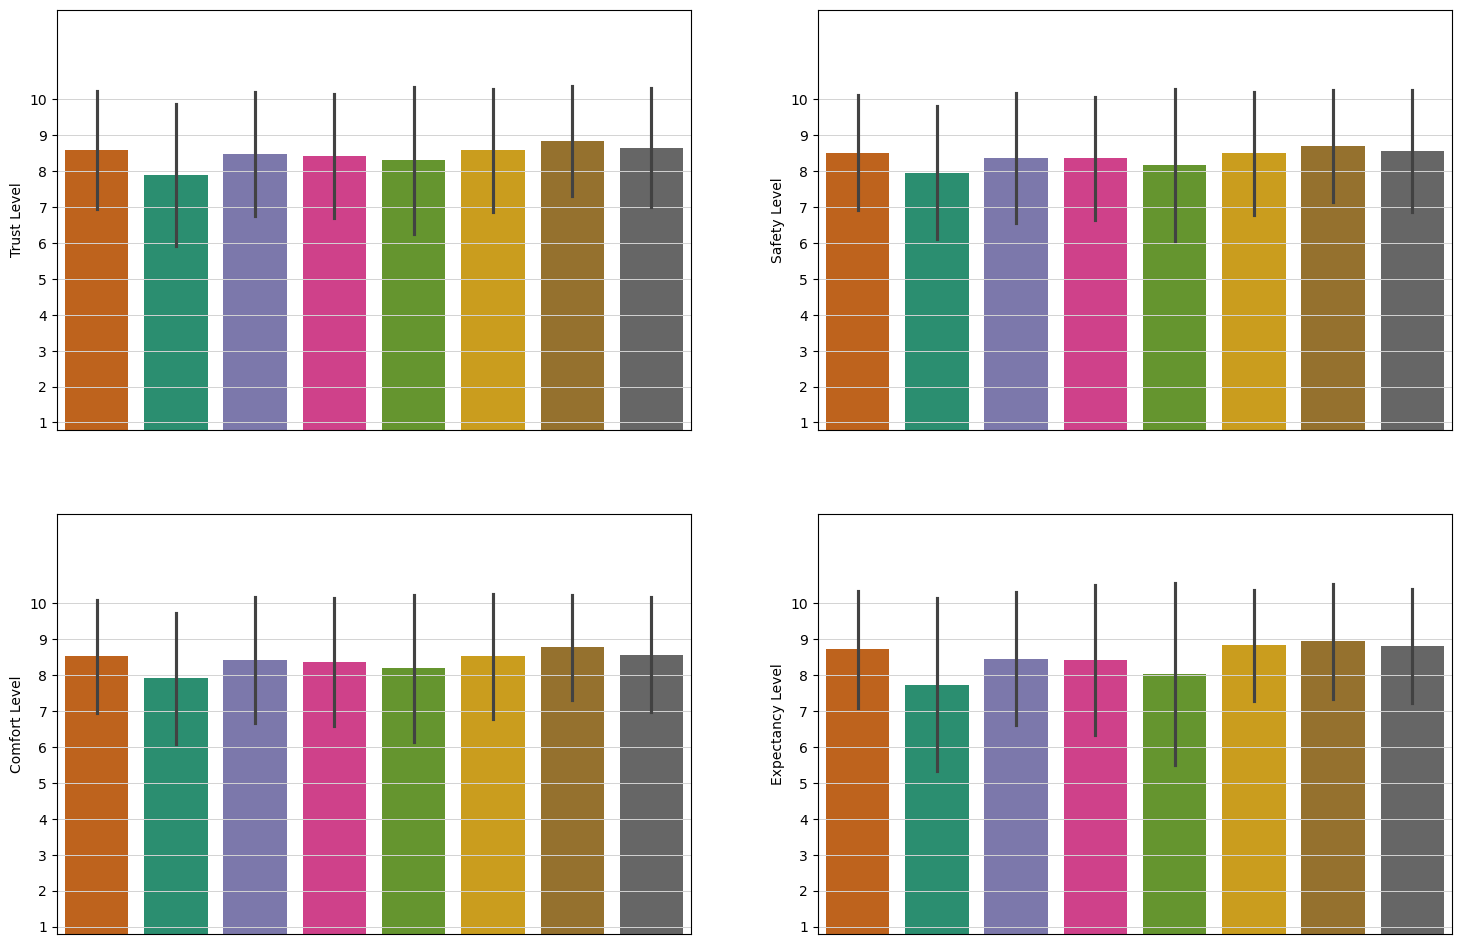

In [263]:
palette = sns.color_palette('Dark2', n_colors=model_data['AGV_Approaching'].nunique())

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Specify the order of the x values
custom_order = ['North', 'South', 'Northeast', 'Northwest', 'East', 'Southwest', 'West', 'Southeast']

sns.barplot(ax=axes[0, 0],
    x='AGV_Approaching', y='Trust',
    data=model_data, hue='AGV_Approaching', palette=palette, order=custom_order, ci='sd',
    linewidth=2, dodge=False
)
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Trust Level")
axes[0, 0].set_ylim(0.8, 12.5)
axes[0, 0].set_yticks(range(1, 11))
axes[0, 0].set_xticks([])
axes[0, 0].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

sns.barplot(ax=axes[0, 1],
    x='AGV_Approaching', y='Safe',
    data=model_data, hue='AGV_Approaching', palette=palette, order=custom_order, ci='sd',
    linewidth=2
)
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Safety Level")
axes[0, 1].set_ylim(0.8, 12.5)
axes[0, 1].set_yticks(range(1, 11))
axes[0, 1].set_xticks([])
axes[0, 1].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

sns.barplot(ax=axes[1, 0],
    x='AGV_Approaching', y='Comfort',
    data=model_data, hue='AGV_Approaching', palette=palette, order=custom_order, ci='sd',
    linewidth=2
)
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Comfort Level")
axes[1, 0].set_ylim(0.8, 12.5)
axes[1, 0].set_yticks(range(1, 11))
axes[1, 0].set_xticks([])
axes[1, 0].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

sns.barplot(ax=axes[1, 1],
    x='AGV_Approaching', y='Expect',
    data=model_data, hue='AGV_Approaching', palette=palette, order=custom_order, ci='sd',
    linewidth=2
)
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Expectancy Level")
axes[1, 1].set_ylim(0.8, 12.5)
axes[1, 1].set_yticks(range(1, 11))
axes[1, 1].set_xticks([])
axes[1, 1].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

# Creating a single legend for the whole plot
handles, labels = axes[0, 0].get_legend_handles_labels()
# fig.legend(handles, labels, loc='upper right', title='AGV Approaching Direction', bbox_to_anchor=(1.07, 0.275))

# Removing the legends from individual plots
for ax in axes.flat:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

plt.subplots_adjust(wspace=0.2, hspace=0.2)

# generate a timestamp for the uniqueness 
timestamp = datetime.now().strftime("%Y%m%d%H%M%S")

# Adjust layout
# plt.tight_layout()

# Generate a timestamp for the filename
# timestamp = datetime.now().strftime("%Y%m%d%H%M%S")

# Define the filename with timestamp
filename = f'barplots_of_four_independent_variables_based_on_AGV_approaching.png'

full_path = os.path.join(box_path + save_dir, filename)

# Save the plots in the specified directory
# plt.savefig(full_path, dpi = 300)

plt.show()

### With Respect to User_Trajectory

In [265]:
model_data.User_Trajectory.unique()

array(['Straight', 'Diagonal'], dtype=object)

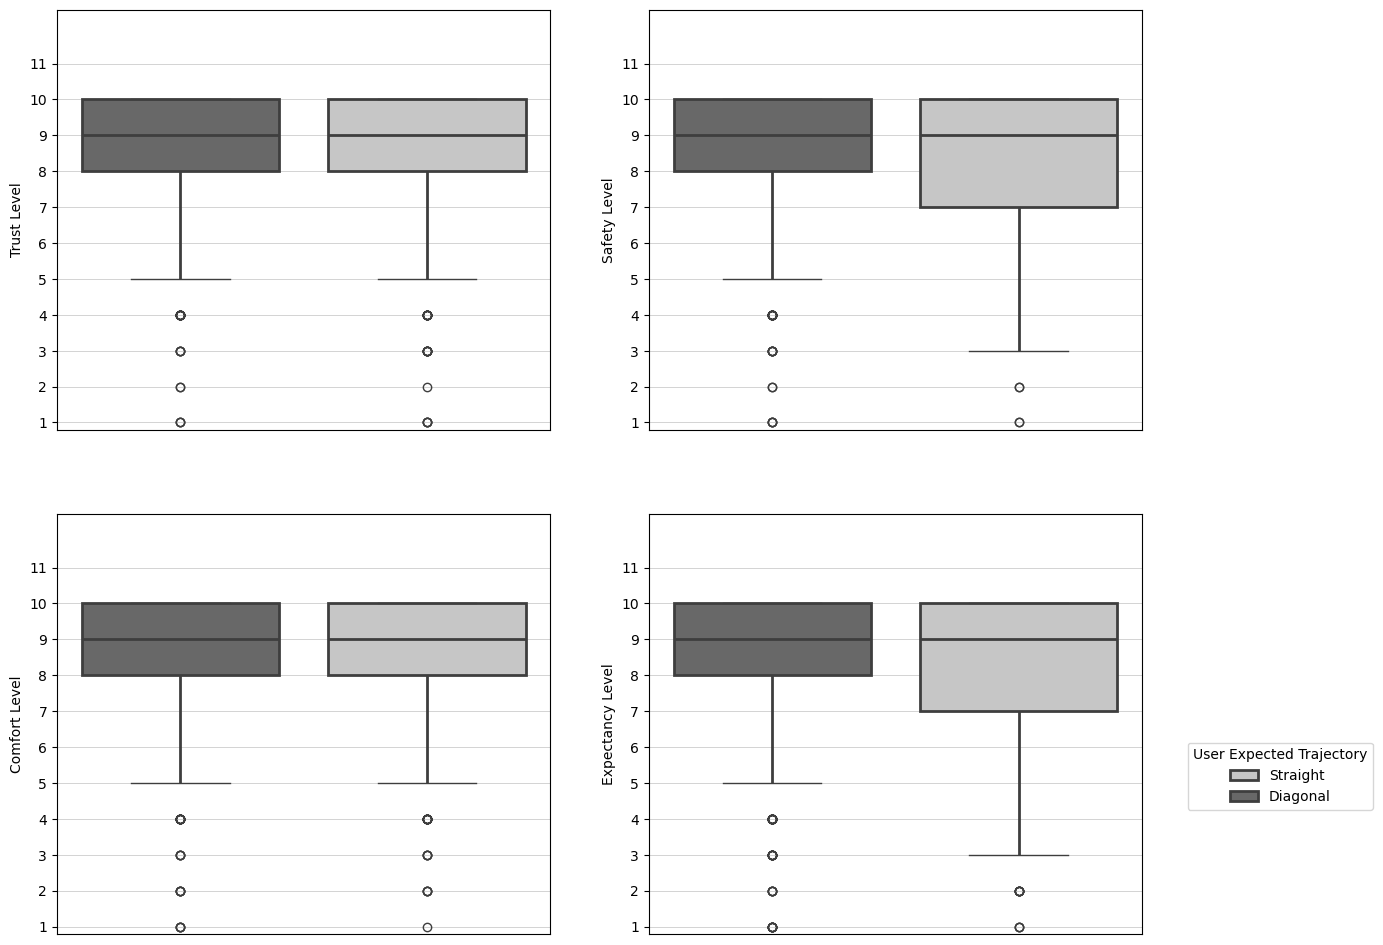

In [268]:
palette = sns.color_palette('Greys', n_colors = model_data['User_Trajectory'].nunique())

fig, axes = plt.subplots(2, 2, figsize = (14, 12))

# Specify the order of the x values
custom_order = ['Diagonal', 'Straight']

sns.boxplot(ax = axes[0, 0],
    x = 'User_Trajectory', y = 'Trust', 
    data = model_data, hue = 'User_Trajectory', palette=palette, legend = True, dodge = False, order = custom_order, linewidth = 2,
    whiskerprops = {'linewidth': 2.0},
    capprops = {'linewidth':1.0}
)
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Trust Level")
axes[0, 0].set_ylim(0.8, 12.5)
axes[0, 0].set_yticks(range(1, 12))
axes[0, 0].set_xticks([])
axes[0, 0].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

sns.boxplot(ax = axes[0, 1],
    x = 'User_Trajectory', y = 'Safe', 
    data = model_data, hue = 'User_Trajectory', palette=palette, order = custom_order, linewidth = 2,
    whiskerprops = {'linewidth': 2.0},
    capprops = {'linewidth':1.0}
)
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Safety Level")
axes[0, 1].set_ylim(0.8, 12.5)
axes[0, 1].set_yticks(range(1, 12))
axes[0, 1].set_xticks([])
axes[0, 1].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

sns.boxplot(ax = axes[1, 0],
    x = 'User_Trajectory', y = 'Comfort', 
    data = model_data, hue = 'User_Trajectory', palette=palette, order = custom_order, linewidth = 2,
    whiskerprops = {'linewidth': 2.0},
    capprops = {'linewidth':1.0}
)
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Comfort Level")
axes[1, 0].set_ylim(0.8, 12.5)
axes[1, 0].set_yticks(range(1, 12))
axes[1, 0].set_xticks([])
axes[1, 0].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

sns.boxplot(ax = axes[1, 1],
    x = 'User_Trajectory', y = 'Expect', 
    data = model_data, hue = 'User_Trajectory', palette=palette, order = custom_order, linewidth = 2,
    whiskerprops = {'linewidth': 2.0},
    capprops = {'linewidth':1.0}
)
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Expectancy Level")
axes[1, 1].set_ylim(0.8, 12.5)
axes[1, 1].set_yticks(range(1, 12))
axes[1, 1].set_xticks([])
axes[1, 1].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

#hatches = ['/','\\', '|', '-','+']
#for i, box in enumerate(boxplot.patches):
#    box.set_edgecolor('black')
#    box.set_facecolor('lightgray')
#    box.set_hatch(hatches[i])

# Creating a single legend for the whole plot
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', title = 'User Expected Trajectory', bbox_to_anchor=(1.07, 0.275))

# Removing the legends, because we wanted the first one to only save it for the whole plot
for ax in axes.flat:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

plt.subplots_adjust(wspace=0.2, hspace=0.2)

# generate a timestamp for the uniqueness 
timestamp = datetime.now().strftime("%Y%m%d%H%M%S")

# Define the filename with timestamp
filename = f'boxplots_of_four_independent_variables_based_on_user_trajectory_{timestamp}.png'
# plt.savefig(save_dir + filename, bbox_inches = 'tight', pad_inches=0.1)

plt.show()

### With Respect to AGV Approaching Direction:User_Trajectory

In [270]:
model_data.AGV_User_Combination.unique()

array(['South - Straight', 'North - Diagonal', 'South - Diagonal',
       'Northeast - Straight', 'Northwest - Straight',
       'Northwest - Diagonal', 'East - Straight', 'Southwest - Diagonal',
       'Northeast - Diagonal', 'West - Straight', 'East - Diagonal',
       'Southeast - Straight', 'Southwest - Straight',
       'Southeast - Diagonal', 'North - Straight', 'West - Diagonal'],
      dtype=object)

C:\Users\HIALAB\AppData\Local\Temp\ipykernel_79320\1840120444.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 0],
C:\Users\HIALAB\AppData\Local\Temp\ipykernel_79320\1840120444.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 1],
C:\Users\HIALAB\AppData\Local\Temp\ipykernel_79320\1840120444.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1, 0],
C:\Users\HIALAB\AppData\Local\Temp\ipykernel_79320\1840120444.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be rem

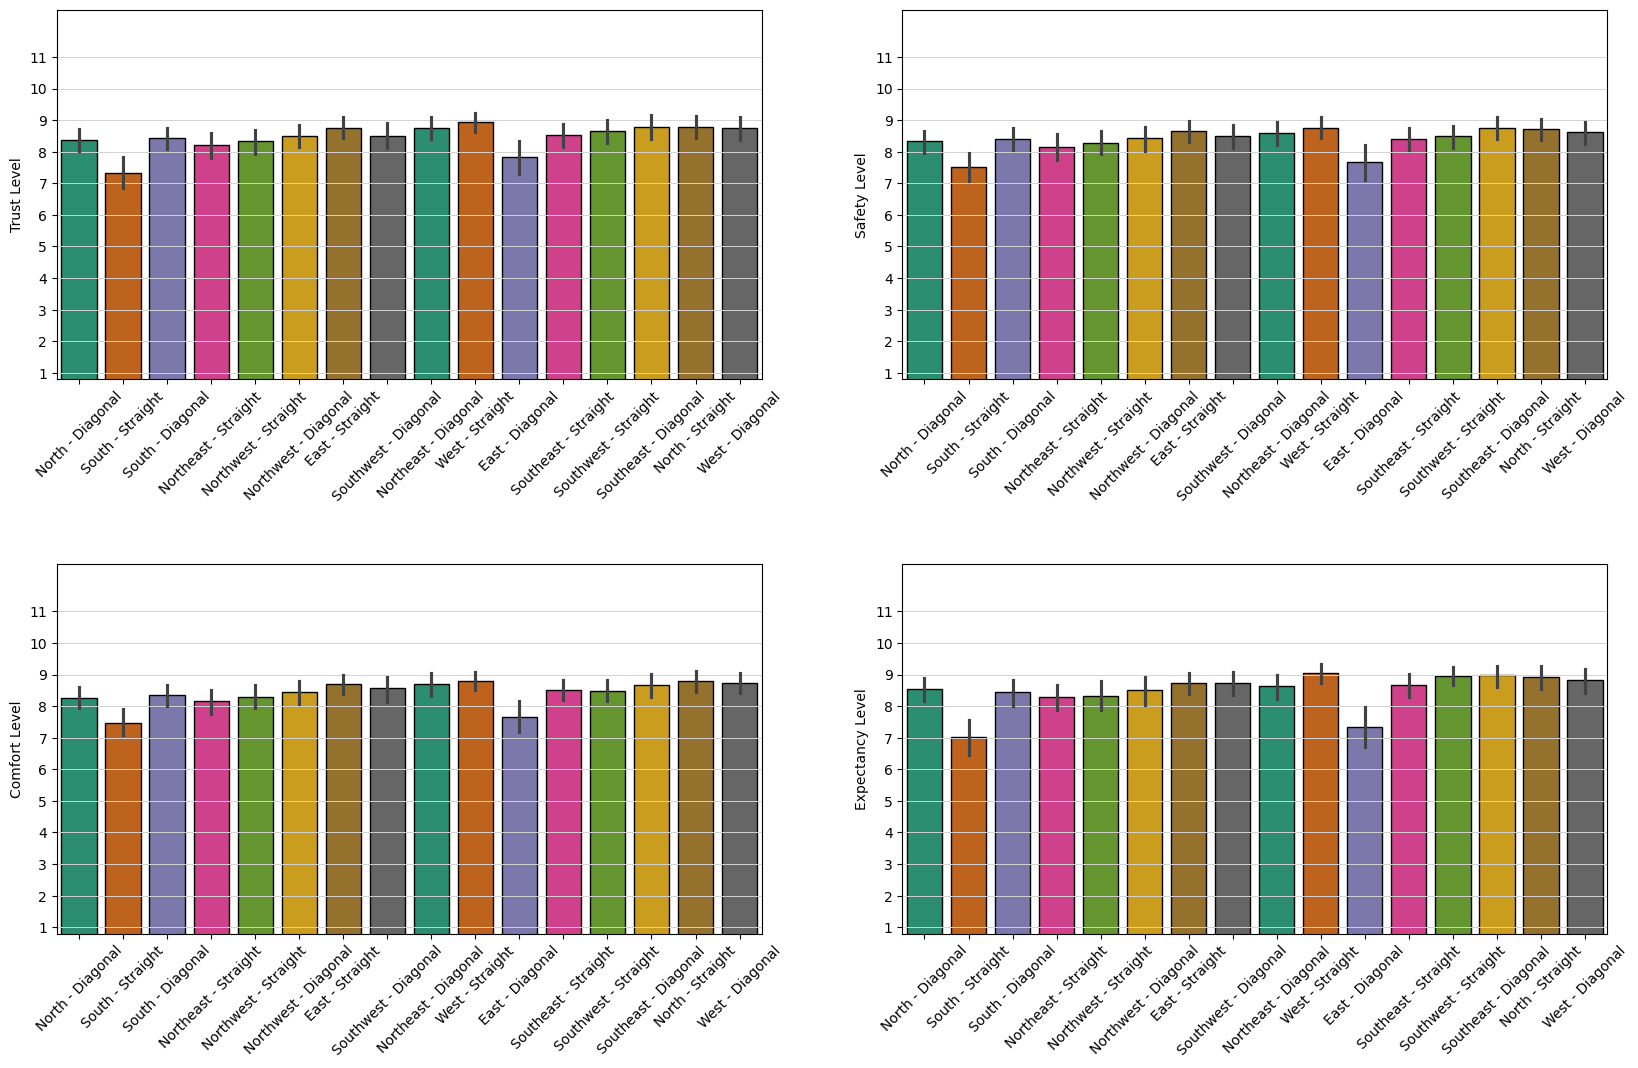

In [273]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set color palette
palette = sns.color_palette('Dark2', n_colors=model_data['AGV_User_Combination'].nunique())

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# Specify the order of the x values
custom_order = ['North - Diagonal', 'South - Straight', 'South - Diagonal',
                'Northeast - Straight', 'Northwest - Straight',
                'Northwest - Diagonal', 'East - Straight', 'Southwest - Diagonal',
                'Northeast - Diagonal', 'West - Straight', 'East - Diagonal',
                'Southeast - Straight', 'Southwest - Straight',
                'Southeast - Diagonal', 'North - Straight', 'West - Diagonal']

# Bar plot for Trust Level
sns.barplot(ax=axes[0, 0],
            x='AGV_User_Combination', y='Trust', 
            data=model_data, palette=palette, order=custom_order,
            edgecolor='black')  # Change bars' edge color to black
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Trust Level")
axes[0, 0].set_ylim(0.8, 12.5)
axes[0, 0].set_yticks(range(1, 12))
axes[0, 0].tick_params(axis='x', rotation=45)  # Rotate x-axis labels
axes[0, 0].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

# Bar plot for Safety Level
sns.barplot(ax=axes[0, 1],
            x='AGV_User_Combination', y='Safe', 
            data=model_data, palette=palette, order=custom_order,
            edgecolor='black')
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Safety Level")
axes[0, 1].set_ylim(0.8, 12.5)
axes[0, 1].set_yticks(range(1, 12))
axes[0, 1].tick_params(axis='x', rotation=45)  # Rotate x-axis labels
axes[0, 1].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

# Bar plot for Comfort Level
sns.barplot(ax=axes[1, 0],
            x='AGV_User_Combination', y='Comfort', 
            data=model_data, palette=palette, order=custom_order,
            edgecolor='black')
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Comfort Level")
axes[1, 0].set_ylim(0.8, 12.5)
axes[1, 0].set_yticks(range(1, 12))
axes[1, 0].tick_params(axis='x', rotation=45)  # Rotate x-axis labels
axes[1, 0].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

# Bar plot for Expectancy Level
sns.barplot(ax=axes[1, 1],
            x='AGV_User_Combination', y='Expect', 
            data=model_data, palette=palette, order=custom_order,
            edgecolor='black')
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Expectancy Level")
axes[1, 1].set_ylim(0.8, 12.5)
axes[1, 1].set_yticks(range(1, 12))
axes[1, 1].tick_params(axis='x', rotation=45)  # Rotate x-axis labels
axes[1, 1].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

# Creating a single legend for the whole plot
handles, labels = axes[0, 0].get_legend_handles_labels()
# fig.legend(handles, labels, loc='upper right', title='Interaction Type', bbox_to_anchor=(1.07, 0.405))

# Removing the legends, because we wanted the first one to only save it for the whole plot
for ax in axes.flat:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

plt.subplots_adjust(wspace=0.2, hspace=0.5)

# Define the filename with timestamp
filename = f'barplots_of_four_independent_variables_based_on_AGV_User_Combination.png'

full_path = os.path.join(box_path + save_dir, filename)

# Save the plots in the specified directory
# plt.savefig(full_path, dpi = 300)

plt.show()

### Calculating Trust before

In [275]:
high_first_low_last = ['002', '004', '006', '008', '010', '012', '014', '016', '020', 
                       '022', '027', '029', '031', '033', '035', '037', '039', '041', 
                       '043', '045']

low_first_high_last = ['001', '003', '007', '009', '011', '013', '015', '017', '019', 
                       '021', '024', '026', '028', '030', '032', '034', '036', '038', 
                       '040', '042', '044', '046']

#model_data['Trust_before'] = np.nan

grouped_for_trust_before = model_data.groupby('PID')

for pid, group in grouped_for_trust_before:
    #print('In the first loop')
    group_high = group[group['DRate'] == 'High']
    group_low = group[group['DRate'] == 'Low']

    #checking to which group PID belongs to
    if pid in high_first_low_last:
        if not group_high.empty:
            model_data.loc[group_high.index, 'Trust_before'] = group_high['Trust'].shift(1)
            #print('In the first if')
            
        if not group_low.empty:
            model_data.loc[group_low.index[0], 'Trust_before'] = group_low['Trust1'].iloc[0]/10
            model_data.loc[group_low.index[1:], 'Trust_before'] = group_low['Trust'].shift(1)

    elif pid in low_first_high_last:
        if not group_low.empty:
            model_data.loc[group_low.index, 'Trust_before'] = group_low['Trust'].shift(1)

        if not group_high.empty:
            model_data.loc[group_high.index[0], 'Trust_before'] = group_high['Trust1'].iloc[0]/10
            model_data.loc[group_high.index[1:], 'Trust_before'] = group_high['Trust'].shift(1)

model_data.head()

,PID,DRate,date,hr,min,s,AGVname,StartTime,EndTime,GazeDuration,...,Trust_before,Cross_First_Flag,User_Relative_Speed,AGV_Relative_Speed,Frechet_Distance_3,Frechet_Distance_5,Frechet_Distance_7,Frechet_Distance_10,Cross_First,Interaction No
0,001,High,2024-5-3,14,28,53,1,1900-01-01 15:02:48,1900-01-01 15:03:38,219,...,4.9,True,74.6,100,730,1.19e+03,1.53e+03,1.77e+03,N\A,1
1,001,High,2024-5-3,14,28,53,2,1900-01-01 15:03:47,1900-01-01 15:04:29,0,...,10,True,47.9,232,14.6,97,108,247,N\A,2
2,001,High,2024-5-3,14,28,53,3,1900-01-01 15:04:37,1900-01-01 15:05:34,268,...,10,True,63.1,120,282,483,821,1.07e+03,User,3
3,001,High,2024-5-3,14,28,53,4,1900-01-01 15:05:46,1900-01-01 15:06:37,779,...,10,True,43.6,263,421,544,578,611,User,4
4,001,High,2024-5-3,14,28,53,5,1900-01-01 15:06:41,1900-01-01 15:07:44,868,...,7,True,93.7,91.6,487,853,1.23e+03,1.72e+03,N\A,5


In [276]:
North_Diagonal = model_data.loc[model_data['AGV_User_Combination'] == 'North - Diagonal', 'Trust_before'].values
print(North_Diagonal)

[10.  5.  7. 10.  7.  8.  8. 10.  8.  8. 10.  6.  7. 10.  7.  3.  6.  8.
  9.  5.  9. 10.  5.  5.  8.  9. 10.  8. 10. 10.  5.  7. 10.  8.  7.  9.
 10.  9.  3.  7. 10.  2.  7.  7.  8.  8.  7.  5.  8.  7.  7.  9.  9.  7.
  8.  6.  3.  6. 10.  9.  7.  7. 10.  8.  3.  5.  5.  4.  1.  7. 10.  7.
  9. 10.  6.  4.  3.  6. 10.  8.  9.]


[10.  5.  7. 10.  7.  8.  8. 10.  8.  8. 10.  6.  7. 10.  7.  3.  6.  8.
  9.  5.  9. 10.  5.  5.  8.  9. 10.  8. 10. 10.  5.  7. 10.  8.  7.  9.
 10.  9.  3.  7. 10.  2.  7.  7.  8.  8.  7.  5.  8.  7.  7.  9.  9.  7.
  8.  6.  3.  6. 10.  9.  7.  7. 10.  8.  3.  5.  5.  4.  1.  7. 10.  7.
  9. 10.  6.  4.  3.  6. 10.  8.  9.]


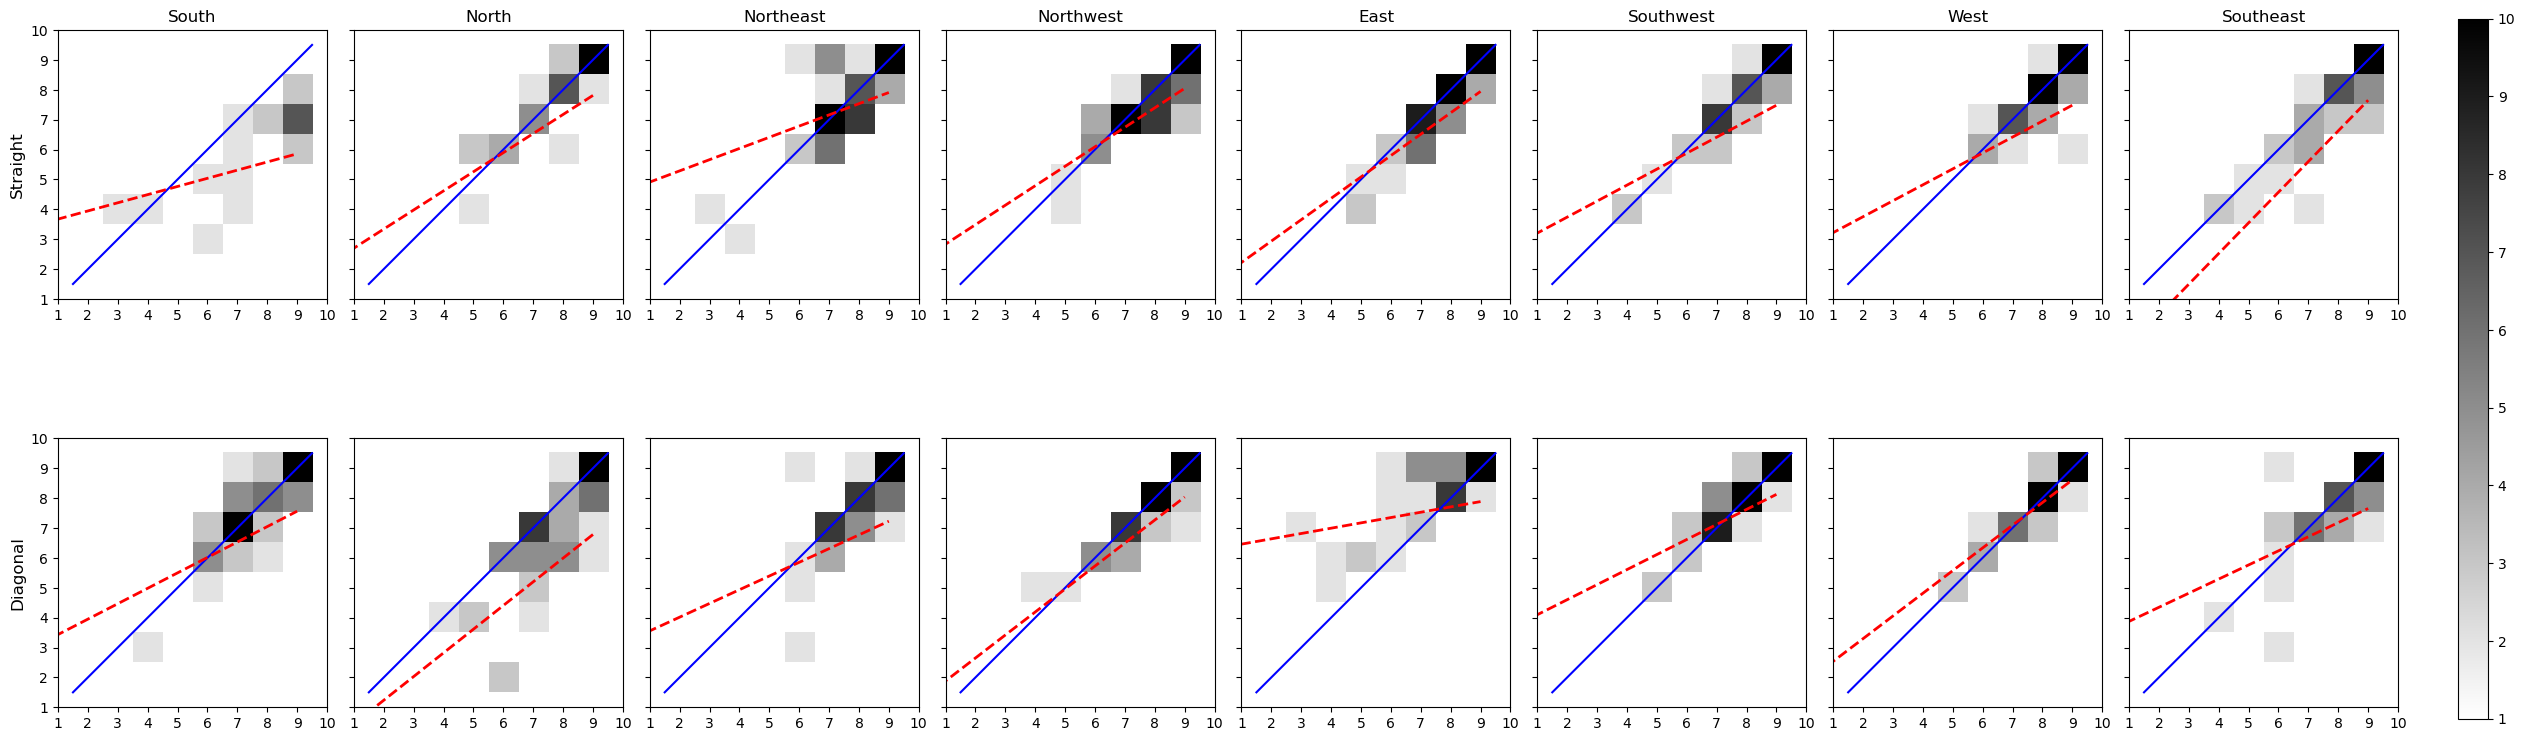

In [277]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import Normalize

# We only want the records that their 'Trust_before' is not Nan
model_data = model_data[model_data['Trust_before'].notna()]
print(model_data.loc[model_data['AGV_User_Combination'] == 'North - Diagonal', 'Trust_before'].values)

# Extract unique AGVname and User Trajectory values
unique_agv = model_data['AGV_Approaching'].unique()
unique_trajectory = model_data['User_Trajectory'].unique()

# Intializing the transition matrix 
transition_matrices = {agv: {traj: np.zeros((10, 10)) for traj in unique_trajectory} for agv in unique_agv}

for idx, row in model_data.iterrows():
    agv = row['AGV_Approaching']
    traj = row['User_Trajectory']
    trust_before = int(row['Trust_before']) - 1
    trust_after = int(row['Trust']) - 1

    transition_matrices[agv][traj][trust_before, trust_after] += 1

fig, axes = plt.subplots(len(unique_trajectory), len(unique_agv), figsize=(30, 28))

cbar_ax = fig.add_axes([0.9, 0.05, 0.01, 0.25])

for i, traj in enumerate(unique_trajectory):
    for j, agv in enumerate(unique_agv):
        ax = axes[i, j]

        matrix_size = transition_matrices[agv][traj].shape[0]
        ax.plot([1.5, matrix_size - 0.5], [1.5, matrix_size - 0.5], color='blue', linestyle='-', linewidth=1.5)
        #ax.grid(True, which='both', axis='both', linestyle='-', color='gray', alpha=0.5)

        # Linear Regression Line
        x = np.arange(matrix_size)
        y = np.arange(matrix_size)
        X, Y = np.meshgrid(x, y)
        X_flat = X.flatten()
        Y_flat = Y.flatten()
        values = transition_matrices[agv][traj].flatten()

        # Filter out zero values for fitting
        mask = values > 0
        X_flat_filtered = X_flat[mask]
        Y_flat_filtered = Y_flat[mask]
        values_filtered = values[mask]

        if len(X_flat_filtered) > 1:
            coeffs = np.polyfit(X_flat_filtered, Y_flat_filtered, 1)
            poly = np.poly1d(coeffs)

            # Calculate regression line
            y_reg = poly(x)
            ax.plot(x, y_reg, color='red', linestyle='--', linewidth=2)
            
        img = ax.matshow(transition_matrices[agv][traj], cmap = 'binary', norm=Normalize(vmin=1, vmax=10))

        # Flip y and x axis
        ax.invert_yaxis()
        ax.xaxis.set_ticks_position('bottom')
        #ax.set_xticks(range(1, 10.1))
        ax.set_xlim(1, 10)
        #ax.set_xticklabels('12345678910')

        # Hide x-axis
        if i != len(unique_trajectory) - 1:
            ax.set_xlim(1, 9)
            #ax.set_xticklabels([])
            #ax.set_xticks(range(1, 10))
                     

        # Hide y-axis
        if j != 0:
            ax.set_ylim(1, 10)
            ax.set_yticklabels([])
            #ax.set_yticks(range(1, 10))       

        if i == 0:
            ax.set_title(agv, fontsize = 12)
            ax.set_xlim(1, 10)
        if j == 0:
            ax.set_ylabel(traj, fontsize = 12)
            ax.set_ylim(1, 10)


fig.colorbar(img, cax=cbar_ax, shrink=1, pad=0.2)

plt.subplots_adjust(left=0.1, right=0.88, top = 0.3, bottom=0.05, wspace=0.1, hspace=0.4)

# generate a timestamp for the uniqueness 
timestamp = datetime.now().strftime("%Y%m%d%H%M%S")

# Define the filename with timestamp
filename = f'transition_matrices.png'

full_path = os.path.join(box_path + save_dir, filename)

# Save the plots in the specified directory
# plt.savefig(full_path, dpi = 300)

# Display the plot
# plt.tight_layout(rect=[0,0,1,1])
plt.show()

In [278]:
model_data.head()

,PID,DRate,date,hr,min,s,AGVname,StartTime,EndTime,GazeDuration,...,Trust_before,Cross_First_Flag,User_Relative_Speed,AGV_Relative_Speed,Frechet_Distance_3,Frechet_Distance_5,Frechet_Distance_7,Frechet_Distance_10,Cross_First,Interaction No
0,001,High,2024-5-3,14,28,53,1,1900-01-01 15:02:48,1900-01-01 15:03:38,219,...,4.9,True,74.6,100,730,1.19e+03,1.53e+03,1.77e+03,N\A,1
1,001,High,2024-5-3,14,28,53,2,1900-01-01 15:03:47,1900-01-01 15:04:29,0,...,10,True,47.9,232,14.6,97,108,247,N\A,2
2,001,High,2024-5-3,14,28,53,3,1900-01-01 15:04:37,1900-01-01 15:05:34,268,...,10,True,63.1,120,282,483,821,1.07e+03,User,3
3,001,High,2024-5-3,14,28,53,4,1900-01-01 15:05:46,1900-01-01 15:06:37,779,...,10,True,43.6,263,421,544,578,611,User,4
4,001,High,2024-5-3,14,28,53,5,1900-01-01 15:06:41,1900-01-01 15:07:44,868,...,7,True,93.7,91.6,487,853,1.23e+03,1.72e+03,N\A,5


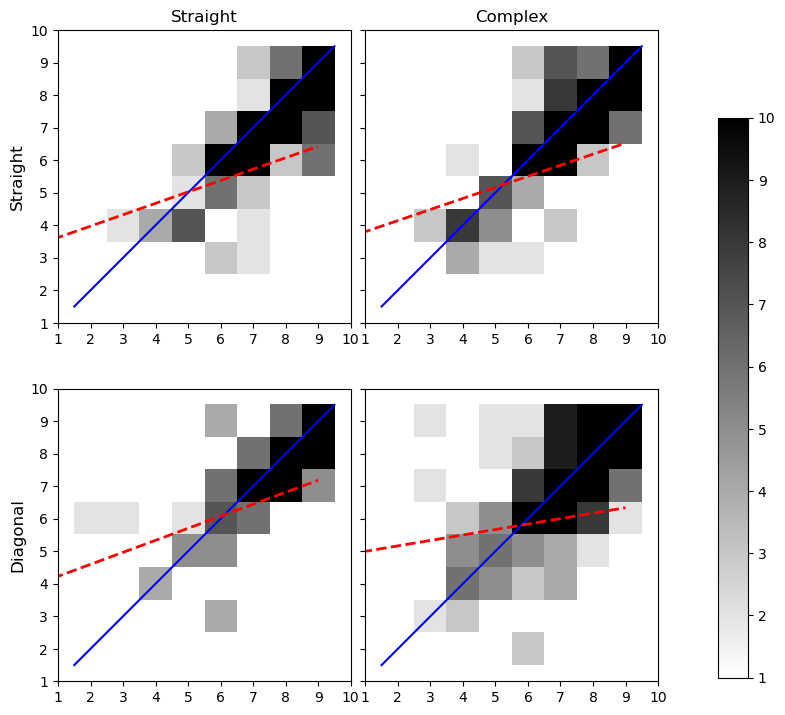

In [280]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import Normalize

# We only want the records that their 'Trust_before' is not Nan
model_data = model_data[model_data['Trust_before'].notna()]

# Extract unique AGVname and User Trajectory values
unique_agv = model_data['AGV_Path_Complexity'].unique()
unique_trajectory = model_data['User_Trajectory'].unique()

# Intializing the transition matrix 
transition_matrices = {agv: {traj: np.zeros((10, 10)) for traj in unique_trajectory} for agv in unique_agv}

for idx, row in model_data.iterrows():
    agv = row['AGV_Path_Complexity']
    traj = row['User_Trajectory']
    trust_before = int(row['Trust_before']) - 1
    trust_after = int(row['Trust']) - 1

    transition_matrices[agv][traj][trust_before, trust_after] += 1

fig, axes = plt.subplots(len(unique_trajectory), len(unique_agv), figsize=(30, 28))

cbar_ax = fig.add_axes([0.32, 0.06, 0.01, 0.20])

for i, traj in enumerate(unique_trajectory):
    for j, agv in enumerate(unique_agv):
        ax = axes[i, j]

        matrix_size = transition_matrices[agv][traj].shape[0]
        ax.plot([1.5, matrix_size - 0.5], [1.5, matrix_size - 0.5], color='blue', linestyle='-', linewidth=1.5)
        #ax.grid(True, which='both', axis='both', linestyle='-', color='gray', alpha=0.5)

        # Linear Regression Line
        x = np.arange(matrix_size)
        y = np.arange(matrix_size)
        X, Y = np.meshgrid(x, y)
        X_flat = X.flatten()
        Y_flat = Y.flatten()
        values = transition_matrices[agv][traj].flatten()

        # Filter out zero values for fitting
        mask = values > 0
        X_flat_filtered = X_flat[mask]
        Y_flat_filtered = Y_flat[mask]
        values_filtered = values[mask]

        if len(X_flat_filtered) > 1:
            coeffs = np.polyfit(X_flat_filtered, Y_flat_filtered, 1)
            poly = np.poly1d(coeffs)

            # Calculate regression line
            y_reg = poly(x)
            ax.plot(x, y_reg, color='red', linestyle='--', linewidth=2)
            
        img = ax.matshow(transition_matrices[agv][traj], cmap = 'binary', norm=Normalize(vmin=1, vmax=10))

        # Flip y and x axis
        ax.invert_yaxis()
        ax.xaxis.set_ticks_position('bottom')
        #ax.set_xticks(range(1, 10.1))
        ax.set_xlim(1, 10)
        #ax.set_xticklabels('12345678910')

        # Hide x-axis
        if i != len(unique_trajectory) - 1:
            ax.set_xlim(1, 9)
            #ax.set_xticklabels([])
            #ax.set_xticks(range(1, 10))
                     

        # Hide y-axis
        if j != 0:
            ax.set_ylim(1, 10)
            ax.set_yticklabels([])
            #ax.set_yticks(range(1, 10))       

        if i == 0:
            ax.set_title(agv, fontsize = 12)
            ax.set_xlim(1, 10)
        if j == 0:
            ax.set_ylabel(traj, fontsize = 12)
            ax.set_ylim(1, 10)


fig.colorbar(img, cax=cbar_ax, shrink=1, pad=0.2)

plt.subplots_adjust(left=0.1, right=0.3, top = 0.3, bottom=0.05, wspace=0.05, hspace=0.05)

# generate a timestamp for the uniqueness 
timestamp = datetime.now().strftime("%Y%m%d%H%M%S")

# Define the filename with timestamp
filename = f'transition_matrices_with_agv_path_complexity_{timestamp}.png'
# plt.savefig(save_dir + filename, bbox_inches = 'tight', pad_inches=0.1)

# Display the plot
# plt.tight_layout(rect=[0,0,1,1])
plt.show()

## Inferential Statistics

### Correlation Matrix

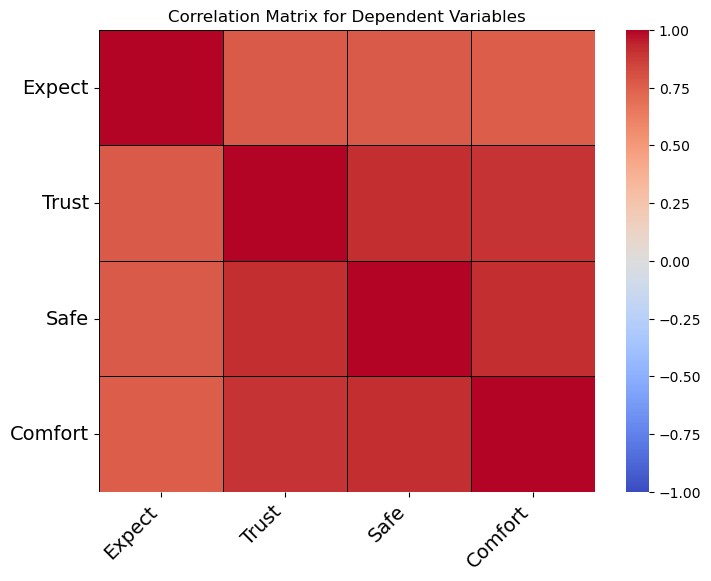

,Expect,Trust,Safe,Comfort
Expect,1,0.767,0.773,0.758
Trust,0.767,1,0.922,0.904
Safe,0.773,0.922,1,0.92
Comfort,0.758,0.904,0.92,1


In [285]:
# Select the features to include the correlation matrix
features = ['Expect','Trust', 'Safe', 'Comfort']

# Create the correlation matrix
correlation_matrix = model_data[features].corr()



# Visualize the correlation matrix
plt.figure(figsize = (8, 6))
heatmap = sns.heatmap(correlation_matrix, cmap = 'coolwarm', annot=False, annot_kws = {'size': 20, 'color': 'b'}, fmt = '.2', vmin = -1, vmax = 1, linecolor = 'black', linewidth = '0.5')

# Adjust tick labels sizes
heatmap.tick_params(axis = 'x', labelsize = 14)
heatmap.tick_params(axis = 'y', labelsize = 14)
heatmap.set_xticklabels(heatmap.get_xticklabels(), rotation = 45, horizontalalignment = 'right')
heatmap.set_yticklabels(heatmap.get_yticklabels(), rotation = 0, horizontalalignment = 'right')
plt.title('Correlation Matrix for Dependent Variables')

# Define the filename with timestamp
filename = 'Correlation Matrix for Dependent Variables'
full_path = os.path.join(box_path + save_dir, filename)

# Save the plots in the specified directory
# plt.savefig(full_path, dpi = 300)

plt.show()

correlation_matrix.round(3)

### Summary Statistics

In [289]:
pd.options.display.float_format = '{:.3g}'.format

summary_stats = model_data.groupby(['DRate', 'AGVname']).agg({
    'Trust': ['min', 'median','mean', 'max','std'],
    'Safe': ['min', 'median','mean', 'max','std'],
    'Comfort': ['min', 'median','mean', 'max','std'],
    'Expect': ['min', 'median','mean', 'max','std'],
})

summary_stats = summary_stats.applymap(lambda x: '{:.3g}'.format(x))

summary_stats

C:\Users\HIALAB\AppData\Local\Temp\ipykernel_79320\1821703008.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  summary_stats = summary_stats.applymap(lambda x: '{:.3g}'.format(x))


Trust                        Safe                         \
                min median  mean max   std  min median  mean max   std   
DRate AGVname                                                            
High  1           4      8  7.73  10     2    4      8  7.95  10   1.7   
      2           4      8  8.32  10  1.46    4      9  8.22  10   1.7   
      3           5      9  8.48  10   1.4    4      9  8.38  10  1.55   
      4           3      8  8.17  10  1.78    3      9  8.19  10  1.81   
      5           1    8.5  8.02  10   2.1    2    8.5  7.95  10  1.92   
      6           4      9  8.38  10  1.64    4      9  8.33  10  1.76   
      7           6      9  8.79  10  1.24    6      9  8.62  10  1.27   
      8           3      9  8.52  10  1.81    4      9  8.48  10  1.69   
      9           4      9  8.74  10  1.48    4      9  8.52  10  1.64   
      10          4    9.5  8.93  10  1.49    4      9  8.79  10  1.54   
      11          1      9  7.93  10  2.49    1      8  7.69  10  2.59   
      12          4      9  8.55  10  1.66    4      9  8.52  10  1.64   
      13          5      9  8.72  10  1.48    6      9  8.62  10  1.44   
      14          3     10  8.75  10  1.72    3      9  8.57  10  1.96   
      15          3    9.5  8.85  10  1.63    5      9  8.75  10  1.41   
      16          5      9  8.79  10  1.51    6      9  8.64  10  1.36   
Low   1           5    9.5   8.8  10  1.51    4      9   8.6  10   1.6   
      2           4      9  8.45  10  1.81    4      9  8.45  10  1.65   
      3           4    8.5   8.4  10  1.68    4      9   8.4  10  1.62   
      4           1      8  8.26  10  1.85    1      8   8.1  10  1.95   
      5           5      9  8.64  10  1.43    5      9  8.62  10   1.5   
      6           3      9  8.64  10  1.69    3      9  8.52  10  1.66   
      7           1      9  8.74  10  1.81    1      9  8.69  10  1.83   
      8           4      9   8.5  10  1.77    3      9  8.52  10  1.92   
      9           3     10  8.76  10  1.75    1      9  8.67  10  1.87   
      10          5    9.5  8.93  10  1.37    4      9  8.74  10  1.55   
      11          1    8.5  7.76  10  2.29    1      8  7.67  10   2.4   
      12          5      9  8.49  10  1.72    4      9  8.29  10  1.81   
      13          4      9  8.59  10  1.79    3      9  8.37  10  1.83   
      14          4     10  8.85  10  1.57    5      9  8.92  10  1.31   
      15          3    9.5  8.72  10  1.68    3      9  8.67  10  1.66   
      16          2      9   8.7  10  1.76    2      9   8.6  10  1.82   

              Comfort                        Expect                         
                  min median  mean max   std    min median  mean max   std  
DRate AGVname                                                               
High  1             4      8  7.86  10  1.78      2      8  6.82  10  2.89  
      2             5      8  8.15  10  1.61      4      9  8.37  10   1.7  
      3             5      9   8.4  10   1.4      1      9  8.31  10  1.97  
      4             3      8  8.17  10   1.7      3      9  8.19  10  1.89  
      5             2      8  7.98  10  2.03      1      9   7.9  10   2.5  
      6             3      9  8.38  10  1.82      2      9   8.4  10  2.04  
      7             6      9  8.76  10  1.14      5      9  8.67  10  1.49  
      8             2      9  8.62  10  1.67      4      9  8.74  10  1.59  
      9             3      9  8.62  10  1.64      4      9  8.57  10  1.52  
      10            4      9  8.76  10  1.45      5     10   9.1  10  1.38  
      11            1      8  7.74  10  2.47      1      9  7.43  10  3.06  
      12            5      9  8.62  10  1.43      4      9  8.79  10  1.54  
      13            6      9  8.68  10  1.42      4     10  9.07  10  1.38  
      14            3      9  8.53  10  1.85      4     10   8.9  10  1.61  
      15            4      9  8.85  10  1.35      5     10  9.15  10  1.25  
      16            5      9  8.76  1

In [290]:
summary_stats.to_csv('summary_statistics_for_16_participants.csv', index = True)

### ANOVA, using statsmodels library

C:\Users\HIALAB\AppData\Local\Temp\ipykernel_79320\1975209714.py:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted_anova_table = anova_table.applymap(lambda x: f"{x:.4g}" if isinstance(x, (int, float)) else x)


                                         df sum_sq mean_sq       F    PR(>F)
DRate                                     1  1.467   1.467  0.4972    0.4809
AGV_Approaching                           7  33.09   4.728   1.602    0.1306
User_Trajectory                           1  1.401   1.401  0.4749    0.4908
DRate:AGV_Approaching                     7  10.73   1.532  0.5194    0.8204
DRate:User_Trajectory                     1  1.088   1.088  0.3686    0.5439
User_Trajectory:AGV_Approaching           7  60.24   8.606   2.917  0.0050**
DRate:User_Trajectory:AGV_Approaching     7  10.72   1.532  0.5191    0.8206
Residual                               1248   3682    2.95     nan       nan


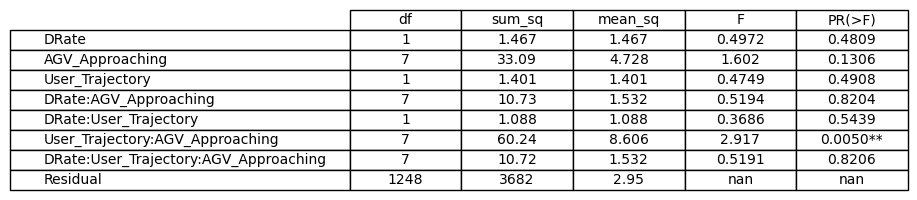

In [298]:
# Fit the model
model = smf.ols('Trust ~ DRate + AGV_Approaching + User_Trajectory + DRate:AGV_Approaching + DRate:User_Trajectory + User_Trajectory:AGV_Approaching + DRate:User_Trajectory:AGV_Approaching'
                , data=model_data).fit()

#Perform ANOVA
anova_table = sm.stats.anova_lm(model, type=2)

def format_p_value(p):
    return f"{p:.4f}**" if p<0.05 else f"{p:.4f}"

# Apply the function to the 'PR(>F)' column
anova_table['PR(>F)'] = anova_table['PR(>F)'].apply(format_p_value)

formatted_anova_table = anova_table.applymap(lambda x: f"{x:.4g}" if isinstance(x, (int, float)) else x)

print(formatted_anova_table)

fig, ax = plt.subplots(figsize = (6, 2))

# Hide axes
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
ax.set_frame_on(False)

# Render Table
table = ax.table(cellText = formatted_anova_table.values, colLabels = formatted_anova_table.columns, rowLabels=formatted_anova_table.index, cellLoc='center', loc='center')

# Adjust table font size and scale
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

# Define the filename with timestamp
filename = 'Trust Anova Table'
full_path = os.path.join(box_path + save_dir, filename)  
plt.savefig(full_path, dpi=300, bbox_inches = 'tight', pad_inches=0.1)

plt.show()

In [ ]:
# Fit the model
model = smf.ols('Safe ~ DRate + AGV_Approaching + User_Trajectory + DRate:AGV_Approaching + DRate:User_Trajectory + User_Trajectory:AGV_Approaching + DRate:User_Trajectory:AGV_Approaching', data=model_data).fit()

#Perform ANOVA
anova_table = sm.stats.anova_lm(model, type=2)

def format_p_value(p):
    return f"{p:.3f}**" if p<0.05 else f"{p:.3f}"

# Apply the function to the 'PR(>F)' column
anova_table['PR(>F)'] = anova_table['PR(>F)'].apply(format_p_value)

formatted_anova_table = anova_table.applymap(lambda x: f"{x:.3g}" if isinstance(x, (int, float)) else x)

print(formatted_anova_table)

fig, ax = plt.subplots(figsize = (6, 2))

# Hide axes
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
ax.set_frame_on(False)

# Render Table
table = ax.table(cellText = formatted_anova_table.values, colLabels = formatted_anova_table.columns, rowLabels=formatted_anova_table.index, cellLoc='center', loc='center')

# Adjust table font size and scale
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

# Define the filename with timestamp
filename = 'Safety Anova Table'
# plt.savefig(save_dir + filename, bbox_inches = 'tight', pad_inches=0.1)

plt.show()

                                             df    sum_sq   mean_sq         F  \
DRate                                         1     0.474     0.474     0.164   
AGV_Approaching                               7      37.4      5.34      1.85   
User_Trajectory                               1      2.03      2.03     0.702   
DRate:AGV_Approaching                         7      9.64      1.38     0.476   
DRate:User_Trajectory                         1  0.000193  0.000193  6.67e-05   
User_Trajectory:AGV_Approaching               7      70.4      10.1      3.47   
DRate:User_Trajectory:AGV_Approaching         7      11.7      1.68     0.579   
Residual                               1.25e+03  3.61e+03       2.9       nan   

                                        PR(>F)  
DRate                                    0.686  
AGV_Approaching                          0.075  
User_Trajectory                          0.402  
DRate:AGV_Approaching                    0.853  
DRate:User_Trajectory    

C:\Users\HIALAB\AppData\Local\Temp\ipykernel_79320\3538975794.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted_anova_table = anova_table.applymap(lambda x: f"{x:.3g}" if isinstance(x, (int, float)) else x)


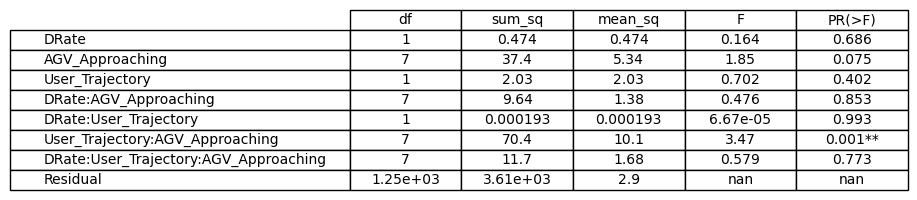

In [116]:
# Fit the model
model = smf.ols('Comfort ~ DRate + AGV_Approaching + User_Trajectory + DRate:AGV_Approaching + DRate:User_Trajectory + User_Trajectory:AGV_Approaching + DRate:User_Trajectory:AGV_Approaching', data=model_data).fit()

#Perform ANOVA
anova_table = sm.stats.anova_lm(model, type=2)

def format_p_value(p):
    return f"{p:.3f}**" if p<0.05 else f"{p:.3f}"

# Apply the function to the 'PR(>F)' column
anova_table['PR(>F)'] = anova_table['PR(>F)'].apply(format_p_value)

formatted_anova_table = anova_table.applymap(lambda x: f"{x:.3g}" if isinstance(x, (int, float)) else x)

print(formatted_anova_table)

fig, ax = plt.subplots(figsize = (6, 2))

# Hide axes
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
ax.set_frame_on(False)

# Render Table
table = ax.table(cellText = formatted_anova_table.values, colLabels = formatted_anova_table.columns, rowLabels=formatted_anova_table.index, cellLoc='center', loc='center')

# Adjust table font size and scale
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

# Define the filename with timestamp
filename = 'Comfort Anova Table'
# plt.savefig(save_dir + filename, bbox_inches = 'tight', pad_inches=0.1)

plt.show()

                                             df    sum_sq mean_sq      F  \
DRate                                         1      3.78    3.78   1.06   
AGV_Approaching                               7       121    17.2   4.83   
User_Trajectory                               1       3.7     3.7   1.04   
DRate:AGV_Approaching                         7      29.5    4.22   1.18   
DRate:User_Trajectory                         1     0.732   0.732  0.206   
User_Trajectory:AGV_Approaching               7       118    16.8   4.73   
DRate:User_Trajectory:AGV_Approaching         7      27.7    3.96   1.11   
Residual                               1.25e+03  4.44e+03    3.56    nan   

                                        PR(>F)  
DRate                                    0.303  
AGV_Approaching                        0.000**  
User_Trajectory                          0.308  
DRate:AGV_Approaching                    0.309  
DRate:User_Trajectory                    0.650  
User_Trajectory:AGV_A

C:\Users\HIALAB\AppData\Local\Temp\ipykernel_79320\873201805.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted_anova_table = anova_table.applymap(lambda x: f"{x:.3g}" if isinstance(x, (int, float)) else x)


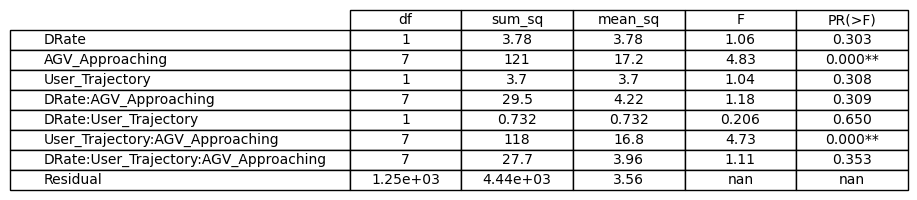

In [118]:
# Fit the model
model = smf.ols('Expect ~ DRate + AGV_Approaching + User_Trajectory + DRate:AGV_Approaching + DRate:User_Trajectory + User_Trajectory:AGV_Approaching + DRate:User_Trajectory:AGV_Approaching', data=model_data).fit()

#Perform ANOVA
anova_table = sm.stats.anova_lm(model, type=2)

def format_p_value(p):
    return f"{p:.3f}**" if p<0.05 else f"{p:.3f}"

# Apply the function to the 'PR(>F)' column
anova_table['PR(>F)'] = anova_table['PR(>F)'].apply(format_p_value)

formatted_anova_table = anova_table.applymap(lambda x: f"{x:.3g}" if isinstance(x, (int, float)) else x)

print(formatted_anova_table)

fig, ax = plt.subplots(figsize = (6, 2))

# Hide axes
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
ax.set_frame_on(False)

# Render Table
table = ax.table(cellText = formatted_anova_table.values, colLabels = formatted_anova_table.columns, rowLabels=formatted_anova_table.index, cellLoc='center', loc='center')

# Adjust table font size and scale
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

# Define the filename with timestamp
filename = 'Expectancy Anova Table'
# plt.savefig(save_dir + filename, bbox_inches = 'tight', pad_inches=0.1)

plt.show()

### ANOVA, using pingouin library

In [121]:
anova_table = pg.anova(dv = 'Trust', between = ['DRate', 'AGV_Approaching', 'User_Trajectory'], data=model_data, detailed=True)

formatted_anova_table = anova_table.applymap(lambda x: f'{x:.2f}' if isinstance(x, (int, float)) else x)

formatted_anova_table

C:\Users\HIALAB\AppData\Local\Temp\ipykernel_79320\1504950384.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted_anova_table = anova_table.applymap(lambda x: f'{x:.2f}' if isinstance(x, (int, float)) else x)


,Source,SS,DF,MS,F,p-unc,np2
0,DRate,1.52,1.00,1.52,0.52,0.47,0.00
1,AGV_Approaching,32.53,7.00,4.65,1.58,0.14,0.01
2,User_Trajectory,1.43,1.00,1.43,0.48,0.49,0.00
3,DRate * AGV_Approaching,10.90,7.00,1.56,0.53,0.81,0.00
4,DRate * User_Trajectory,1.10,1.00,1.10,0.37,0.54,0.00
5,AGV_Approaching * User_Trajectory,60.24,7.00,8.61,2.92,0.00,0.02
6,DRate * AGV_Approaching * User_Trajectory,10.72,7.00,1.53,0.52,0.82,0.00
7,Residual,3681.88,1248.00,2.95,nan,nan,nan


In [123]:
anova_table = pg.anova(dv = 'Safe', between = ['DRate', 'AGV_Approaching', 'User_Trajectory'], data=model_data, detailed=True)

formatted_anova_table = anova_table.applymap(lambda x: f'{x:.2f}' if isinstance(x, (int, float)) else x)

formatted_anova_table

C:\Users\HIALAB\AppData\Local\Temp\ipykernel_79320\2396620958.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted_anova_table = anova_table.applymap(lambda x: f'{x:.2f}' if isinstance(x, (int, float)) else x)


,Source,SS,DF,MS,F,p-unc,np2
0,DRate,2.16,1.00,2.16,0.71,0.40,0.00
1,AGV_Approaching,30.37,7.00,4.34,1.43,0.19,0.01
2,User_Trajectory,1.18,1.00,1.18,0.39,0.53,0.00
3,DRate * AGV_Approaching,8.06,7.00,1.15,0.38,0.91,0.00
4,DRate * User_Trajectory,0.23,1.00,0.23,0.08,0.78,0.00
5,AGV_Approaching * User_Trajectory,59.78,7.00,8.54,2.81,0.01,0.02
6,DRate * AGV_Approaching * User_Trajectory,10.87,7.00,1.55,0.51,0.83,0.00
7,Residual,3788.70,1248.00,3.04,nan,nan,nan


In [125]:
anova_table = pg.anova(dv = 'Comfort', between = ['DRate', 'AGV_Approaching', 'User_Trajectory'], data=model_data, detailed=True)

formatted_anova_table = anova_table.applymap(lambda x: f'{x:.2f}' if isinstance(x, (int, float)) else x)

formatted_anova_table

C:\Users\HIALAB\AppData\Local\Temp\ipykernel_79320\205617560.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted_anova_table = anova_table.applymap(lambda x: f'{x:.2f}' if isinstance(x, (int, float)) else x)


,Source,SS,DF,MS,F,p-unc,np2
0,DRate,0.53,1.00,0.53,0.18,0.67,0.00
1,AGV_Approaching,36.77,7.00,5.25,1.81,0.08,0.01
2,User_Trajectory,2.06,1.00,2.06,0.71,0.40,0.00
3,DRate * AGV_Approaching,9.60,7.00,1.37,0.47,0.85,0.00
4,DRate * User_Trajectory,0.00,1.00,0.00,0.00,1.00,0.00
5,AGV_Approaching * User_Trajectory,70.44,7.00,10.06,3.47,0.00,0.02
6,DRate * AGV_Approaching * User_Trajectory,11.75,7.00,1.68,0.58,0.77,0.00
7,Residual,3614.60,1248.00,2.90,nan,nan,nan


In [127]:
anova_table = pg.anova(dv = 'Expect', between = ['DRate', 'AGV_Approaching', 'User_Trajectory'], data=model_data, detailed=True)

formatted_anova_table = anova_table.applymap(lambda x: f'{x:.2f}' if isinstance(x, (int, float)) else x)

formatted_anova_table

C:\Users\HIALAB\AppData\Local\Temp\ipykernel_79320\4193221890.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted_anova_table = anova_table.applymap(lambda x: f'{x:.2f}' if isinstance(x, (int, float)) else x)


,Source,SS,DF,MS,F,p-unc,np2
0,DRate,3.81,1.00,3.81,1.07,0.30,0.00
1,AGV_Approaching,118.57,7.00,16.94,4.76,0.00,0.03
2,User_Trajectory,3.81,1.00,3.81,1.07,0.30,0.00
3,DRate * AGV_Approaching,29.15,7.00,4.16,1.17,0.32,0.01
4,DRate * User_Trajectory,0.67,1.00,0.67,0.19,0.66,0.00
5,AGV_Approaching * User_Trajectory,117.90,7.00,16.84,4.73,0.00,0.03
6,DRate * AGV_Approaching * User_Trajectory,27.72,7.00,3.96,1.11,0.35,0.01
7,Residual,4443.86,1248.00,3.56,nan,nan,nan


## t-test

In [130]:
summary, results = rp.ttest(group1=model_data['Trust'][model_data['DRate'] == 'Low'],
                            group1_name='Low Deceleration Rate', 
                            group2=model_data['Trust'][model_data['DRate'] == 'High'],
                            group2_name='High Deceleration Rate', 
                            equal_variances=True, 
                            paired=False)
summary, results

C:\Users\HIALAB\anaconda3\Lib\site-packages\researchpy\ttest.py:301: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Low Deceleration Rate' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table.iloc[0,0] = group1_name
C:\Users\HIALAB\anaconda3\Lib\site-packages\researchpy\ttest.py:460: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Difference (Low Deceleration Rate - High Deceleration Rate) = ' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table2.iloc[0,0] = f"Difference ({group1_name} - {group2_name}) = "


(                 Variable        N  Mean   SD     SE  95% Conf.  Interval
 0   Low Deceleration Rate      635  8.57 1.74  0.069       8.43       8.7
 1  High Deceleration Rate      645   8.5 1.71 0.0673       8.37      8.63
 2                combined 1.28e+03  8.53 1.72 0.0482       8.44      8.63,
                                   Independent t-test  results
 0  Difference (Low Deceleration Rate - High Decel...   0.0677
 1                              Degrees of freedom =  1.28e+03
 2                                               t =     0.702
 3                           Two side test p value =     0.482
 4                          Difference < 0 p value =     0.759
 5                          Difference > 0 p value =     0.241
 6                                       Cohen's d =    0.0393
 7                                       Hedge's g =    0.0392
 8                                  Glass's delta1 =    0.0389
 9                                Point-Biserial r =    0.0196)

In [132]:
summary, results = rp.ttest(group1=model_data['Expect'][model_data['DRate'] == 'Low'],
                            group1_name='Low Deceleration Rate', 
                            group2=model_data['Expect'][model_data['DRate'] == 'High'],
                            group2_name='High Deceleration Rate', 
                            equal_variances=True, 
                            paired=False)
summary, results

C:\Users\HIALAB\anaconda3\Lib\site-packages\researchpy\ttest.py:301: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Low Deceleration Rate' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table.iloc[0,0] = group1_name
C:\Users\HIALAB\anaconda3\Lib\site-packages\researchpy\ttest.py:460: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Difference (Low Deceleration Rate - High Deceleration Rate) = ' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table2.iloc[0,0] = f"Difference ({group1_name} - {group2_name}) = "


(                 Variable        N  Mean   SD     SE  95% Conf.  Interval
 0   Low Deceleration Rate      635  8.61 1.92 0.0763       8.46      8.76
 1  High Deceleration Rate      645   8.5 1.93 0.0761       8.35      8.65
 2                combined 1.28e+03  8.56 1.93 0.0539       8.45      8.66,
                                   Independent t-test  results
 0  Difference (Low Deceleration Rate - High Decel...    0.109
 1                              Degrees of freedom =  1.28e+03
 2                                               t =      1.01
 3                           Two side test p value =     0.313
 4                          Difference < 0 p value =     0.844
 5                          Difference > 0 p value =     0.157
 6                                       Cohen's d =    0.0564
 7                                       Hedge's g =    0.0564
 8                                  Glass's delta1 =    0.0566
 9                                Point-Biserial r =    0.0282)

## t-test between each pair of DVs

In [135]:
group_t = model_data['Trust']
group_e = model_data['Expect']
group_s = model_data['Safe']
group_c = model_data['Comfort']

In [137]:
t_stat, p_value = ttest_ind(group_t, group_e)

print(f"T-statistics between group_t and group_e: {t_stat:.2f}")
print(f"P-value between group_t and group_e: {p_value:.2f}")

T-statistics between group_t and group_e: -0.35
P-value between group_t and group_e: 0.73


In [139]:
t_stat, p_value = ttest_ind(group_t, group_s)

print(f"T-statistics between group_t and group_s: {t_stat:.2f}")
print(f"P-value between group_t and group_s: {p_value:.2f}")

T-statistics between group_t and group_s: 1.33
P-value between group_t and group_s: 0.18


In [141]:
t_stat, p_value = ttest_ind(group_t, group_c)

print(f"T-statistics between group_t and group_c: {t_stat:.2f}")
print(f"P-value between group_t and group_c: {p_value:.2f}")

T-statistics between group_t and group_c: 1.01
P-value between group_t and group_c: 0.31


In [143]:
t_stat, p_value = ttest_ind(group_e, group_s)

print(f"T-statistics between group_e and group_s: {t_stat:.2f}")
print(f"P-value between group_e and group_s: {p_value:.2f}")

T-statistics between group_e and group_s: 1.60
P-value between group_e and group_s: 0.11


In [145]:
t_stat, p_value = ttest_ind(group_e, group_c)

print(f"T-statistics between group_e and group_c: {t_stat:.2f}")
print(f"P-value between group_e and group_c: {p_value:.2f}")

T-statistics between group_e and group_c: 1.30
P-value between group_e and group_c: 0.19


In [147]:
t_stat, p_value = ttest_ind(group_s, group_c)

print(f"T-statistics between group_s and group_c: {t_stat:.2f}")
print(f"P-value between group_s and group_c: {p_value:.2f}")

T-statistics between group_s and group_c: -0.33
P-value between group_s and group_c: 0.74


## Calculating the Sample Size and Effect Size
Calculating the sample size for minimum detectable effect

In [150]:
trust_data_low = model_data['Trust'][model_data['DRate'] == 'Low']
trust_data_high = model_data['Trust'][model_data['DRate'] == 'High']

# Calculate the mean, std, and size of the samples
mean_low, mean_high = np.mean(trust_data_low), np.mean(trust_data_high)
std_low, std_high = np.std(trust_data_low, ddof=1), np.std(trust_data_high, ddof=1)
len_low, len_high = len(trust_data_low), len(trust_data_high)

# Calculate S
S = sqrt(((len_low -1)*(std_low**2) + (len_high - 1)*(std_high**2))/(len_low + len_high - 2))

# Calculating the effect size based on Cohen's d for a two-sample t-test
d = abs(round((mean_low - mean_high)/S, 2))

print('Effect Size for "Trust":', d)

# Calculate the sample size reuired for each group
sample_size = sms.tt_ind_solve_power(effect_size = d, alpha = 0.05, power = 0.8, alternative='two-sided')
sample_size = int(np.ceil(sample_size))

print('Required Sample Size for "Trust":', sample_size)

Effect Size for "Trust": 0.04
Required Sample Size for "Trust": 9813


In [152]:
expect_data_low = model_data['Expect'][model_data['DRate'] == 'Low']
expect_data_high = model_data['Expect'][model_data['DRate'] == 'High']

# Calculate the mean, std, and size of the samples
mean_low, mean_high = np.mean(expect_data_low), np.mean(expect_data_high)
std_low, std_high = np.std(expect_data_low, ddof=1), np.std(expect_data_high, ddof=1)
len_low, len_high = len(expect_data_low), len(expect_data_high)

# Calculate S
S = sqrt(((len_low -1)*(std_low**2) + (len_high - 1)*(std_high**2))/(len_low + len_high - 2))

# Calculating the effect size based on Cohen's d for a two-sample t-test
d = abs(round((mean_low - mean_high)/S, 2))

print('Effect Size for "Expect":', d)

# Calculate the sample size reuired for each group
sample_size = sms.tt_ind_solve_power(effect_size = d, alpha = 0.05, power = 0.8, alternative='two-sided')
sample_size = int(np.ceil(sample_size))

print('Required Sample Size for "Expect":', sample_size)

Effect Size for "Expect": 0.06
Required Sample Size for "Expect": 4362


In [154]:
safe_data_low = model_data['Safe'][model_data['DRate'] == 'Low']
safe_data_high = model_data['Safe'][model_data['DRate'] == 'High']

# Calculate the mean, std, and size of the samples
mean_low, mean_high = np.mean(safe_data_low), np.mean(safe_data_high)
std_low, std_high = np.std(safe_data_low, ddof=1), np.std(safe_data_high, ddof=1)
len_low, len_high = len(safe_data_low), len(safe_data_high)

# Calculate S
S = sqrt(((len_low -1)*(std_low**2) + (len_high - 1)*(std_high**2))/(len_low + len_high - 2))

# Calculating the effect size based on Cohen's d for a two-sample t-test
d = abs(round((mean_low - mean_high)/S, 2))

print('Effect Size for "Safe":', d)

# Calculate the sample size reuired for each group
sample_size = sms.tt_ind_solve_power(effect_size = d, alpha = 0.05, power = 0.8, alternative='two-sided')
sample_size = int(np.ceil(sample_size))

print('Required Sample Size for "Safe":', sample_size)

Effect Size for "Safe": 0.05
Required Sample Size for "Safe": 6281


In [156]:
comfort_data_low = model_data['Comfort'][model_data['DRate'] == 'Low']
comfort_data_high = model_data['Comfort'][model_data['DRate'] == 'High']

# Calculate the mean, std, and size of the samples
mean_low, mean_high = np.mean(comfort_data_low), np.mean(comfort_data_high)
std_low, std_high = np.std(comfort_data_low, ddof=1), np.std(comfort_data_high, ddof=1)
len_low, len_high = len(comfort_data_low), len(comfort_data_high)

# Calculate S
S = sqrt(((len_low -1)*(std_low**2) + (len_high - 1)*(std_high**2))/(len_low + len_high - 2))

# Calculating the effect size based on Cohen's d for a two-sample t-test
d = abs(round((mean_low - mean_high)/S, 2))

print('Effect Size for "Comfort":', d)

# Calculate the sample size reuired for each group
sample_size = sms.tt_ind_solve_power(effect_size = d, alpha = 0.05, power = 0.8, alternative='two-sided')
sample_size = int(np.ceil(sample_size))

print('Required Sample Size for "Comfort":', sample_size)

Effect Size for "Comfort": 0.02
Required Sample Size for "Comfort": 39246


## Feature Selection

In [159]:
null_counts = model_data.isnull().sum()
null_counts

PID                        0
DRate                      0
date                       0
hr                         0
min                        0
s                          0
AGVname                    0
StartTime                  0
EndTime                    0
GazeDuration               0
mean_dist                  0
min_dist                   0
max_dist                   0
std_dist                   0
mean_agv_spd               0
min_agv_spd                0
max_agv_spd                0
std_spd                    0
task                       0
Trust                      0
Safe                       0
Comfort                    0
Expect                     0
Age                        0
Gender                     0
Ethnicity                  0
GamingFrequency            0
VRExperience               0
VRHeadsetExperience        0
AGVInteraction             0
PerfectAutomation          0
TrustPropensity            0
AutomationExperience       0
Trust1                     0
Trust2        

### Filter Features by Variance

In [162]:
# Adjust display options to show all rows
pd.set_option('display.max_rows', None)

# Specify the columns you want to analyze
specific_columns = ['GazeDuration', 'mean_dist', 'min_dist', 'max_dist','mean_agv_spd', 'min_agv_spd', 'max_agv_spd', 'PerfectAutomation', 'TrustPropensity','AutomationExperience', 'MWL', 'Assessment', 'Gaze_on_AGV', 'std_spd', 'User_Relative_Speed','Frechet_Distance_10', 'Frechet_Distance_7', 'Frechet_Distance_5', 'Frechet_Distance_3', 'Trust_before']  # replace with your actual column names

# Calculate the variance for the specified columns
variance_values = model_data[specific_columns].var().sort_values(ascending=False)

# Display the sorted variances
print(variance_values)

max_dist               5.52e+06
mean_dist              1.38e+06
Frechet_Distance_10    2.44e+05
min_dist               2.11e+05
GazeDuration           1.92e+05
Frechet_Distance_7     1.77e+05
Frechet_Distance_5     1.16e+05
Frechet_Distance_3     5.41e+04
User_Relative_Speed         513
MWL                         253
min_agv_spd                3.56
Trust_before               3.22
mean_agv_spd               2.95
std_spd                   0.957
max_agv_spd               0.506
AutomationExperience      0.449
PerfectAutomation         0.424
TrustPropensity           0.136
Assessment               0.0915
Gaze_on_AGV              0.0087
dtype: float64


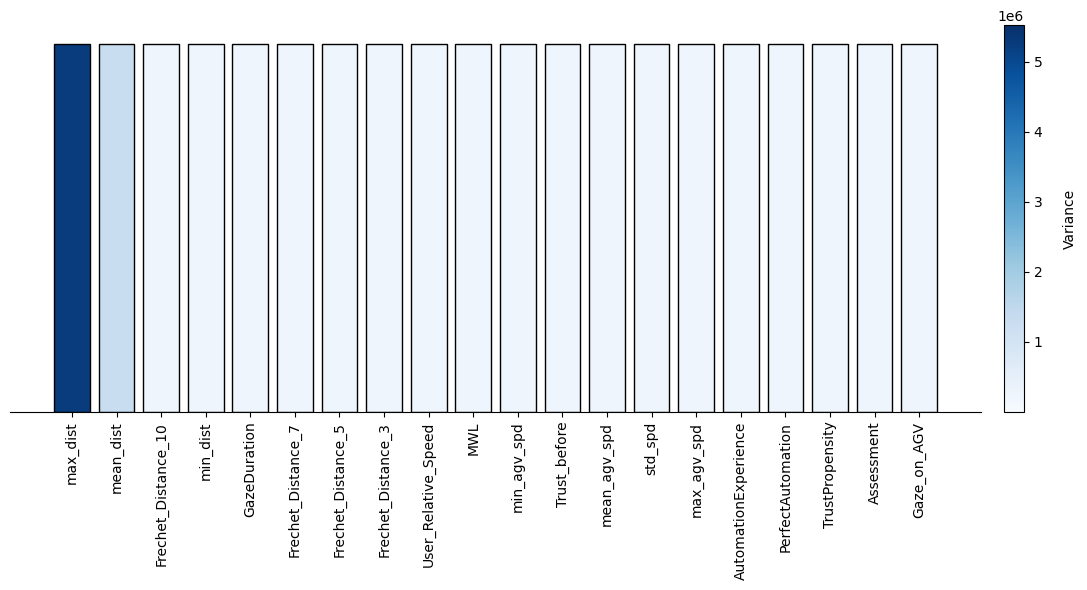

In [164]:
# Calculate the variance for the specified columns
variance_values = model_data[specific_columns].var().sort_values(ascending=False)

# Set a constant height for all bars
constant_height = 1.0  # Adjust this value as needed

# Plotting
plt.figure(figsize=(12, 6))

# Create a color gradient based on the variance values
colors = sns.color_palette("Blues", n_colors=len(variance_values))

# Create the bar plot with constant height and color mapping based on variance
bars = plt.bar(variance_values.index, [constant_height] * len(variance_values), 
               color=[colors[int((var / variance_values.max()) * (len(colors) - 1))] for var in variance_values])

# Adding edge color for better visibility
for bar in bars:
    bar.set_edgecolor('black')  # Optional: to enhance visibility

# Remove the y-axis
plt.yticks([])  # Hide y-axis ticks
plt.ylabel("")  # Hide y-axis label

# Set x-axis label visibility
plt.xlabel("")  # Optionally, remove x-axis label if needed
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability

# Add only the x-axis
plt.gca().spines['top'].set_visible(False)  # Hide top spine
plt.gca().spines['right'].set_visible(False)  # Hide right spine
plt.gca().spines['left'].set_visible(False)  # Hide left spine

# Create a colorbar
norm = plt.Normalize(vmin=variance_values.min(), vmax=variance_values.max())
sm = plt.cm.ScalarMappable(cmap='Blues', norm=norm)
sm.set_array([])  # Only needed for older Matplotlib versions

# Add the colorbar to the plot
cbar = plt.colorbar(sm, ax=plt.gca(), orientation='vertical', pad=0.02)
cbar.set_label('Variance', rotation=90, labelpad=15)

# Show the plot
plt.tight_layout()  # Adjust layout

# Define the filename with timestamp
filename = f'variance_for_the_specified_columns.png'

full_path = os.path.join(box_path + save_dir, filename)

# Save the plots in the specified directory
# plt.savefig(full_path, dpi = 300)

plt.show()

### Filter Features by Correlation

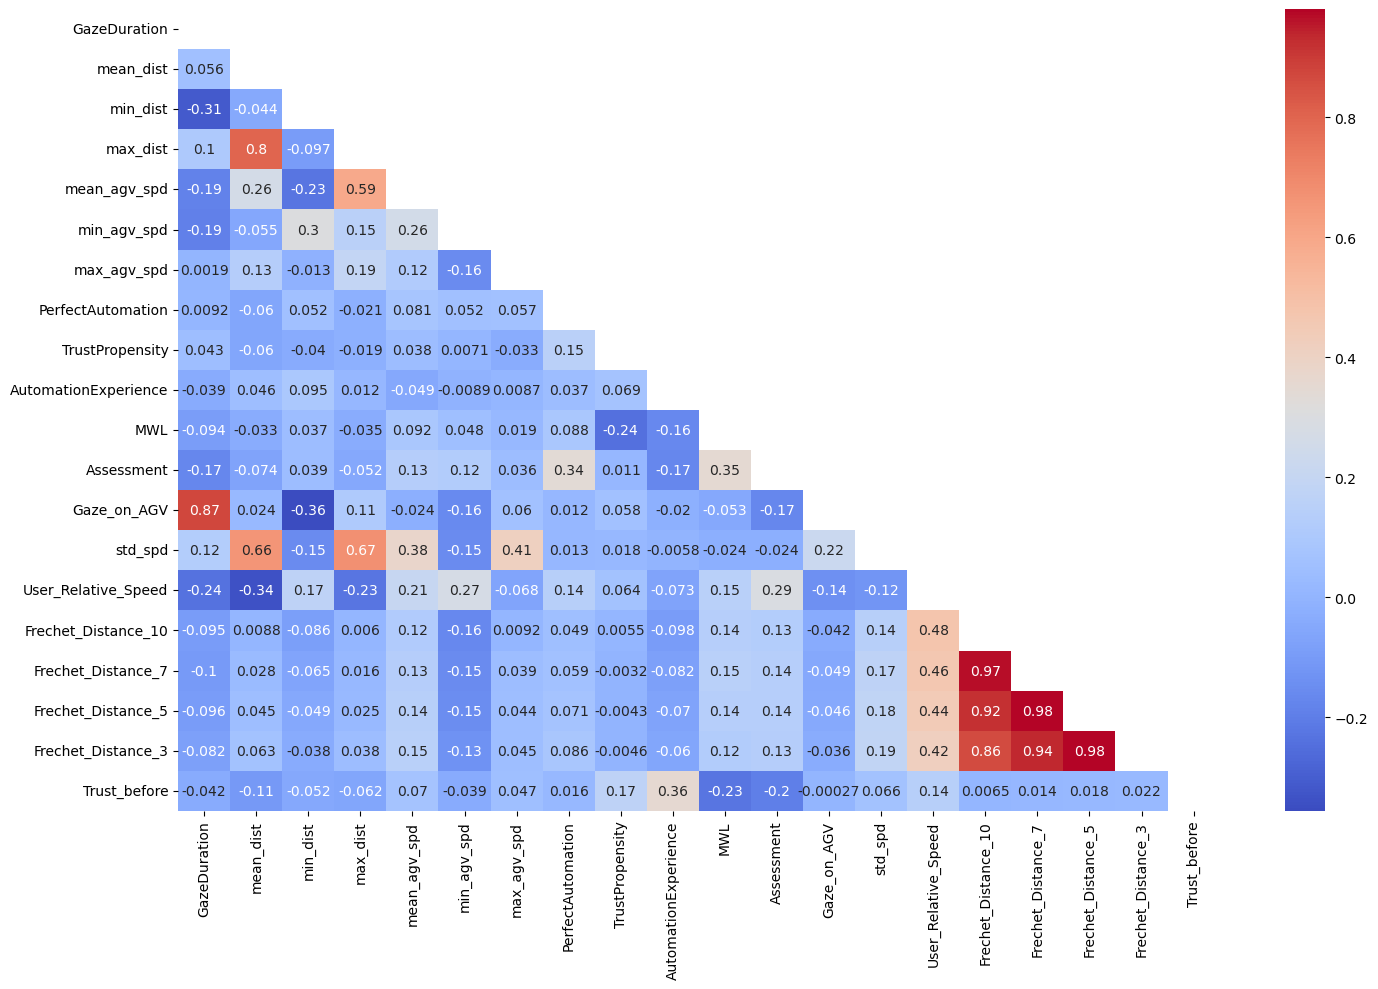

In [167]:
# Create a mask for the upper triangle
mask = np.triu(np.ones_like(model_data[specific_columns].corr(), dtype=bool))

# Set up the matplotlib figure
fig, ax = plt.subplots(figsize=(15, 10))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(model_data[specific_columns].corr(), 
            mask=mask, 
            cmap='coolwarm', 
            annot=True, # If you want the correlation numbers displayed
            ax=ax)

# Define the filename with a timestamp
filename = f'correlation_matrix_for_the_numerical_columns.png'

# Show the plot
plt.tight_layout()

# Full path where you want to save the plot
full_path = os.path.join(box_path + save_dir, filename)

# Save the plot in the specified directory (uncomment when ready to save)
# plt.savefig(full_path, dpi=600)

plt.show()

### Calculating Correlation with Target Variable: Trust

In [170]:
# Calculate the absolute correlation between specific columns and the 'Trust' column
correlations = abs(model_data[specific_columns + ['Trust']].corr()['Trust']).sort_values(ascending=False)

# Exclude the 'Trust' column from the result (if desired)
correlations = correlations.drop('Trust')

print(correlations)

Trust_before             0.724
AutomationExperience     0.378
MWL                       0.24
Assessment               0.187
TrustPropensity          0.183
User_Relative_Speed      0.171
GazeDuration             0.143
mean_dist                0.142
mean_agv_spd             0.116
Gaze_on_AGV             0.0921
max_dist                0.0807
min_agv_spd             0.0581
std_spd                 0.0397
Frechet_Distance_3      0.0175
max_agv_spd              0.016
PerfectAutomation       0.0145
min_dist                0.0121
Frechet_Distance_5     0.00774
Frechet_Distance_7     0.00341
Frechet_Distance_10    0.00193
Name: Trust, dtype: float64


### Forward Feature Selection

Skipping Frechet_Distance_7 due to high correlation with selected features.
Skipping Frechet_Distance_5 due to high correlation with selected features.
Skipping Frechet_Distance_3 due to high correlation with selected features.
Skipping Frechet_Distance_7 due to high correlation with selected features.
Skipping Frechet_Distance_5 due to high correlation with selected features.
Skipping Frechet_Distance_3 due to high correlation with selected features.
Skipping Frechet_Distance_7 due to high correlation with selected features.
Skipping Frechet_Distance_5 due to high correlation with selected features.
Skipping Frechet_Distance_3 due to high correlation with selected features.
Skipping Frechet_Distance_7 due to high correlation with selected features.
Skipping Frechet_Distance_5 due to high correlation with selected features.
Skipping Frechet_Distance_3 due to high correlation with selected features.
Skipping mean_dist due to high correlation with selected features.
Skipping max_dist due

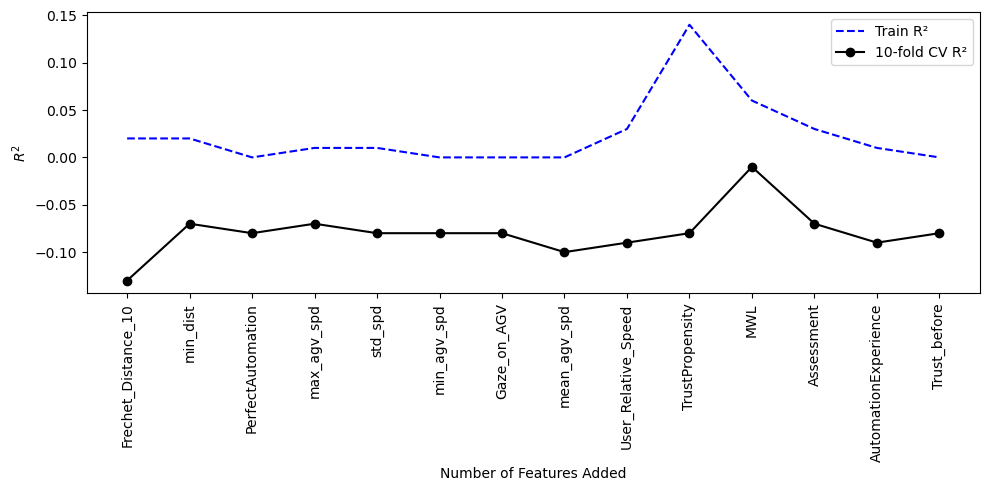

In [175]:
frechet_columns = ['Frechet_Distance_3', 'Frechet_Distance_5', 'Frechet_Distance_7', 'Frechet_Distance_8']

# Assuming model_data is already loaded and target_column is your target variable
X = model_data[specific_columns]
y = model_data['Trust']

# Initialize variables
selected_features = []
best_score = np.inf

# To track R^2 or another performance metric for train and cross-validation
train_scores = []
cv_scores = []

# Calculate the correlation matrix for the selected columns
correlation_matrix = X.corr()

# Forward selection loop
while len(selected_features) < len(specific_columns):
    # Limit remaining features to those in specific_columns
    remaining_features = [f for f in specific_columns if f not in selected_features]

    # Skip Frechet columns once one has been selected
    #if frechet_selected:
    #    remaining_features = [f for f in remaining_features if f not in frechet_columns]

    if not remaining_features:
        print("No more features left to evaluate.")
        break

    candidate_scores = {}
    
    for feature in remaining_features:
        # Check correlation with already selected features
        if any(abs(correlation_matrix[feature][selected]) > 0.5 for selected in selected_features):
            print(f"Skipping {feature} due to high correlation with selected features.")
            continue

        try:
            model = LinearRegression()
            model.fit(X[selected_features + [feature]], y)
            
            # Train score (R^2)
            train_score = model.score(X[selected_features + [feature]], y)
            train_scores.append(round(train_score, 2))  # Store train score (rounded to 2 decimal places)
            
            # Cross-validation score (average of 10-fold CV)
            cv_score = cross_val_score(model, X[selected_features + [feature]], y, cv=10, scoring='r2')
            cv_scores.append(round(np.mean(cv_score), 2))  # Store CV score (rounded to 2 decimal places)
            
            # Store score for the current feature
            candidate_scores[feature] = train_score  # Could also use CV score depending on preference
            
        except Exception as e:
            print(f"Error processing feature {feature}: {e}")
    
    # Check if there are any valid candidate scores
    if not candidate_scores:
        print("No valid candidate scores generated.")
        break

    # Select the best feature based on the scores
    best_feature = min(candidate_scores, key=candidate_scores.get)
    selected_features.append(best_feature)

    # Mark Frechet column as selected if it was picked
    if best_feature in frechet_columns:
        frechet_selected = True

# Test process
# Split the data into train and test sets (e.g., 80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X[selected_features], y, test_size=0.2, random_state=42)

# Fit the model using all selected features
final_model = LinearRegression()
final_model.fit(X_train, y_train)

# Evaluate the model on the test set
test_score = final_model.score(X_test, y_test)
print(f"Test R² score: {round(test_score, 2)}")

# Visualization of the feature selection process
plt.figure(figsize=(10, 5))

# Only plot the train_scores and cv_scores that correspond to the selected features
num_selected_features = len(selected_features)
plt.plot(range(num_selected_features), train_scores[:num_selected_features], label='Train R²', linestyle='--', color='blue')
plt.plot(range(num_selected_features), cv_scores[:num_selected_features], label='10-fold CV R²', color='black', marker='o')

# Use the number of selected features for x-axis ticks
plt.xticks(range(num_selected_features), selected_features, rotation=90)

# Annotate plot
plt.xlabel('Number of Features Added')
plt.ylabel(r'$R^2$')  # Regular R-squared
plt.legend()
plt.tight_layout()
plt.show()

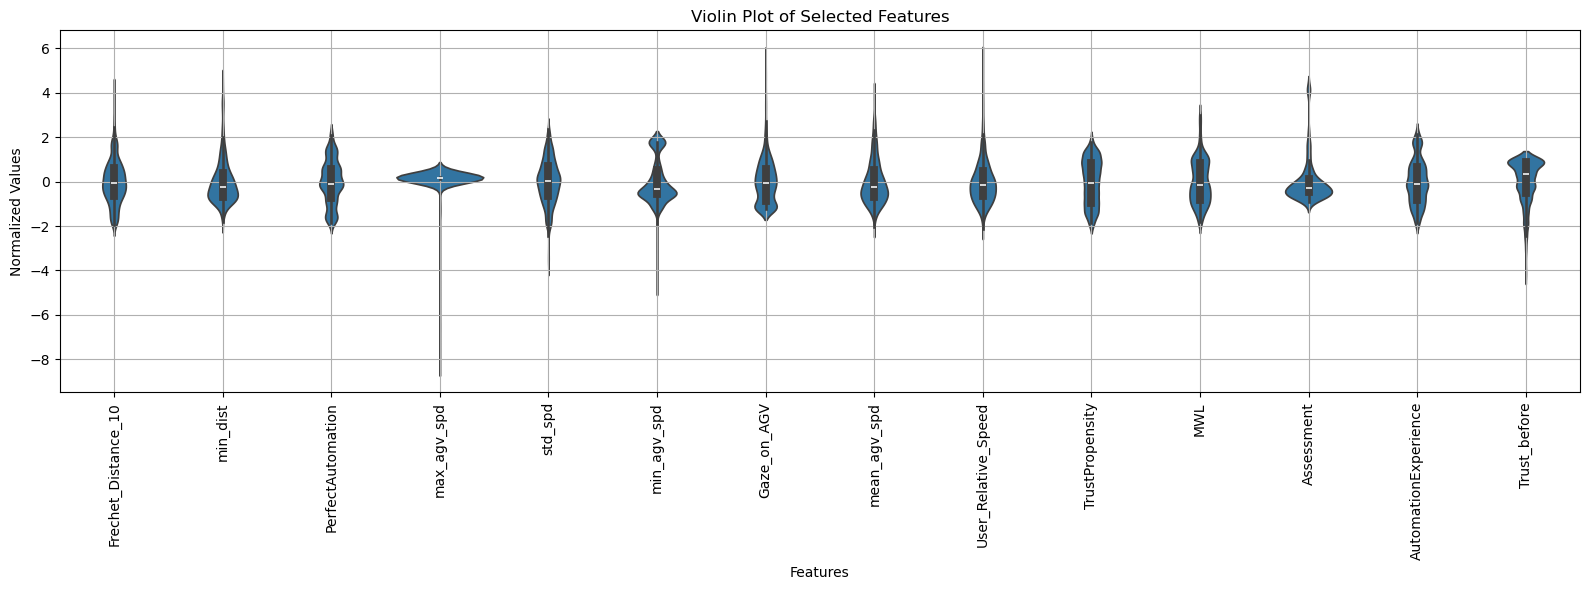

In [177]:
# Assuming model_data is already loaded and target_column is your target variable
X = model_data[selected_features]

# Normalize the selected features
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

# Create a DataFrame for the normalized features
normalized_df = pd.DataFrame(X_normalized, columns=selected_features)

# Melt the DataFrame to long format for Seaborn
normalized_long = normalized_df.melt(var_name='Feature', value_name='Normalized Value')

# Plotting all features in a single violin plot
plt.figure(figsize=(16, 6))
sns.violinplot(data=normalized_long, x='Feature', y='Normalized Value')
plt.xlabel('Features')
plt.ylabel('Normalized Values')
plt.title('Violin Plot of Selected Features')
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()

# Define the filename with a timestamp
filename = f'violin_plot_of_selected_features.png'

# Full path where you want to save the plot
full_path = os.path.join(box_path + save_dir, filename)

# Save the plot in the specified directory (uncomment when ready to save)
# plt.savefig(full_path, dpi=600)

plt.show()

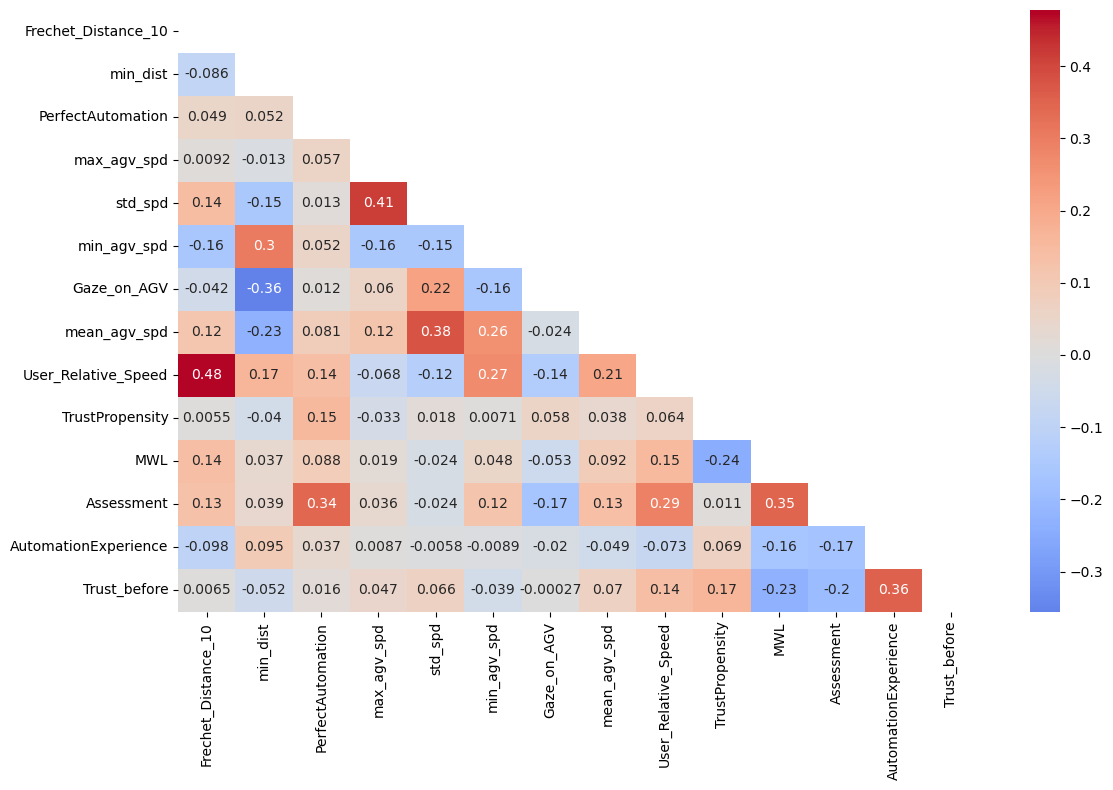

In [179]:
# Create a mask for the upper triangle
mask = np.triu(np.ones_like(model_data[selected_features].corr(), dtype=bool))

# Set up the matplotlib figure
fig, ax = plt.subplots(figsize=(12, 8))

# Draw the heatmap with the mask, correct aspect ratio, and centered color scale
sns.heatmap(model_data[selected_features].corr(), 
            mask=mask, 
            cmap='coolwarm', 
            annot=True,  # If you want the correlation numbers displayed
            center=0,    # Center the color scale around zero
            ax=ax)

# Define the filename with a timestamp
filename = f'correlation_matrix_for_the_specified_columns.png'

# Show the plot
plt.tight_layout()

# Full path where you want to save the plot
full_path = os.path.join(box_path + save_dir, filename)

# Save the plot in the specified directory (uncomment when ready to save)
# plt.savefig(full_path, dpi=600)

plt.show()

### Building Regression Models

In [182]:
# List of categorical columns to apply one-hot encoding (dummies)
categorical_columns = ['Gender', 'Ethnicity', 'GamingFrequency', 'VRExperience', 
                       'VRHeadsetExperience', 'AGVInteraction', 'AGVname', 
                       'AGV_Approaching', 'User_Trajectory', 'DRate', 'task', 
                       'AGV_User_Combination', 'AGV_Path_Complexity', 'Interaction No']

# Apply get_dummies to categorical columns and include selected_features, Trust, and PID
model_data_with_dummies = pd.get_dummies(
    model_data[categorical_columns + selected_features + ['Trust', 'PID']],  # Include Trust and PID
    columns=categorical_columns,  # Apply dummies only to the categorical columns
    drop_first=True  # Drop the first level for binary categorical variables
)

# Preview the resulting DataFrame
model_data_with_dummies.head()

,Frechet_Distance_10,min_dist,PerfectAutomation,max_agv_spd,std_spd,min_agv_spd,Gaze_on_AGV,mean_agv_spd,User_Relative_Speed,TrustPropensity,...,Interaction No_7,Interaction No_8,Interaction No_9,Interaction No_10,Interaction No_11,Interaction No_12,Interaction No_13,Interaction No_14,Interaction No_15,Interaction No_16
0,1.77e+03,729,3.57,15.2,6.15,-0.03,0.063,8.2,74.6,3.67,...,False,False,False,False,False,False,False,False,False,False
1,247,993,3.57,15.2,3.19,-4.39,0.038,5.21,47.9,3.67,...,False,False,False,False,False,False,False,False,False,False
2,1.07e+03,251,3.57,15.2,5.28,-5.6,0.069,3.24,63.1,3.67,...,False,False,False,False,False,False,False,False,False,False
3,611,546,3.57,15.2,6.62,-3.5,0.231,7.2,43.6,3.67,...,False,False,False,False,False,False,False,False,False,False
4,1.72e+03,1.66e+03,3.57,15.3,4.72,-3.35,0.234,3.31,93.7,3.67,...,False,False,False,False,False,False,False,False,False,False


In [184]:
'''
# Get unique PIDs from the dataset
unique_pids = model_data['PID'].unique()

# Randomly select a subset of PIDs for the test set (e.g., 20% of the unique PIDs)
test_pids = np.random.choice(unique_pids, size=int(0.2 * len(unique_pids)), replace=False)

# Print the randomly selected test PIDs for reference
print(f"Test PIDs: {test_pids}")

# Ensure 'PID' and target_column are present in the dataset
# Filter the data for training and testing
train_data = model_data_with_dummies[~model_data_with_dummies['PID'].isin(test_pids)]  # Training set
test_data = model_data_with_dummies[model_data_with_dummies['PID'].isin(test_pids)]    # Test set

# Define the features (X) and target (y)
X_train = train_data.drop(columns=['Trust', 'PID'])  # Drop the target and PID for training
y_train = train_data['Trust']

X_test = test_data.drop(columns=['Trust', 'PID'])    # Drop the target and PID for testing
y_test = test_data['Trust']

# Check the shapes of the split data to verify
print(f"Training set size: {X_train.shape}, Test set size: {X_test.shape}")
'''

'\n# Get unique PIDs from the dataset\nunique_pids = model_data[\'PID\'].unique()\n\n# Randomly select a subset of PIDs for the test set (e.g., 20% of the unique PIDs)\ntest_pids = np.random.choice(unique_pids, size=int(0.2 * len(unique_pids)), replace=False)\n\n# Print the randomly selected test PIDs for reference\nprint(f"Test PIDs: {test_pids}")\n\n# Ensure \'PID\' and target_column are present in the dataset\n# Filter the data for training and testing\ntrain_data = model_data_with_dummies[~model_data_with_dummies[\'PID\'].isin(test_pids)]  # Training set\ntest_data = model_data_with_dummies[model_data_with_dummies[\'PID\'].isin(test_pids)]    # Test set\n\n# Define the features (X) and target (y)\nX_train = train_data.drop(columns=[\'Trust\', \'PID\'])  # Drop the target and PID for training\ny_train = train_data[\'Trust\']\n\nX_test = test_data.drop(columns=[\'Trust\', \'PID\'])    # Drop the target and PID for testing\ny_test = test_data[\'Trust\']\n\n# Check the shapes of the sp

In [186]:
# Specify the seed for reproducibility
random_seed = 42

# Perform the train-test split (80% train, 20% test)
train_data, test_data = train_test_split(model_data_with_dummies, test_size=0.2, random_state=random_seed)

# Separate features (X) and target (y) for both train and test sets
X_train = train_data.drop(columns=['Trust', 'PID'])  # Drop the target and PID for training
y_train = train_data['Trust']

X_test = test_data.drop(columns=['Trust', 'PID'])    # Drop the target and PID for testing
y_test = test_data['Trust']

# Check the shapes of the split data to verify
print(f"Training set size: {X_train.shape}, Test set size: {X_test.shape}")

Training set size: (1024, 95), Test set size: (256, 95)


In [188]:
# Initialize the scaler
scaler = StandardScaler()

# Scale the features
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# Scale the target variable
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1, 1)).flatten()

In [190]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer
import numpy as np
from tabulate import tabulate

# Define list of models and their parameter grids for tuning
param_grids = {
    'LinearRegression': {},  # No hyperparameters for linear regression
    'KNN Regressor': {'n_neighbors': [1, 5, 10, 15, 20]},
    'RegressionTree': {'max_depth': [1, 5, 10, 15, 20]},
    'Bagging Regressor': {'n_estimators': [25, 50, 75, 100, 125, 150, 175, 200]},
    'RandomForest Regressor': {'n_estimators': [25, 50, 75, 100, 125, 150, 175, 200], 'max_depth': [1, 5, 10, 15, 20]},
    'GradientBoosting Regressor': {'n_estimators': [25, 50, 75, 100, 125, 150, 175, 200], 'max_depth': [1, 5, 10, 15, 20], 'learning_rate': [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]},
    'XGBoost Regressor': {'n_estimators': [25, 50, 75, 100, 125, 150, 175, 200], 'max_depth': [1, 5, 10, 15, 20], 'learning_rate': [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]},
}

# Define the models to be fine-tuned
Regressor_models = [
    ('LinearRegression', LinearRegression()), 
    ('KNN Regressor', KNeighborsRegressor()),
    ('RegressionTree', DecisionTreeRegressor(random_state=42)),
    ('Bagging Regressor', BaggingRegressor(random_state=42)), 
    ('RandomForest Regressor', RandomForestRegressor(random_state=42)),
    ('GradientBoosting Regressor', GradientBoostingRegressor(random_state=42)),
    ('XGBoost Regressor', XGBRegressor(random_state=42)),
]

# Define lists to store results
Regressor_results = []
Regressor_names = []

# Define the header for results
header = ["Model", "MAPE", "MSE", "RMSE", "Relative RMSE", "MAE", "R-squared", "Best Params"]

# Train, tune, and evaluate each regression model with GridSearchCV
for name, model in Regressor_models:
    # print(f"Tuning hyperparameters for {name}...")
    
    # If there are hyperparameters to tune, use GridSearchCV
    if name in param_grids and param_grids[name]:
        grid_search = GridSearchCV(estimator=model, param_grid=param_grids[name], cv=5, 
                                   scoring='r2', n_jobs=-1, verbose=1)
        grid_search.fit(X_train_scaled, y_train_scaled)  # Use scaled target variable
        best_model = grid_search.best_estimator_
        best_params = grid_search.best_params_
    else:
        # If no hyperparameters, just fit the model
        best_model = model
        best_model.fit(X_train_scaled, y_train_scaled)
        best_params = "N/A"

    # Make predictions
    pred = best_model.predict(X_test_scaled)
    
    # Inverse transform the predictions to get them back to the original scale
    pred_original_scale = y_scaler.inverse_transform(pred.reshape(-1, 1)).flatten()
    
    # Calculate Mean Absolute Percent Error (MAPE)
    current_mape = np.mean(np.abs((y_test - pred_original_scale) / y_test)) * 100
    
    # Calculate Mean Squared Error (MSE)
    current_mse = mse(y_test, pred_original_scale)
    
    # Calculate Root Mean Squared Error (RMSE)
    current_rmse = np.sqrt(current_mse)
    
    # Calculate Relative Root Mean Squared Error (RRMSE)
    rrmse_denominator = np.mean(y_test)
    current_rrmse = current_rmse / rrmse_denominator
    
    # Calculate Mean Absolute Error (MAE)
    current_mae = mae(y_test, pred_original_scale)
    
    # Calculate R-squared
    current_r2 = r2_score(y_test, pred_original_scale)
    
    # Append results to lists
    Regressor_results.append({
        'Model': name,
        'MAPE': current_mape,
        'MSE': current_mse,
        'RMSE': current_rmse,
        'RRMSE': current_rrmse,
        'MAE': current_mae,
        'R-squared': current_r2,
        'Best Params': best_params  # Add best hyperparameters
    })
    Regressor_names.append(name)
    
    # Print the results
    print(tabulate([[name, f'{current_mape:.2f}', f'{current_mse:.2f}', 
                     f'{current_rmse:.2f}', f'{current_rrmse:.2f}', 
                     f'{current_mae:.2f}', f'{current_r2:.2f}', best_params]], 
                    header, tablefmt="fancy_grid"))

╒══════════════════╤════════╤═══════╤════════╤═════════════════╤═══════╤═════════════╤═══════════════╕
│ Model            │   MAPE │   MSE │   RMSE │   Relative RMSE │   MAE │   R-squared │ Best Params   │
╞══════════════════╪════════╪═══════╪════════╪═════════════════╪═══════╪═════════════╪═══════════════╡
│ LinearRegression │  13.08 │   1.1 │   1.05 │            0.12 │  0.75 │        0.64 │ N/A           │
╘══════════════════╧════════╧═══════╧════════╧═════════════════╧═══════╧═════════════╧═══════════════╛
Fitting 5 folds for each of 5 candidates, totalling 25 fits
╒═══════════════╤════════╤═══════╤════════╤═════════════════╤═══════╤═════════════╤═════════════════════╕
│ Model         │   MAPE │   MSE │   RMSE │   Relative RMSE │   MAE │   R-squared │ Best Params         │
╞═══════════════╪════════╪═══════╪════════╪═════════════════╪═══════╪═════════════╪═════════════════════╡
│ KNN Regressor │  21.74 │  2.47 │   1.57 │            0.18 │   1.2 │        0.19 │ {'n_neighbors': 20} │
╘

                 Feature  Importance
0    Frechet_Distance_10     0.00548
1               min_dist     0.00546
2      PerfectAutomation     0.00913
3            max_agv_spd      0.0109
4                std_spd     0.00585
5            min_agv_spd      0.0123
6            Gaze_on_AGV      0.0104
7           mean_agv_spd     0.00776
8    User_Relative_Speed     0.00833
9        TrustPropensity     0.00664
10                   MWL       0.012
11            Assessment      0.0123
12  AutomationExperience      0.0354
13          Trust_before       0.304


ValueError: Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.

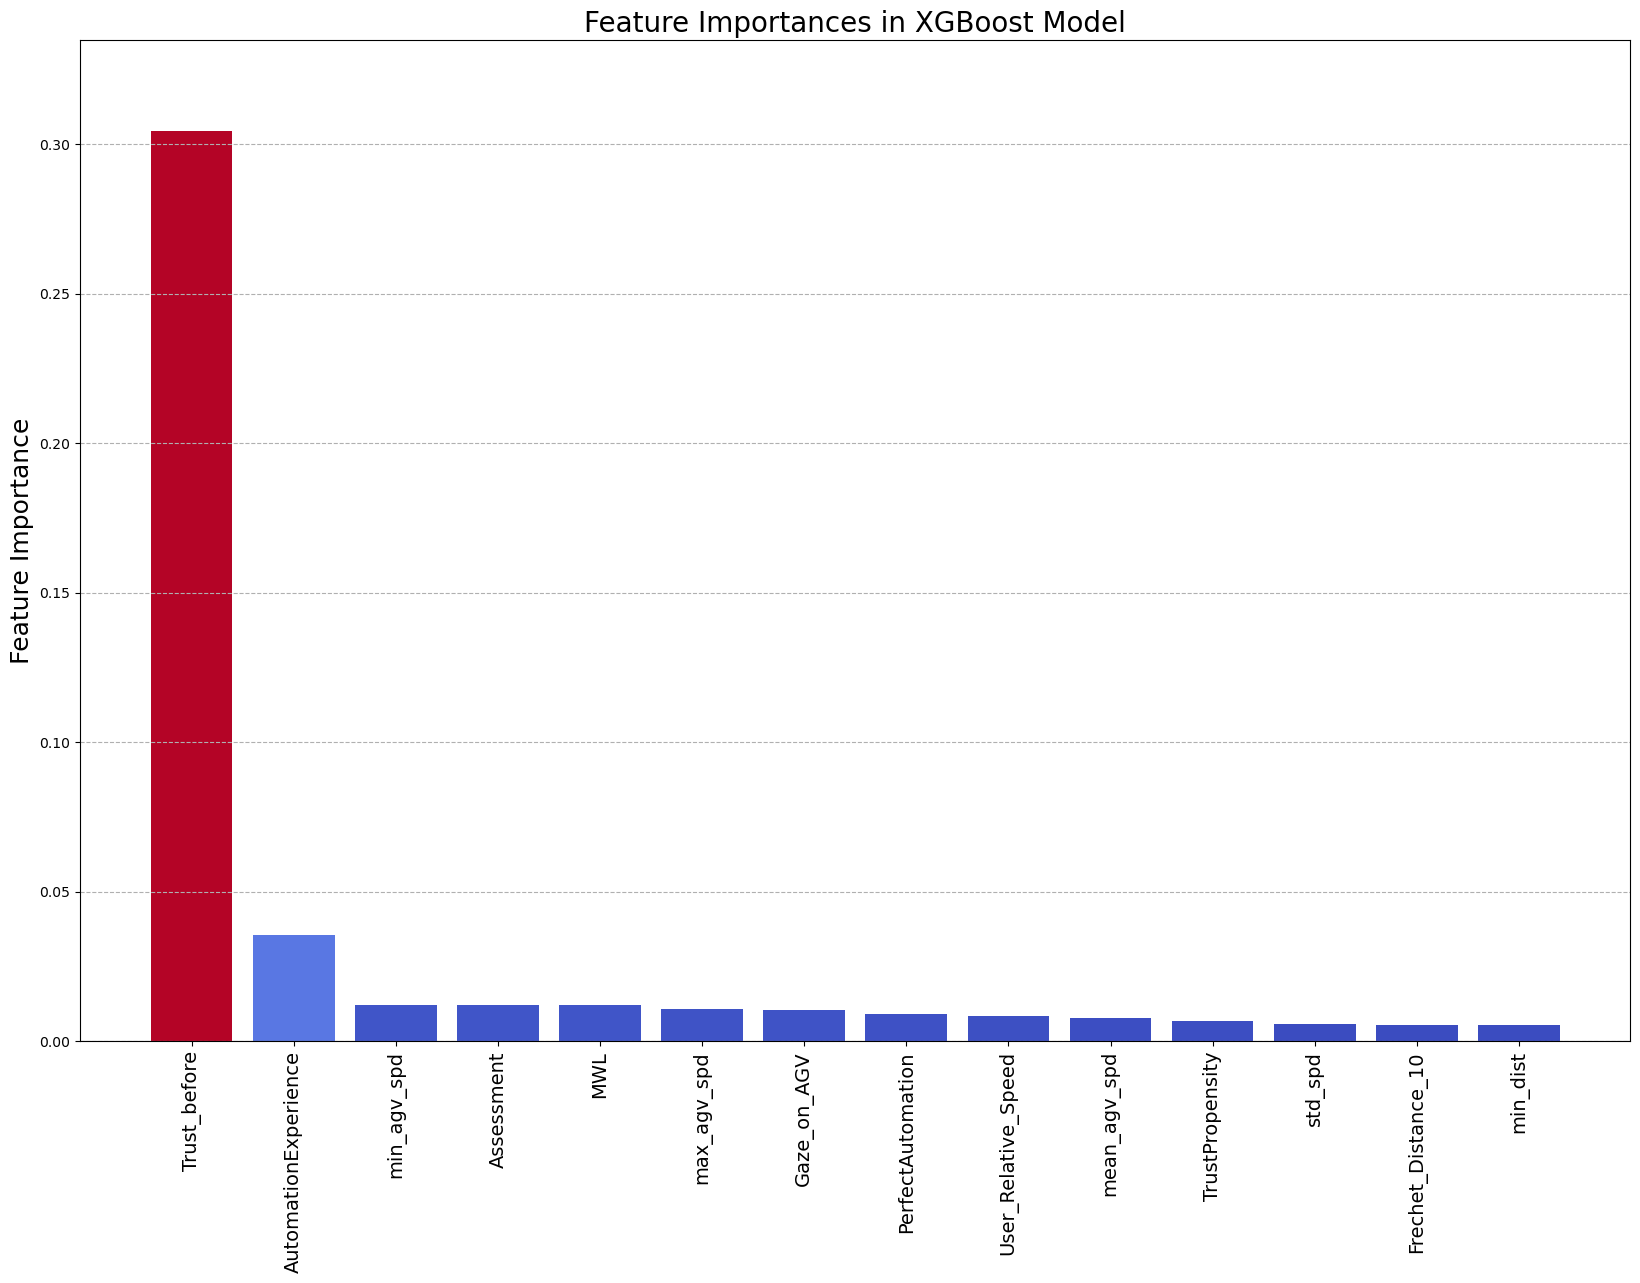

In [192]:
# Fit the best XGBoost model on the training data
best_model = next(model for name, model in Regressor_models if name == 'XGBoost Regressor')
best_model.fit(X_train_scaled, y_train_scaled)  # Fit the model

# Extract feature importances and feature names
importances = best_model.feature_importances_
feature_names = X_train_scaled.columns  # Use feature names from the training data

# Create a DataFrame for the feature importances
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Filter the DataFrame for only the selected features
selected_importance_df = importance_df[importance_df['Feature'].isin(selected_features)]

# Display the selected features and their importances
print(selected_importance_df)

# Sort the DataFrame by the absolute value of importances in descending order
selected_importance_df = selected_importance_df.sort_values(by='Importance', ascending=False)

# Create a colormap
norm = plt.Normalize(selected_importance_df['Importance'].min(), selected_importance_df['Importance'].max())
colors = plt.cm.coolwarm(norm(selected_importance_df['Importance']))

# Plotting with flipped axes and colormap
plt.figure(figsize=(20, 13))
bars = plt.bar(selected_importance_df['Feature'], selected_importance_df['Importance'], color=colors)
plt.ylabel('Feature Importance', fontsize=18)  # Set y-axis label font size
plt.title('Feature Importances in XGBoost Model', fontsize=20)  # Set title font size
plt.axhline(0, color='grey', linewidth=0.8)  # Add a line at y=0 for reference
plt.grid(axis='y', linestyle='--')
plt.xticks(rotation=90, fontsize=14)  # Set x-axis label font size
plt.ylim(0, selected_importance_df['Importance'].max() * 1.1)  # Adjust y-axis limit for better visualization

# Create a color bar based on the bars
sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=norm)
sm.set_array([])  # Create a dummy array for colorbar
plt.colorbar(sm, label='Feature Importance')

# Define the filename with a timestamp
filename = f'feature_importances_in_xgboost.png'

# Show the plot
plt.tight_layout()

# Full path where you want to save the plot
full_path = os.path.join(box_path + save_dir, filename)

# Save the plot in the specified directory (uncomment when ready to save)
# plt.savefig(full_path, dpi=600)

plt.show()

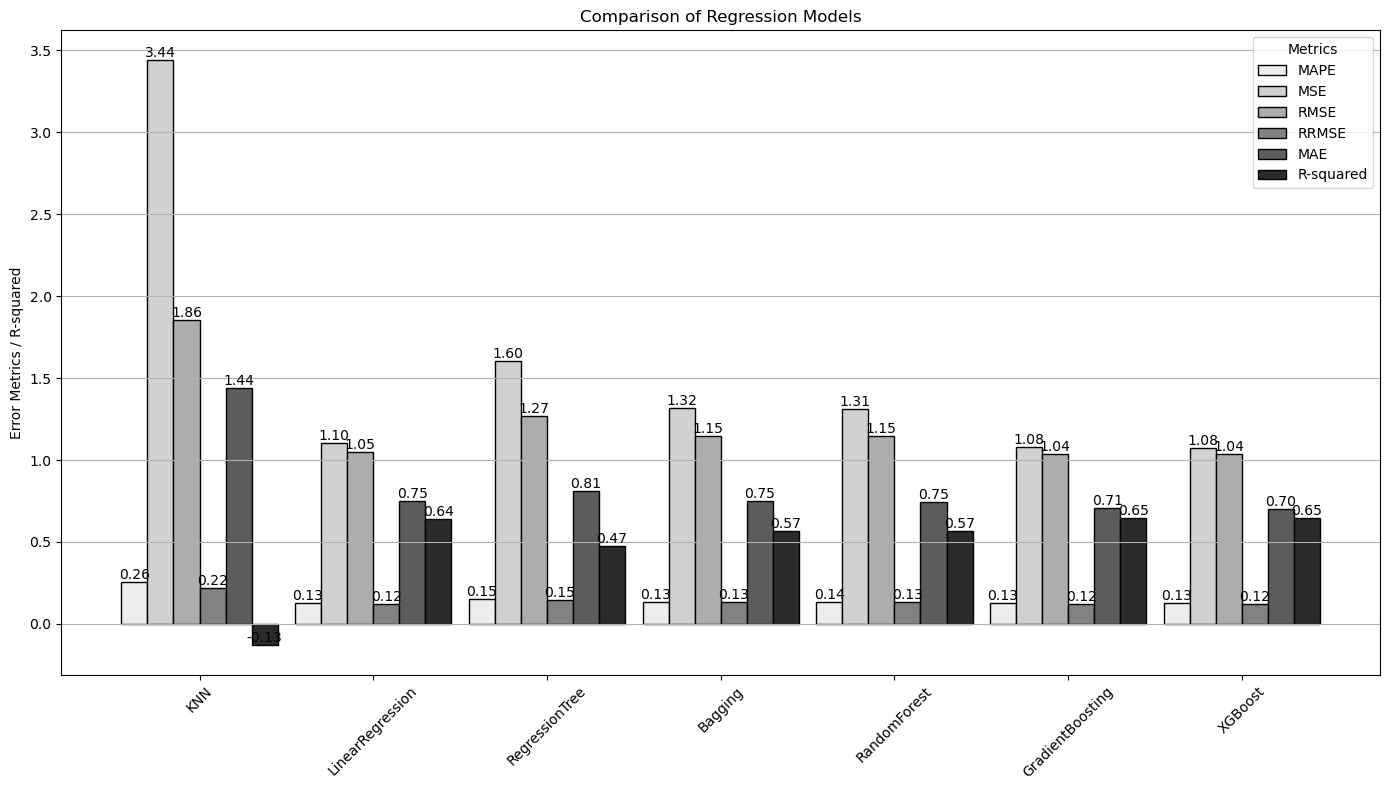

In [196]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error as mae, mean_squared_error as mse, r2_score

# Sample X_train, y_train, X_test, y_test for demonstration (replace these with your actual data)
# X_train, y_train = ...
# X_test, y_test = ...

# Your previously defined regression models and results calculation
random = 2023
Regressor_models = [
    ('KNN', KNeighborsRegressor(n_neighbors=15)),
    ('LinearRegression', LinearRegression()), 
    ('RegressionTree', DecisionTreeRegressor(max_depth=4, random_state=random)),
    ('Bagging', BaggingRegressor(n_estimators=100, random_state=random)), 
    ('RandomForest', RandomForestRegressor(n_estimators=100, max_depth=6, random_state=random)),
    ('GradientBoosting', GradientBoostingRegressor(n_estimators=100, max_depth=2, 
                                                   learning_rate=0.1, random_state=random)),
    ('XGBoost', XGBRegressor(n_estimators=100, max_depth=2, learning_rate=0.1, random_state=random)),
]

# Define lists to store results
Regressor_results = []

# Train and evaluate each regression model
for name, model in Regressor_models:
    # Train the regression model
    fitted = model.fit(X_train, y_train)
    
    # Make predictions
    pred = fitted.predict(X_test)
    
    # Calculate performance metrics
    current_mape = mape(y_test, pred)
    current_mse = mse(y_test, pred)
    current_rmse = np.sqrt(current_mse)
    rrmse_denominator = np.mean(y_test)
    current_rrmse = current_rmse / rrmse_denominator
    current_mae = mae(y_test, pred)
    current_r2 = r2_score(y_test, pred)
    
    # Append results to lists
    Regressor_results.append({
        'Model': name,
        'MAPE': current_mape,
        'MSE': current_mse,
        'RMSE': current_rmse,
        'RRMSE': current_rrmse,
        'MAE': current_mae,
        'R-squared': current_r2  # Store R-squared in results
    })

# Convert results to a DataFrame for easier plotting
results_df = pd.DataFrame(Regressor_results)

# Set the figure size
plt.figure(figsize=(14, 8))

# Define the number of metrics to plot
metrics = ['MAPE', 'MSE', 'RMSE', 'RRMSE', 'MAE', 'R-squared']

# Create a grouped bar plot with adjusted parameters
bar_width = 0.15  # Wider bars
x = np.arange(len(results_df['Model']))  # the label locations

# Define a color palette for blue shades
colors = sns.color_palette("Greys", len(metrics))

# Plot each metric separately for better control over spacing
for i, metric in enumerate(metrics):
    plt.bar(x + (i * bar_width), results_df[metric], width=bar_width, 
            label=metric, color=colors[i], edgecolor='black')

# Add labels and title
plt.ylabel('Error Metrics / R-squared')
plt.title('Comparison of Regression Models')
plt.xticks(x + (len(metrics) - 1) * bar_width / 2, results_df['Model'], rotation=45)
plt.legend(title='Metrics')

# Annotate bars with numerical values
for i in range(len(results_df)):
    for j in range(len(metrics)):
        plt.text(x[i] + j * bar_width, results_df[metrics[j]][i], 
                 f'{results_df[metrics[j]][i]:.2f}', 
                 ha='center', va='bottom', fontsize=10)

# Add grids
plt.grid(axis='y')

# Adjust the layout for better spacing
plt.tight_layout()

# Define the filename with timestamp
filename = 'Regression Results'

full_path = os.path.join(box_path + save_dir, filename)

# Save the plots in the specified directory
# plt.savefig(full_path, dpi = 300)

# Show plot
plt.show()